# 가입자 유입 분석

BigQuery `raw` 데이터셋의 합성 가입자(`_source = 'local'`)를 대상으로, 탈퇴 기록이 없는 사용자만 추려 가입 추이를 살펴본다. 

월별 신규 가입자 수, 학교 유형(중·고)·학년별 가입자 분포, 지역(시도)별 가입자 수와 학교당 밀도, 성별 가입자 비중을 차례로 쿼리하고 차트로 확인한다.

In [1]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

## 월별 신규 가입자 수

`app_user` 에서 `_source = 'local'`·`_deleted_at IS NULL` 인 사용자 중 탈퇴 기록이 없는 사람만 남긴 뒤, 월별 신규 가입자 수를 센다.

전월 대비 증감과 전체 대비 월별 비중을 함께 계산하고, 아래 선 그래프로 월별 추이를 그린다.

In [5]:
monthly_non_withdrawn_signup_sql = """
WITH acquisition_users AS (
  -- 합성 가입자 중 탈퇴 기록이 없는 사용자
  SELECT
    u.id AS user_id,
    u.created_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

monthly_signup AS (
  SELECT
    DATE_TRUNC(
      DATE(created_at, 'Asia/Seoul'),
      MONTH
    ) AS signup_month,

    COUNT(DISTINCT user_id) AS new_user_count

  FROM acquisition_users
  GROUP BY signup_month
),

monthly_with_previous AS (
  SELECT
    signup_month,
    new_user_count,

    LAG(new_user_count) OVER (
      ORDER BY signup_month
    ) AS previous_month_count

  FROM monthly_signup
)

SELECT
  signup_month,
  new_user_count,
  previous_month_count,

  new_user_count
    - previous_month_count AS increase_count,

  ROUND(
    SAFE_DIVIDE(
      new_user_count - previous_month_count,
      previous_month_count
    ) * 100,
    2
  ) AS growth_rate_percent,

  -- 전체 비탈퇴 가입자 중 해당 월의 비율
  ROUND(
    SAFE_DIVIDE(
      new_user_count,
      SUM(new_user_count) OVER ()
    ) * 100,
    2
  ) AS monthly_share_percent

FROM monthly_with_previous
ORDER BY signup_month
"""

In [6]:
cost(monthly_non_withdrawn_signup_sql)

예상 스캔량: 0.468 MiB
예상 스캔량: 0.000457 GiB
월 1 TiB 무료 용량의 약 0.00004462%


0.0004568910226225853

In [7]:
# 월별 신규 가입자 수
df_monthly_non_withdrawn = bq.query(
    monthly_non_withdrawn_signup_sql
).to_dataframe()

df_monthly_non_withdrawn

,signup_month,new_user_count,previous_month_count,increase_count,growth_rate_percent,monthly_share_percent
0,2025-09-01,6302,<NA>,<NA>,NaN,35.01
1,2025-10-01,867,6302,-5435,-86.24,4.82
2,2025-11-01,848,867,-19,-2.19,4.71
3,2025-12-01,877,848,29,3.42,4.87
4,2026-01-01,469,877,-408,-46.52,2.61
5,2026-02-01,461,469,-8,-1.71,2.56
6,2026-03-01,3578,461,3117,676.14,19.88
7,2026-04-01,1323,3578,-2255,-63.02,7.35
8,2026-05-01,1420,1323,97,7.33,7.89
9,2026-06-01,1066,1420,-354,-24.93,5.92


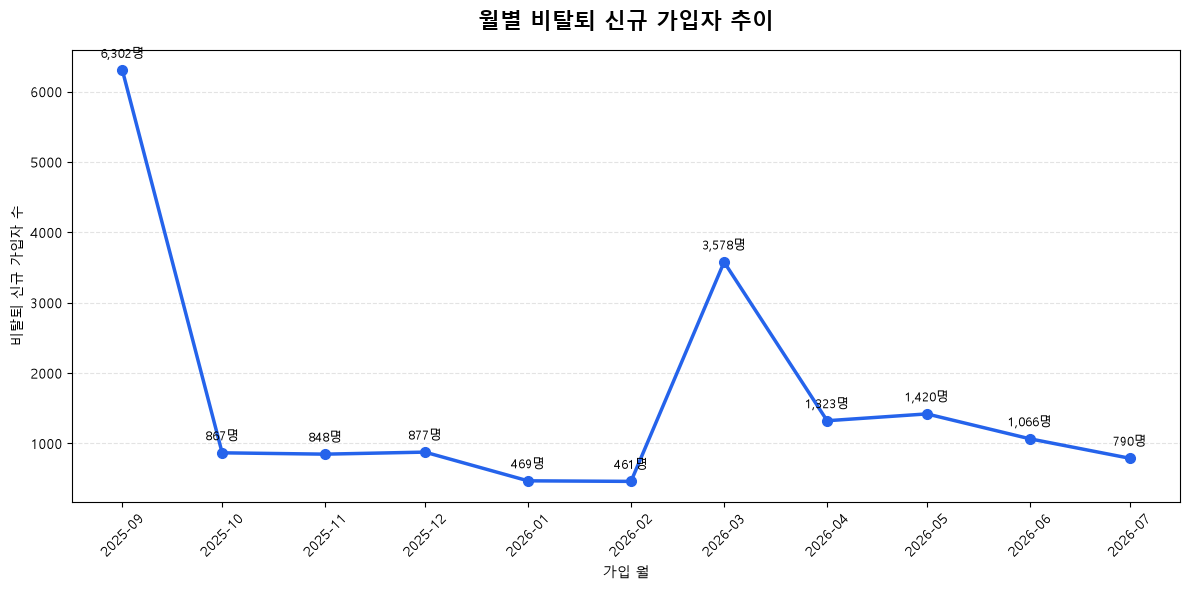

In [8]:
import platform
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

chart_df = df_monthly_non_withdrawn.copy()

chart_df["signup_month"] = pd.to_datetime(
    chart_df["signup_month"]
)

chart_df = chart_df.sort_values("signup_month")

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    chart_df["signup_month"],
    chart_df["new_user_count"],
    color="#2563EB",
    marker="o",
    markersize=7,
    linewidth=2.5
)

# 월별 가입자 수 표시
for x, y in zip(
    chart_df["signup_month"],
    chart_df["new_user_count"]
):
    ax.annotate(
        f"{y:,}명",
        xy=(x, y),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=1)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

ax.set_title(
    "월별 비탈퇴 신규 가입자 추이",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("가입 월")
ax.set_ylabel("비탈퇴 신규 가입자 수")
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 학교 유형·학년별 가입자

가입자를 `grade_class`·`school` 과 조인해 학교/학년별 가입자 수를 센다. 

학교 유형 안에서 학년이 차지하는 비율과 전체 가입자 중 비율을 같이 구하고, 학년을 막대 그래프로 보여준다.

In [9]:
grade_non_withdrawn_signup_sql = """
WITH acquisition_users AS (
  -- 합성 가입자 중 탈퇴 기록이 없는 사용자
  SELECT
    u.id AS user_id,
    u.class_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

grade_signup AS (
  SELECT
    s.school_type,
    gc.grade,
    COUNT(DISTINCT u.user_id) AS user_count

  FROM acquisition_users AS u

  JOIN `ping-v2-503916.raw.grade_class` AS gc
    ON gc._source = 'local'
   AND u.class_id = gc.id
   AND gc._deleted_at IS NULL

  JOIN `ping-v2-503916.raw.school` AS s
    ON s._source = gc._source
   AND gc.school_id = s.id
   AND s._deleted_at IS NULL

  GROUP BY
    s.school_type,
    gc.grade
)

SELECT
  school_type,
  grade,
  user_count,

  -- 같은 학교 유형 안에서 해당 학년이 차지하는 비율
  ROUND(
    SAFE_DIVIDE(
      user_count,
      SUM(user_count) OVER (
        PARTITION BY school_type
      )
    ) * 100,
    2
  ) AS school_type_share_percent,

  -- 전체 18,001명 중 해당 학교 유형·학년의 비율
  ROUND(
    SAFE_DIVIDE(
      user_count,
      SUM(user_count) OVER ()
    ) * 100,
    2
  ) AS total_share_percent

FROM grade_signup
ORDER BY
  school_type,
  grade
"""

In [10]:
cost(grade_non_withdrawn_signup_sql)

예상 스캔량: 0.648 MiB
예상 스캔량: 0.000633 GiB
월 1 TiB 무료 용량의 약 0.00006183%


0.0006331680342555046

In [11]:
df_grade_non_withdrawn = bq.query(
    grade_non_withdrawn_signup_sql
).to_dataframe()

df_grade_non_withdrawn

,school_type,grade,user_count,school_type_share_percent,total_share_percent
0,HIGH,1,3463,33.44,19.24
1,HIGH,2,3477,33.57,19.32
2,HIGH,3,3416,32.99,18.98
3,MIDDLE,1,2536,33.17,14.09
4,MIDDLE,2,2548,33.33,14.15
5,MIDDLE,3,2561,33.50,14.23


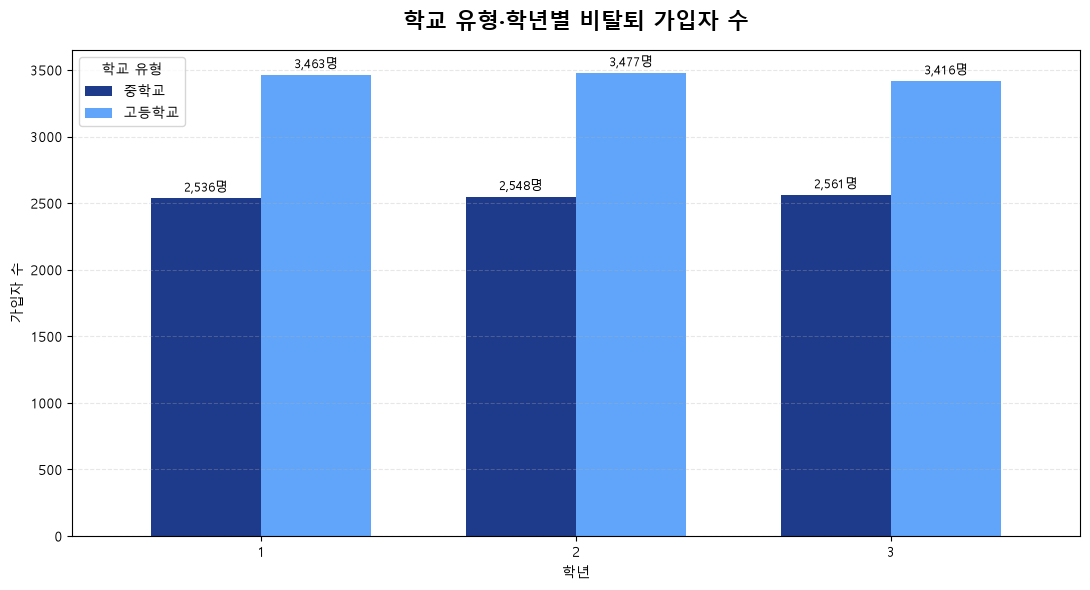

In [12]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

grade_chart = df_grade_non_withdrawn.copy()

# 학교 유형을 한글로 변경
grade_chart["school_type_label"] = (
    grade_chart["school_type"].replace({
        "MIDDLE": "중학교",
        "HIGH": "고등학교",
        "M": "중학교",
        "H": "고등학교"
    })
)

# 행은 학년, 열은 학교 유형
grade_pivot = grade_chart.pivot_table(
    index="grade",
    columns="school_type_label",
    values="user_count",
    aggfunc="sum",
    fill_value=0
)

# 중학교 → 고등학교 순서로 정렬
column_order = [
    column
    for column in ["중학교", "고등학교"]
    if column in grade_pivot.columns
]

grade_pivot = grade_pivot[column_order]

color_map = {
    "중학교": "#1E3A8A",
    "고등학교": "#60A5FA"
}

bar_colors = [
    color_map[column]
    for column in grade_pivot.columns
]

ax = grade_pivot.plot(
    kind="bar",
    figsize=(11, 6),
    color=bar_colors,
    width=0.7
)

# 막대 위에 가입자 수 표시
for container in ax.containers:
    labels = [
        f"{bar.get_height():,.0f}명"
        if bar.get_height() > 0 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

ax.set_title(
    "학교 유형·학년별 비탈퇴 가입자 수",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("학년")
ax.set_ylabel("가입자 수")
ax.legend(title="학교 유형")
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 지역(시도)별 가입자

가입자를 `grade_class`→`school`→`region` 으로 조인해 시도별 가입자 수를 센 뒤, 학교 한 곳당 평균 가입자 수를 구한다. 

왼쪽 그래프는 시도별 가입자 수, 오른쪽 그래프는 학교당 평균 가입자 수를 가로 막대로 보여준다.

In [16]:
region_non_withdrawn_signup_sql = """
WITH acquisition_users AS (
  -- 합성 가입자 중 탈퇴 기록이 없는 사용자
  SELECT
    u.id AS user_id,
    u.class_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

region_user_count AS (
  -- 시도별 비탈퇴 가입자 수
  SELECT
    r.sido,
    COUNT(DISTINCT u.user_id) AS user_count

  FROM acquisition_users AS u

  JOIN `ping-v2-503916.raw.grade_class` AS gc
    ON gc._source = 'local'
   AND u.class_id = gc.id
   AND gc._deleted_at IS NULL

  JOIN `ping-v2-503916.raw.school` AS s
    ON s._source = gc._source
   AND gc.school_id = s.id
   AND s._deleted_at IS NULL

  JOIN `ping-v2-503916.raw.region` AS r
    ON r._source = s._source
   AND s.region_id = r.id
   AND r._deleted_at IS NULL

  GROUP BY r.sido
),

region_school_count AS (
  -- 시도별 전체 학교 수
  SELECT
    r.sido,
    COUNT(DISTINCT s.id) AS school_count

  FROM `ping-v2-503916.raw.school` AS s

  JOIN `ping-v2-503916.raw.region` AS r
    ON r._source = s._source
   AND s.region_id = r.id
   AND r._deleted_at IS NULL

  WHERE s._source = 'local'
    AND s._deleted_at IS NULL

  GROUP BY r.sido
)

SELECT
  u.sido,
  u.user_count,
  s.school_count,

  ROUND(
    SAFE_DIVIDE(
      u.user_count,
      s.school_count
    ),
    2
  ) AS users_per_school

FROM region_user_count AS u

JOIN region_school_count AS s
  ON u.sido = s.sido

ORDER BY u.user_count DESC
"""

In [17]:
cost(region_non_withdrawn_signup_sql)

예상 스캔량: 0.653 MiB
예상 스캔량: 0.000638 GiB
월 1 TiB 무료 용량의 약 0.00006229%


0.0006377995014190674

In [18]:
df_region_non_withdrawn = bq.query(
    region_non_withdrawn_signup_sql
).to_dataframe()

df_region_non_withdrawn

,sido,user_count,school_count,users_per_school
0,부산광역시,4432,11,402.91
1,경기도,3375,9,375.00
2,전라남도,2525,4,631.25
3,대구광역시,2248,6,374.67
4,강원특별자치도,2234,5,446.80
5,경상남도,1392,3,464.00
6,서울특별시,1056,7,150.86
7,충청남도,575,3,191.67
8,인천광역시,106,1,106.00
9,경상북도,58,1,58.00


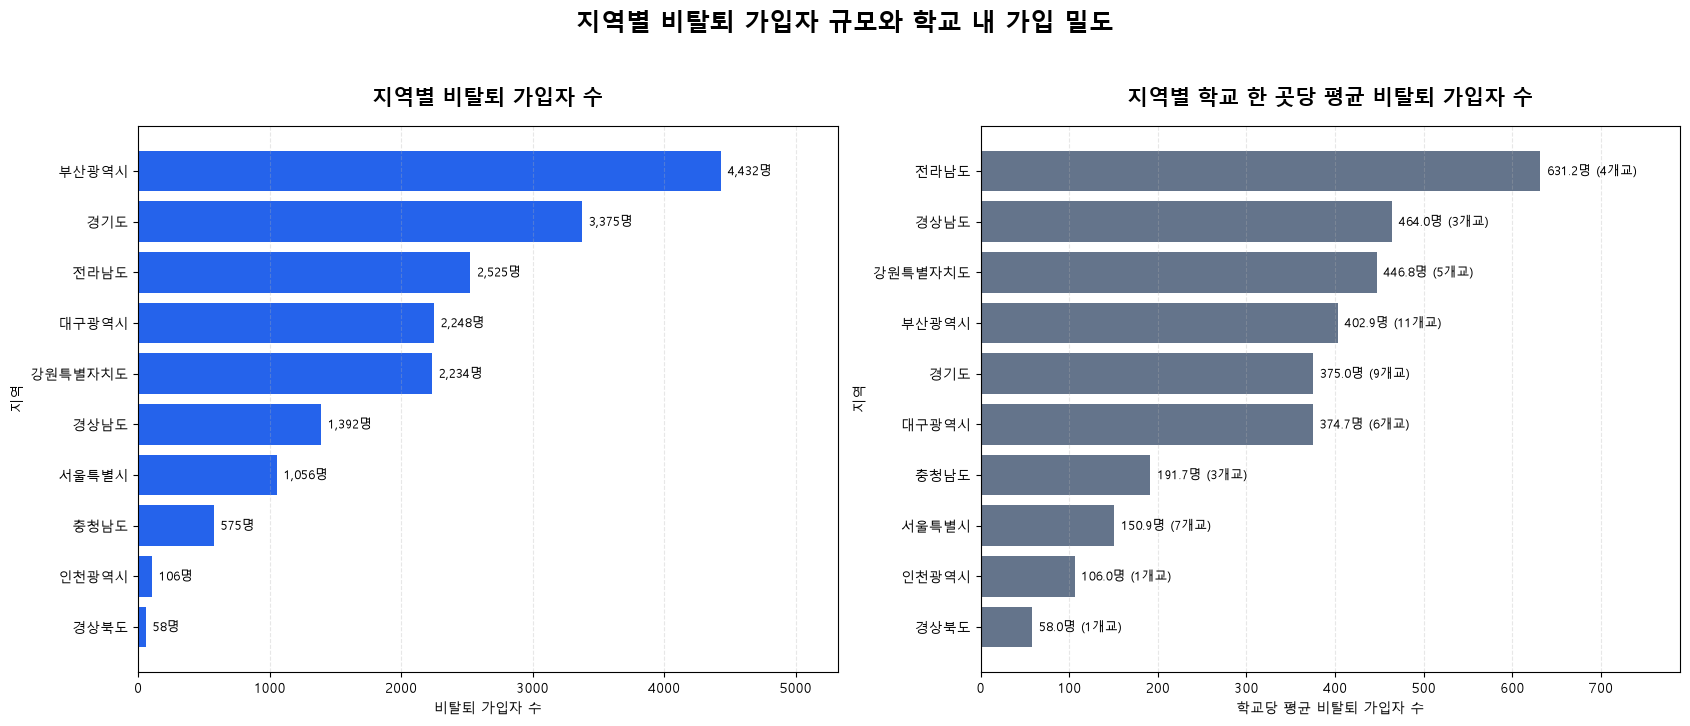

In [20]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

# 그래프별 정렬
count_chart = (
    df_region_non_withdrawn
    .sort_values("user_count", ascending=True)
    .copy()
)

average_chart = (
    df_region_non_withdrawn
    .sort_values("users_per_school", ascending=True)
    .copy()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 7)
)

# --------------------------------------------------
# 왼쪽: 지역별 비탈퇴 가입자 수
# --------------------------------------------------

bars1 = axes[0].barh(
    count_chart["sido"],
    count_chart["user_count"],
    color="#2563EB"
)

axes[0].bar_label(
    bars1,
    labels=[
        f"{value:,.0f}명"
        for value in count_chart["user_count"]
    ],
    padding=5,
    fontsize=9
)

axes[0].set_title(
    "지역별 비탈퇴 가입자 수",
    fontsize=15,
    fontweight="bold",
    pad=15
)
axes[0].set_xlabel("비탈퇴 가입자 수")
axes[0].set_ylabel("지역")
axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[0].set_xlim(
    0,
    count_chart["user_count"].max() * 1.2
)

# --------------------------------------------------
# 오른쪽: 지역별 학교 한 곳당 평균 가입자 수
# --------------------------------------------------

bars2 = axes[1].barh(
    average_chart["sido"],
    average_chart["users_per_school"],
    color="#64748B"
)

axes[1].bar_label(
    bars2,
    labels=[
        f"{average:,.1f}명 ({school_count:,.0f}개교)"
        for average, school_count in zip(
            average_chart["users_per_school"],
            average_chart["school_count"]
        )
    ],
    padding=5,
    fontsize=9
)

axes[1].set_title(
    "지역별 학교 한 곳당 평균 비탈퇴 가입자 수",
    fontsize=15,
    fontweight="bold",
    pad=15
)
axes[1].set_xlabel("학교당 평균 비탈퇴 가입자 수")
axes[1].set_ylabel("지역")
axes[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[1].set_xlim(
    0,
    average_chart["users_per_school"].max() * 1.25
)

fig.suptitle(
    "지역별 비탈퇴 가입자 규모와 학교 내 가입 밀도",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

## 성별 가입자

가입자 성별별 가입자 수와 전체 대비 비중을 구한다.

차트는 성별 라벨을 여성·남성·미입력으로 바꿔 막대 위에 인원수와 비율을 함께 표시한다.

In [21]:
gender_non_withdrawn_signup_sql = """
WITH acquisition_users AS (
  -- 합성 가입자 중 탈퇴 기록이 없는 사용자
  SELECT
    u.id AS user_id,
    COALESCE(
      CAST(u.gender AS STRING),
      'UNKNOWN'
    ) AS gender

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

gender_count AS (
  SELECT
    gender,
    COUNT(DISTINCT user_id) AS user_count
  FROM acquisition_users
  GROUP BY gender
)

SELECT
  gender,
  user_count,

  ROUND(
    SAFE_DIVIDE(
      user_count,
      SUM(user_count) OVER ()
    ) * 100,
    2
  ) AS user_share_percent

FROM gender_count
ORDER BY user_count DESC
"""

In [22]:
cost(gender_non_withdrawn_signup_sql)

예상 스캔량: 0.372 MiB
예상 스캔량: 0.000364 GiB
월 1 TiB 무료 용량의 약 0.00003551%


0.00036365166306495667

In [23]:
df_gender_non_withdrawn = bq.query(
    gender_non_withdrawn_signup_sql
).to_dataframe()

df_gender_non_withdrawn

,gender,user_count,user_share_percent
0,F,10628,59.04
1,M,7373,40.96


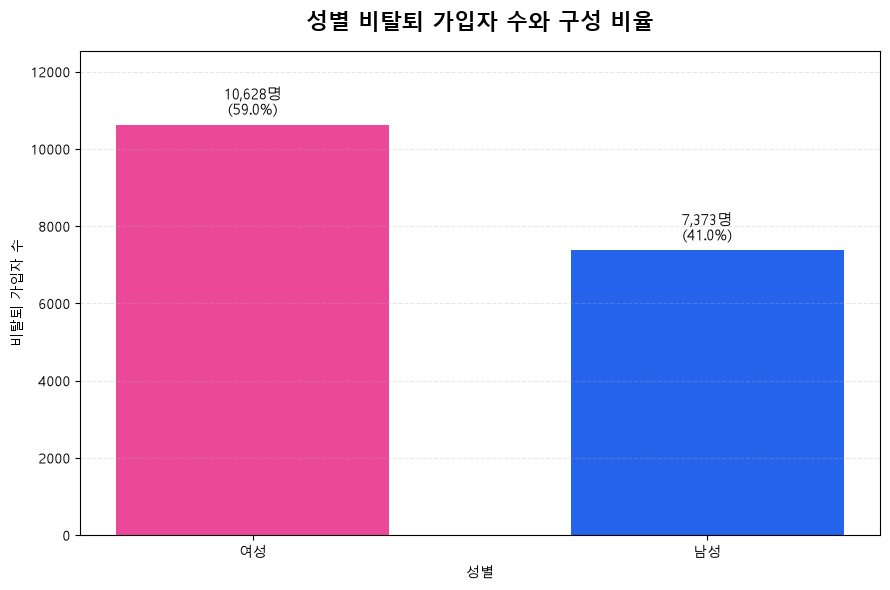

In [24]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

gender_chart = df_gender_non_withdrawn.copy()

gender_chart["gender_label"] = (
    gender_chart["gender"].replace({
        "F": "여성",
        "FEMALE": "여성",
        "M": "남성",
        "MALE": "남성",
        "UNKNOWN": "미입력"
    })
)

color_map = {
    "여성": "#EC4899",
    "남성": "#2563EB",
    "미입력": "#94A3B8"
}

bar_colors = [
    color_map.get(gender, "#64748B")
    for gender in gender_chart["gender_label"]
]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    gender_chart["gender_label"],
    gender_chart["user_count"],
    color=bar_colors,
    width=0.6
)

labels = [
    f"{count:,.0f}명\n({share:.1f}%)"
    for count, share in zip(
        gender_chart["user_count"],
        gender_chart["user_share_percent"]
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "성별 비탈퇴 가입자 수와 구성 비율",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("성별")
ax.set_ylabel("비탈퇴 가입자 수")
ax.set_ylim(
    0,
    gender_chart["user_count"].max() * 1.18
)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

---



# 활성화(activation) 퍼널 분석

BigQuery `raw` 데이터셋의 합성 데이터(`_source = 'local'`)를 대상으로,

가입부터 친구 5명 확보 → 투표 시작 → 투표 세션 완료 → 힌트 구매(1~3단계·이름 공개)까지 이어지는 활성화 퍼널의 각 단계별 사용자 수와 전환율을 SQL로 계산하고 막대그래프로 나타낸다.

각 단계는 탈퇴 사용자를 제외한 `app_user` 를 기준으로 하며, 마지막에는 전체 단계를 하나의 퍼널 표와 가로 막대그래프로 종합한다.

In [1]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

## 가입자 중 몇 명이 친구 5명을 확보했는가?

탈퇴 기록이 없는 `_source = 'local'` 가입자를 대상으로 `service_unlocked_at` 이
채워졌는지로 친구 5명 확보(서비스 잠금 해제) 여부를 센다. 

`unlock_rate_percent` 로 확보 비율을 계산하고, 확보/미확보 인원을 막대 그래프로 비교한다.

In [ ]:
# 가입자 중 몇 명이 친구 5명을 확보했는가?
q1_unlock_sql = """
WITH eligible_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 탈퇴한 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
)

SELECT
  COUNT(*) AS total_user_count,

  COUNTIF(
    service_unlocked_at IS NOT NULL
  ) AS unlocked_user_count,

  COUNTIF(
    service_unlocked_at IS NULL
  ) AS not_unlocked_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(service_unlocked_at IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS unlock_rate_percent

FROM eligible_users
"""

In [5]:
cost(q1_unlock_sql)

예상 스캔량: 0.457 MiB
예상 스캔량: 0.000446 GiB
월 1 TiB 무료 용량의 약 0.00004355%


0.00044596102088689804

In [6]:
df_q1 = bq.query(q1_unlock_sql).to_dataframe()
df_q1

,total_user_count,unlocked_user_count,not_unlocked_user_count,unlock_rate_percent
0,18001,16673,1328,92.62


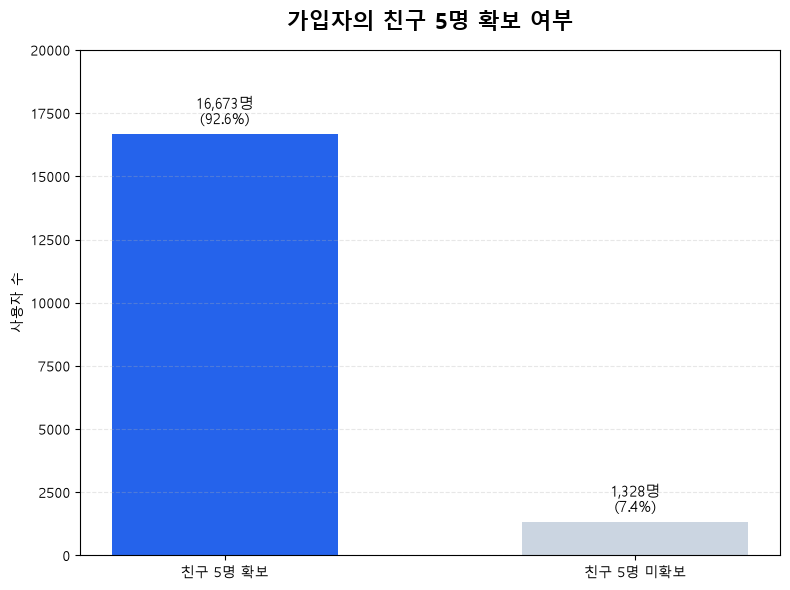

In [7]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

q1 = df_q1.iloc[0]

labels = [
    "친구 5명 확보",
    "친구 5명 미확보"
]

values = [
    q1["unlocked_user_count"],
    q1["not_unlocked_user_count"]
]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels,
    values,
    color=["#2563EB", "#CBD5E1"],
    width=0.55
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"({value / q1['total_user_count'] * 100:.1f}%)"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "가입자의 친구 5명 확보 여부",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("사용자 수")
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 친구 5명을 확보하기까지 평균 며칠이 걸리는가?

친구 5명을 확보한 사용자만 골라 `created_at` 부터 `service_unlocked_at` 까지의 일수(`unlock_days`)를 구하고, 평균·중앙값·최소·최대를 집계한다.

In [8]:
# 친구 5명을 확보하기까지 평균 며칠이 걸리는가?
q2_unlock_days_sql = """
WITH unlocked_users AS (
  SELECT
    u.id AS user_id,

    TIMESTAMP_DIFF(
      u.service_unlocked_at,
      u.created_at,
      SECOND
    ) / 86400.0 AS unlock_days

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    -- 탈퇴한 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
)

SELECT
  COUNT(*) AS unlocked_user_count,

  ROUND(
    AVG(unlock_days),
    2
  ) AS avg_unlock_days,

  ROUND(
    APPROX_QUANTILES(
      unlock_days,
      100
    )[OFFSET(50)],
    2
  ) AS median_unlock_days,

  ROUND(
    MIN(unlock_days),
    2
  ) AS min_unlock_days,

  ROUND(
    MAX(unlock_days),
    2
  ) AS max_unlock_days

FROM unlocked_users
"""

In [9]:
cost(q2_unlock_days_sql)

예상 스캔량: 0.609 MiB
예상 스캔량: 0.000595 GiB
월 1 TiB 무료 용량의 약 0.00005812%


0.0005951439961791039

In [10]:
df_q2 = bq.query(q2_unlock_days_sql).to_dataframe()
df_q2

,unlocked_user_count,avg_unlock_days,median_unlock_days,min_unlock_days,max_unlock_days
0,16673,1.53,1.54,0.04,3.0


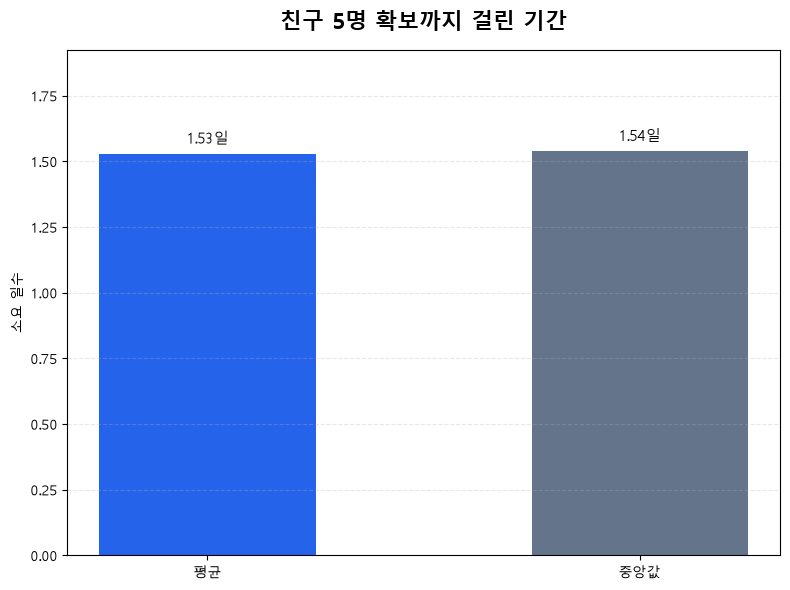

In [11]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

q2 = df_q2.iloc[0]

labels = [
    "평균",
    "중앙값"
]

values = [
    q2["avg_unlock_days"],
    q2["median_unlock_days"]
]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels,
    values,
    color=["#2563EB", "#64748B"],
    width=0.5
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}일"
        for value in values
    ],
    padding=5,
    fontsize=11
)

ax.set_title(
    "친구 5명 확보까지 걸린 기간",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("소요 일수")
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 친구 조건을 충족한 사용자는 실제로 투표를 시작하는가?

친구 5명을 확보한 사용자 중 `service_unlocked_at` 이후에 시작된 `vote_session` 이 하나라도 있는지로 

투표 시작 여부를 계산하고, 시작/미시작 인원을 막대그래프로 비교한다.

In [12]:
# 친구 조건을 충족한 사용자는 실제로 투표를 시작하는가?
q3_vote_start_sql = """
WITH unlocked_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    -- 탈퇴한 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

vote_started_users AS (
  SELECT DISTINCT
    u.user_id

  FROM unlocked_users AS u

  JOIN `ping-v2-503916.raw.vote_session` AS vs
    ON vs._source = 'local'
   AND vs.user_id = u.user_id
   AND vs._deleted_at IS NULL
   AND vs.started_at >= u.service_unlocked_at
)

SELECT
  COUNT(*) AS unlocked_user_count,

  COUNTIF(
    v.user_id IS NOT NULL
  ) AS vote_started_user_count,

  COUNTIF(
    v.user_id IS NULL
  ) AS vote_not_started_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_start_rate_percent

FROM unlocked_users AS u

LEFT JOIN vote_started_users AS v
  ON u.user_id = v.user_id
"""

In [13]:
cost(q3_vote_start_sql)

예상 스캔량: 33.061 MiB
예상 스캔량: 0.032286 GiB
월 1 TiB 무료 용량의 약 0.00315294%


0.03228606376796961

In [14]:
df_q3 = bq.query(q3_vote_start_sql).to_dataframe()
df_q3

,unlocked_user_count,vote_started_user_count,vote_not_started_user_count,vote_start_rate_percent
0,16673,14907,1766,89.41


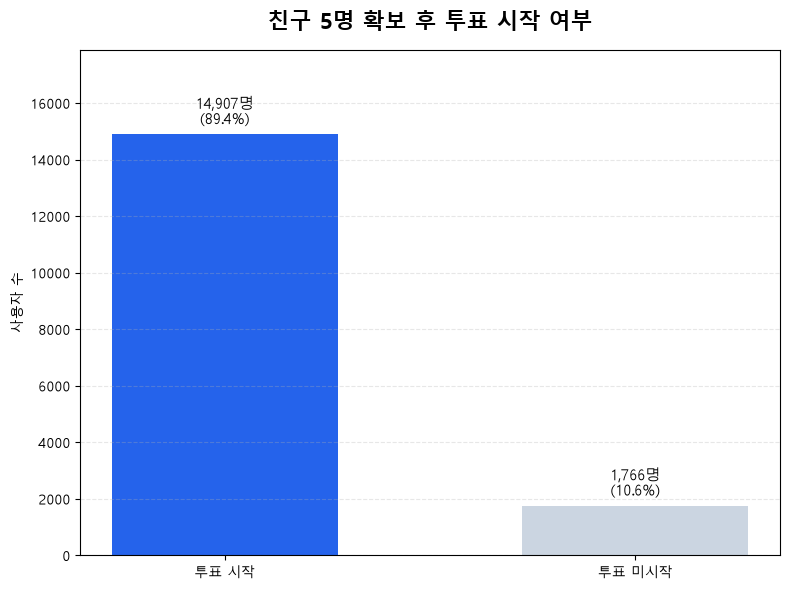

In [15]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

q3 = df_q3.iloc[0]

labels = [
    "투표 시작",
    "투표 미시작"
]

values = [
    q3["vote_started_user_count"],
    q3["vote_not_started_user_count"]
]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels,
    values,
    color=["#2563EB", "#CBD5E1"],
    width=0.55
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"({value / q3['unlocked_user_count'] * 100:.1f}%)"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "친구 5명 확보 후 투표 시작 여부",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("사용자 수")
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 투표를 시작했지만 완료하지 못한 사용자는 얼마나 되는가?

친구 5명 확보 후 투표를 시작한 사용자 중 

`status = 'COMPLETED'` 이고 `completed_at` 이 채워진 세션이 있는 사용자를 투표 완료로 구분하여,

`vote_completion_rate_percent` 와 `started_not_completed_rate_percent` 를 구하고 막대그래프로 비교한다.

In [16]:
# 투표를 시작했지만 완료하지 못한 사용자는 얼마나 되는가?
q4_vote_completion_sql = """
WITH unlocked_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    -- 탈퇴한 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

vote_started_users AS (
  SELECT DISTINCT
    u.user_id

  FROM unlocked_users AS u

  JOIN `ping-v2-503916.raw.vote_session` AS vs
    ON vs._source = 'local'
   AND vs.user_id = u.user_id
   AND vs._deleted_at IS NULL
   AND vs.started_at >= u.service_unlocked_at
),

vote_completed_users AS (
  SELECT DISTINCT
    u.user_id

  FROM unlocked_users AS u

  JOIN `ping-v2-503916.raw.vote_session` AS vs
    ON vs._source = 'local'
   AND vs.user_id = u.user_id
   AND vs._deleted_at IS NULL
   AND vs.started_at >= u.service_unlocked_at
   AND vs.status = 'COMPLETED'
   AND vs.completed_at IS NOT NULL
)

SELECT
  COUNT(*) AS vote_started_user_count,

  COUNTIF(
    c.user_id IS NOT NULL
  ) AS vote_completed_user_count,

  COUNTIF(
    c.user_id IS NULL
  ) AS started_not_completed_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(c.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_completion_rate_percent,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(c.user_id IS NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS started_not_completed_rate_percent

FROM vote_started_users AS s

LEFT JOIN vote_completed_users AS c
  ON s.user_id = c.user_id
"""

In [17]:
cost(q4_vote_completion_sql)

예상 스캔량: 57.775 MiB
예상 스캔량: 0.056420 GiB
월 1 TiB 무료 용량의 약 0.00550981%


0.05642044451087713

In [18]:
df_q4 = bq.query(
    q4_vote_completion_sql
).to_dataframe()

df_q4

,vote_started_user_count,vote_completed_user_count,started_not_completed_user_count,vote_completion_rate_percent,started_not_completed_rate_percent
0,14907,12482,2425,83.73,16.27


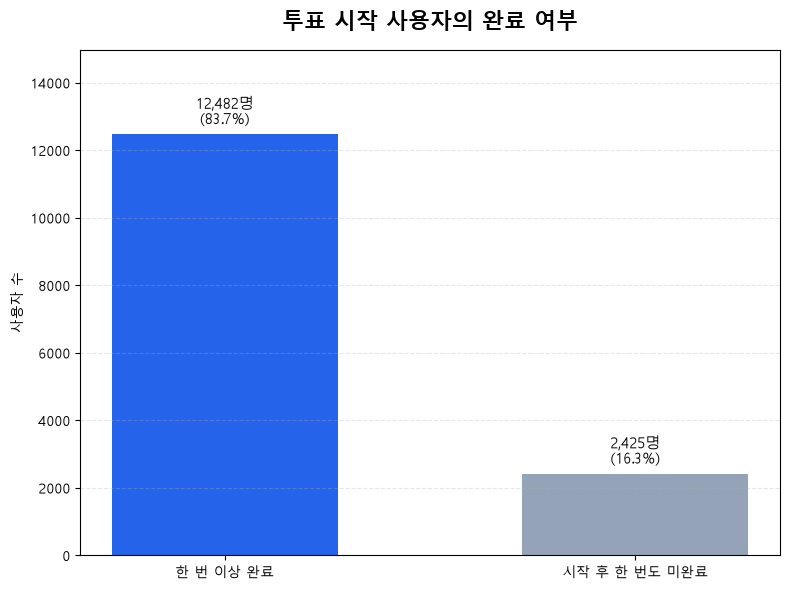

In [19]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

q4 = df_q4.iloc[0]

labels = [
    "한 번 이상 완료",
    "시작 후 한 번도 미완료"
]

values = [
    q4["vote_completed_user_count"],
    q4["started_not_completed_user_count"]
]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels,
    values,
    color=["#2563EB", "#94A3B8"],
    width=0.55
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"({value / q4['vote_started_user_count'] * 100:.1f}%)"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "투표 시작 사용자의 완료 여부",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("사용자 수")
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 친구 5명 미확보 사용자의 투표 여부

`service_unlocked_at IS NULL` 인(친구 5명을 못 채운) 탈퇴하지 않은 사용자를 대상으로,

`vote_session` 을 시작한 인원과 `vote_item.voted_at` 이 채워진 투표한 인원을 센다.

In [20]:
# 친구 5명 미확보 사용자의 투표 여부
q_locked_vote_sql = """
WITH locked_users AS (
  SELECT
    u.id AS user_id,
    u.friend_count,
    u.created_at AS signup_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 친구 5명 게이트를 통과하지 않은 사용자
    AND u.service_unlocked_at IS NULL

    -- 탈퇴 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

vote_session_users AS (
  -- 투표 세션을 시작한 사용자
  SELECT DISTINCT
    vs.user_id
  FROM `ping-v2-503916.raw.vote_session` AS vs
  WHERE vs._source = 'local'
    AND vs._deleted_at IS NULL
),

actual_vote_users AS (
  -- 후보를 실제로 선택한 사용자
  SELECT DISTINCT
    vi.user_id
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
)

SELECT
  COUNT(*) AS locked_user_count,

  -- 투표 세션은 생성된 사용자
  COUNTIF(
    vs.user_id IS NOT NULL
  ) AS session_started_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(vs.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS session_started_rate_percent,

  -- 실제 후보를 선택한 사용자
  COUNTIF(
    av.user_id IS NOT NULL
  ) AS actual_vote_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(av.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS actual_vote_rate_percent

FROM locked_users AS u

LEFT JOIN vote_session_users AS vs
  ON u.user_id = vs.user_id

LEFT JOIN actual_vote_users AS av
  ON u.user_id = av.user_id
"""

In [21]:
cost(q_locked_vote_sql)

예상 스캔량: 312.842 MiB
예상 스캔량: 0.305509 GiB
월 1 TiB 무료 용량의 약 0.02983489%


0.3055093204602599

In [22]:
df_locked_vote = bq.query(
    q_locked_vote_sql
).to_dataframe()

df_locked_vote

,locked_user_count,session_started_user_count,session_started_rate_percent,actual_vote_user_count,actual_vote_rate_percent
0,1328,0,0.0,0,0.0


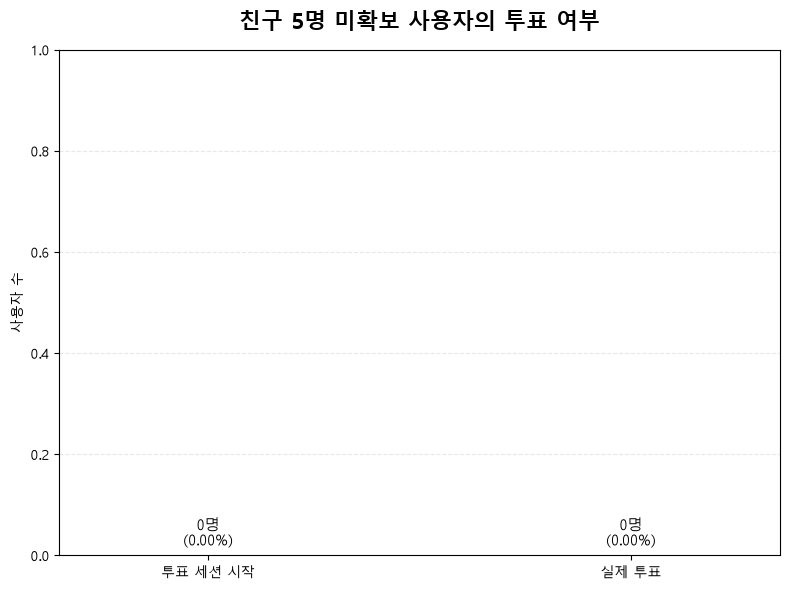

In [23]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

result = df_locked_vote.iloc[0]

labels = [
    "투표 세션 시작",
    "실제 투표"
]

values = [
    result["session_started_user_count"],
    result["actual_vote_user_count"]
]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels,
    values,
    color=["#94A3B8", "#DC2626"],
    width=0.55
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"({value / result['locked_user_count'] * 100:.2f}%)"
    if result["locked_user_count"] > 0
    else "0명"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "친구 5명 미확보 사용자의 투표 여부",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("사용자 수")
ax.set_ylim(
    0,
    max(values) * 1.25 if max(values) > 0 else 1
)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 가입자, 탈퇴자, 현재 비탈퇴 사용자 비교

가입자 중 유효한 탈퇴 기록이 있는 사용자 수와 비율과 탈퇴하지 않은 사용자 수와 비율을 표로 비교한다.

In [24]:
# 가입자, 탈퇴자, 현재 비탈퇴 사용자 비교
user_status_comparison_sql = """
WITH synthetic_users AS (
  -- 삭제되지 않은 전체 합성 가입자
  SELECT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
),

withdrawn_users AS (
  -- 유효한 탈퇴 기록이 있는 사용자
  SELECT DISTINCT
    w.user_id
  FROM `ping-v2-503916.raw.user_withdrawal` AS w
  WHERE w._source = 'local'
    AND w._deleted_at IS NULL
)

SELECT
  -- 서비스에 가입한 전체 사용자
  COUNT(*) AS total_signup_user_count,

  -- 탈퇴 기록이 있는 사용자
  COUNTIF(
    w.user_id IS NOT NULL
  ) AS withdrawn_user_count,

  -- 탈퇴 기록이 없는 사용자
  COUNTIF(
    w.user_id IS NULL
  ) AS non_withdrawn_user_count,

  -- 탈퇴율
  ROUND(
    SAFE_DIVIDE(
      COUNTIF(w.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS withdrawal_rate_percent,

  -- 비탈퇴 사용자 비율
  ROUND(
    SAFE_DIVIDE(
      COUNTIF(w.user_id IS NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS non_withdrawal_rate_percent

FROM synthetic_users AS u

LEFT JOIN withdrawn_users AS w
  ON u.user_id = w.user_id
"""

In [25]:
cost(user_status_comparison_sql)

예상 스캔량: 0.315 MiB
예상 스캔량: 0.000308 GiB
월 1 TiB 무료 용량의 약 0.00003005%


0.0003077080473303795

In [26]:
df_user_status = bq.query(
    user_status_comparison_sql
).to_dataframe()

df_user_status

,total_signup_user_count,withdrawn_user_count,non_withdrawn_user_count,withdrawal_rate_percent,non_withdrawal_rate_percent
0,20000,1999,18001,9.99,90.0


## 탈퇴하지 않은 가입자 중 몇 %가 투표를 시작하고 10문항 사이클을 완료하는가?

In [27]:
vote_cycle_comparison_sql = """
WITH eligible_users AS (
  -- 합성 가입자 중 탈퇴 기록이 없는 사용자
  SELECT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

voted_users AS (
  -- 실제로 후보를 한 번이라도 선택한 사용자
  SELECT DISTINCT
    vi.user_id
  FROM `ping-v2-503916.raw.vote_item` AS vi

  JOIN eligible_users AS u
    ON vi.user_id = u.user_id

  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

completed_vote_sessions AS (
  -- 실제 투표 10개를 모두 완료한 세션
  SELECT
    vs.user_id,
    vs.id AS session_id

  FROM `ping-v2-503916.raw.vote_session` AS vs

  JOIN eligible_users AS u
    ON vs.user_id = u.user_id

  JOIN `ping-v2-503916.raw.vote_item` AS vi
    ON vi._source = vs._source
   AND vi.session_id = vs.id
   AND vi._deleted_at IS NULL

  WHERE vs._source = 'local'
    AND vs._deleted_at IS NULL
    AND vs.status = 'COMPLETED'
    AND vs.completed_at IS NOT NULL
    AND vs.item_count = 10

  GROUP BY
    vs.user_id,
    vs.id

  HAVING COUNT(
    DISTINCT IF(
      vi.voted_at IS NOT NULL,
      vi.id,
      NULL
    )
  ) >= 10
),

completed_cycle_users AS (
  -- 10문항 사이클을 한 번이라도 완료한 사용자
  SELECT DISTINCT
    user_id
  FROM completed_vote_sessions
)

SELECT
  COUNT(*) AS eligible_user_count,

  COUNTIF(
    v.user_id IS NOT NULL
  ) AS voted_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS voted_user_rate_percent,

  COUNTIF(
    c.user_id IS NOT NULL
  ) AS completed_cycle_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(c.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS completed_cycle_rate_percent,

  -- 한 번 이상 투표했지만 10문항은 완료하지 못한 사용자
  COUNTIF(
    v.user_id IS NOT NULL
    AND c.user_id IS NULL
  ) AS voted_not_completed_user_count,

  -- 한 번 이상 투표한 사용자 중 10문항 완료율
  ROUND(
    SAFE_DIVIDE(
      COUNTIF(c.user_id IS NOT NULL),
      COUNTIF(v.user_id IS NOT NULL)
    ) * 100,
    2
  ) AS completion_rate_among_voters_percent

FROM eligible_users AS u

LEFT JOIN voted_users AS v
  ON u.user_id = v.user_id

LEFT JOIN completed_cycle_users AS c
  ON u.user_id = c.user_id
"""

In [28]:
cost(vote_cycle_comparison_sql)

예상 스캔량: 565.253 MiB
예상 스캔량: 0.552005 GiB
월 1 TiB 무료 용량의 약 0.05390676%


0.5520052360370755

In [29]:
df_vote_cycle = bq.query(
    vote_cycle_comparison_sql
).to_dataframe()

df_vote_cycle

,eligible_user_count,voted_user_count,voted_user_rate_percent,completed_cycle_user_count,completed_cycle_rate_percent,voted_not_completed_user_count,completion_rate_among_voters_percent
0,18001,14889,82.71,11025,61.25,3864,74.05


In [30]:
result = df_vote_cycle.iloc[0]

print(
    f"전체 분석 대상: "
    f"{result['eligible_user_count']:,.0f}명"
)

print(
    f"한 번이라도 투표한 사용자: "
    f"{result['voted_user_count']:,.0f}명 "
    f"({result['voted_user_rate_percent']:.2f}%)"
)

print(
    f"10문항 사이클 완료 사용자: "
    f"{result['completed_cycle_user_count']:,.0f}명 "
    f"({result['completed_cycle_rate_percent']:.2f}%)"
)

print(
    f"투표는 했지만 10문항을 완료하지 못한 사용자: "
    f"{result['voted_not_completed_user_count']:,.0f}명"
)

print(
    f"투표 사용자 중 10문항 완료율: "
    f"{result['completion_rate_among_voters_percent']:.2f}%"
)

전체 분석 대상: 18,001명
한 번이라도 투표한 사용자: 14,889명 (82.71%)
10문항 사이클 완료 사용자: 11,025명 (61.25%)
투표는 했지만 10문항을 완료하지 못한 사용자: 3,864명
투표 사용자 중 10문항 완료율: 74.05%


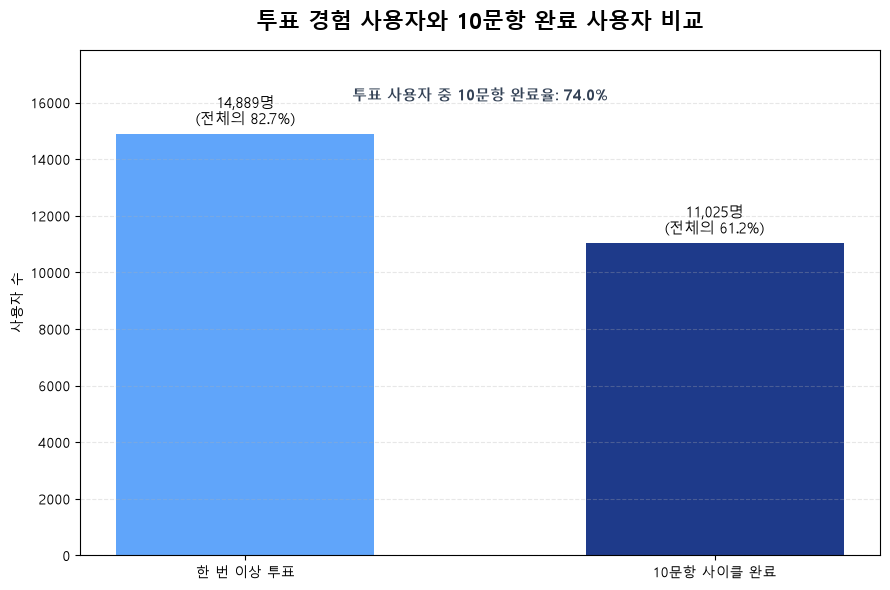

In [31]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

result = df_vote_cycle.iloc[0]

total_count = int(
    result["eligible_user_count"]
)

labels = [
    "한 번 이상 투표",
    "10문항 사이클 완료"
]

values = [
    result["voted_user_count"],
    result["completed_cycle_user_count"]
]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    labels,
    values,
    color=["#60A5FA", "#1E3A8A"],
    width=0.55
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"(전체의 {value / total_count * 100:.1f}%)"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "투표 경험 사용자와 10문항 완료 사용자 비교",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("사용자 수")
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# 투표 사용자 중 완료율 표시
ax.text(
    0.5,
    max(values) * 1.08,
    (
        "투표 사용자 중 10문항 완료율: "
        f"{result['completion_rate_among_voters_percent']:.1f}%"
    ),
    ha="center",
    fontsize=11,
    fontweight="bold",
    color="#334155"
)

plt.tight_layout()
plt.show()

## 첫 10문항 완료 이후 발생한 힌트 구매만 집계

10문항 사이클을 완료한 사용자의 최초 완료 시각 이후에 생긴 힌트 구매만 골라, 사용자별로 도달한 최고 힌트 단계를 구한다.

1단계 이상·2단계 이상·3단계 이상·이름 공개 구매 인원과, 직전 단계 대비 전환율을 계산하고 요약 문장과 막대그래프로 낸다.

In [ ]:
# 첫 10문항 완료 이후 발생한 힌트 구매만 집계
completed_user_hint_funnel_sql = """
WITH eligible_users AS (
  -- 합성 데이터 중 탈퇴하지 않은 사용자
  SELECT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

completed_sessions AS (
  -- 실제 투표 10개를 모두 완료한 세션
  SELECT
    vs.user_id,
    vs.id AS session_id,
    vs.completed_at

  FROM `ping-v2-503916.raw.vote_session` AS vs

  JOIN eligible_users AS u
    ON vs.user_id = u.user_id

  JOIN `ping-v2-503916.raw.vote_item` AS vi
    ON vi._source = vs._source
   AND vi.session_id = vs.id
   AND vi._deleted_at IS NULL

  WHERE vs._source = 'local'
    AND vs._deleted_at IS NULL
    AND vs.status = 'COMPLETED'
    AND vs.completed_at IS NOT NULL
    AND vs.item_count = 10

  GROUP BY
    vs.user_id,
    vs.id,
    vs.completed_at

  HAVING COUNT(
    DISTINCT IF(
      vi.voted_at IS NOT NULL,
      vi.id,
      NULL
    )
  ) >= 10
),

completed_users AS (
  -- 사용자별 최초 10문항 완료 시각
  SELECT
    user_id,
    MIN(completed_at) AS first_completed_at
  FROM completed_sessions
  GROUP BY user_id
),

hint_depth_by_user AS (
  SELECT
    c.user_id,

    -- 첫 투표 완료 이후 도달한 최고 힌트 단계
    COALESCE(
      MAX(hp.step),
      0
    ) AS max_hint_step

  FROM completed_users AS c

  LEFT JOIN `ping-v2-503916.raw.hint_purchase` AS hp
    ON hp._source = 'local'
   AND hp.user_id = c.user_id
   AND hp._deleted_at IS NULL

   -- 첫 10문항 완료 이후 구매한 힌트만 집계
   AND hp.created_at >= c.first_completed_at

  GROUP BY c.user_id
)

SELECT
  -- 10문항 투표 세션 완료 사용자
  COUNT(*) AS completed_cycle_user_count,

  -- 1단계 이상 구매
  COUNTIF(
    max_hint_step >= 1
  ) AS hint_step1_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(max_hint_step >= 1),
      COUNT(*)
    ) * 100,
    2
  ) AS hint_step1_rate_percent,

  -- 2단계 이상 구매
  COUNTIF(
    max_hint_step >= 2
  ) AS hint_step2_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(max_hint_step >= 2),
      COUNTIF(max_hint_step >= 1)
    ) * 100,
    2
  ) AS hint_step2_conversion_percent,

  -- 3단계 이상 구매
  COUNTIF(
    max_hint_step >= 3
  ) AS hint_step3_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(max_hint_step >= 3),
      COUNTIF(max_hint_step >= 2)
    ) * 100,
    2
  ) AS hint_step3_conversion_percent,

  -- 이름 공개까지 구매
  COUNTIF(
    max_hint_step >= 4
  ) AS full_name_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(max_hint_step >= 4),
      COUNTIF(max_hint_step >= 3)
    ) * 100,
    2
  ) AS full_name_conversion_percent

FROM hint_depth_by_user
"""

In [33]:
cost(completed_user_hint_funnel_sql)

예상 스캔량: 510.450 MiB
예상 스캔량: 0.498486 GiB
월 1 TiB 무료 용량의 약 0.04868030%


0.498486272059381

In [34]:
df_hint_funnel = bq.query(
    completed_user_hint_funnel_sql
).to_dataframe()

df_hint_funnel

,completed_cycle_user_count,hint_step1_user_count,hint_step1_rate_percent,hint_step2_user_count,hint_step2_conversion_percent,hint_step3_user_count,hint_step3_conversion_percent,full_name_user_count,full_name_conversion_percent
0,11025,8638,78.35,8285,95.91,7686,92.77,6701,87.18


In [35]:
result = df_hint_funnel.iloc[0]

print(
    f"10문항 완료: "
    f"{result['completed_cycle_user_count']:,.0f}명"
)

print(
    f"1단계 힌트 구매: "
    f"{result['hint_step1_user_count']:,.0f}명 "
    f"({result['hint_step1_rate_percent']:.2f}%)"
)

print(
    f"2단계 힌트 구매: "
    f"{result['hint_step2_user_count']:,.0f}명"
)

print(
    f"3단계 힌트 구매: "
    f"{result['hint_step3_user_count']:,.0f}명"
)

print(
    f"이름 공개 구매: "
    f"{result['full_name_user_count']:,.0f}명"
)

10문항 완료: 11,025명
1단계 힌트 구매: 8,638명 (78.35%)
2단계 힌트 구매: 8,285명
3단계 힌트 구매: 7,686명
이름 공개 구매: 6,701명


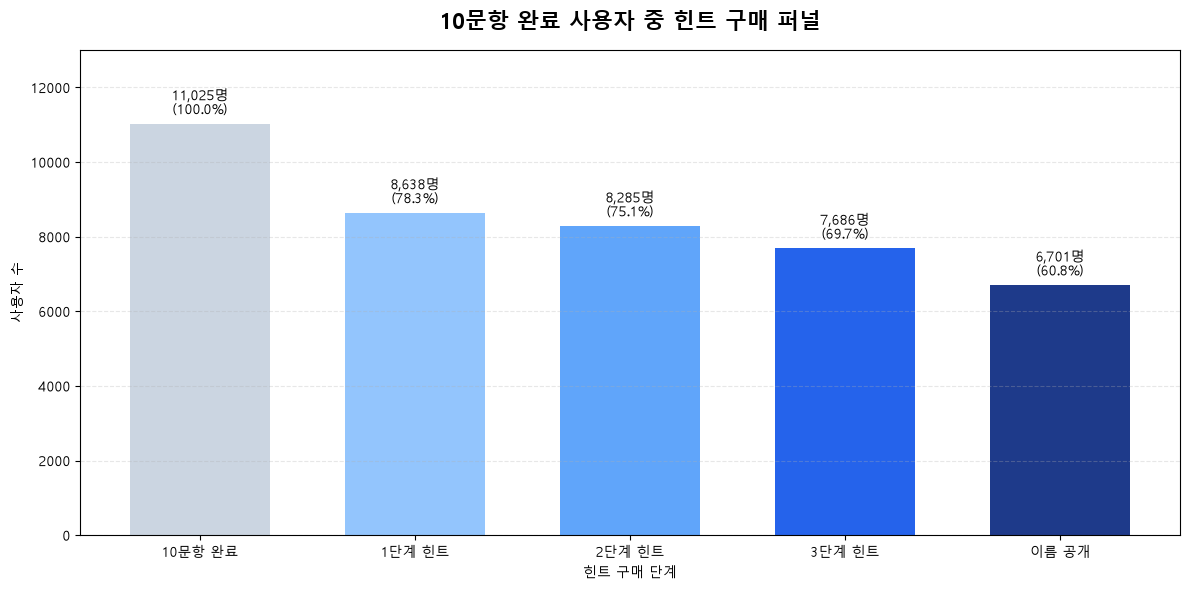

In [38]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

result = df_hint_funnel.iloc[0]

labels = [
    "10문항 완료",
    "1단계 힌트",
    "2단계 힌트",
    "3단계 힌트",
    "이름 공개"
]

values = [
    result["completed_cycle_user_count"],
    result["hint_step1_user_count"],
    result["hint_step2_user_count"],
    result["hint_step3_user_count"],
    result["full_name_user_count"]
]

base_count = values[0]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    labels,
    values,
    color=[
        "#CBD5E1",
        "#93C5FD",
        "#60A5FA",
        "#2563EB",
        "#1E3A8A"
    ],
    width=0.65
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"({value / base_count * 100:.1f}%)"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=10
)

ax.set_title(
    "10문항 완료 사용자 중 힌트 구매 퍼널",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("힌트 구매 단계")
ax.set_ylabel("사용자 수")
ax.set_ylim(0, max(values) * 1.18)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 가입부터 이름 공개 구매까지 전체 퍼널

앞 단계별 인원 수(가입 완료 18,001명 → 친구 5명 확보 → 투표 시작 → 투표 세션 완료 → 1·2·3단계 힌트 구매 → 이름 공개 구매)를 하나의 표로 모아

직전 단계 대비 전환율, 최초 가입자 대비 전환율, 단계별 이탈자 수를 계산하고, 가로 막대 퍼널 차트로 그린다.

In [39]:
import platform
import pandas as pd
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

# --------------------------------------------------
# 퍼널 데이터
# --------------------------------------------------

stages = [
    "가입 완료",
    "친구 5명 확보",
    "투표 시작",
    "투표 세션 완료",
    "1단계 힌트 구매",
    "2단계 힌트 구매",
    "3단계 힌트 구매",
    "이름 공개 구매"
]

user_counts = [
    18001,
    16673,
    14889,
    11025,
    8638,
    8285,
    7686,
    6701
]

funnel_df = pd.DataFrame({
    "stage": stages,
    "user_count": user_counts
})

# 직전 단계 대비 전환율
funnel_df["step_conversion_rate"] = (
    funnel_df["user_count"]
    / funnel_df["user_count"].shift(1)
    * 100
)

funnel_df.loc[0, "step_conversion_rate"] = 100

# 최초 가입자 대비 전환율
funnel_df["overall_conversion_rate"] = (
    funnel_df["user_count"]
    / funnel_df.loc[0, "user_count"]
    * 100
)

# 직전 단계 대비 이탈자 수
funnel_df["drop_count"] = (
    funnel_df["user_count"].shift(1)
    - funnel_df["user_count"]
)

funnel_df.loc[0, "drop_count"] = 0

funnel_df

,stage,user_count,step_conversion_rate,overall_conversion_rate,drop_count
0,가입 완료,18001,100.000000,100.000000,0.0
1,친구 5명 확보,16673,92.622632,92.622632,1328.0
2,투표 시작,14889,89.300066,82.712072,1784.0
3,투표 세션 완료,11025,74.047955,61.246597,3864.0
4,1단계 힌트 구매,8638,78.349206,47.986223,2387.0
5,2단계 힌트 구매,8285,95.913406,46.025221,353.0
6,3단계 힌트 구매,7686,92.770066,42.697628,599.0
7,이름 공개 구매,6701,87.184491,37.225710,985.0


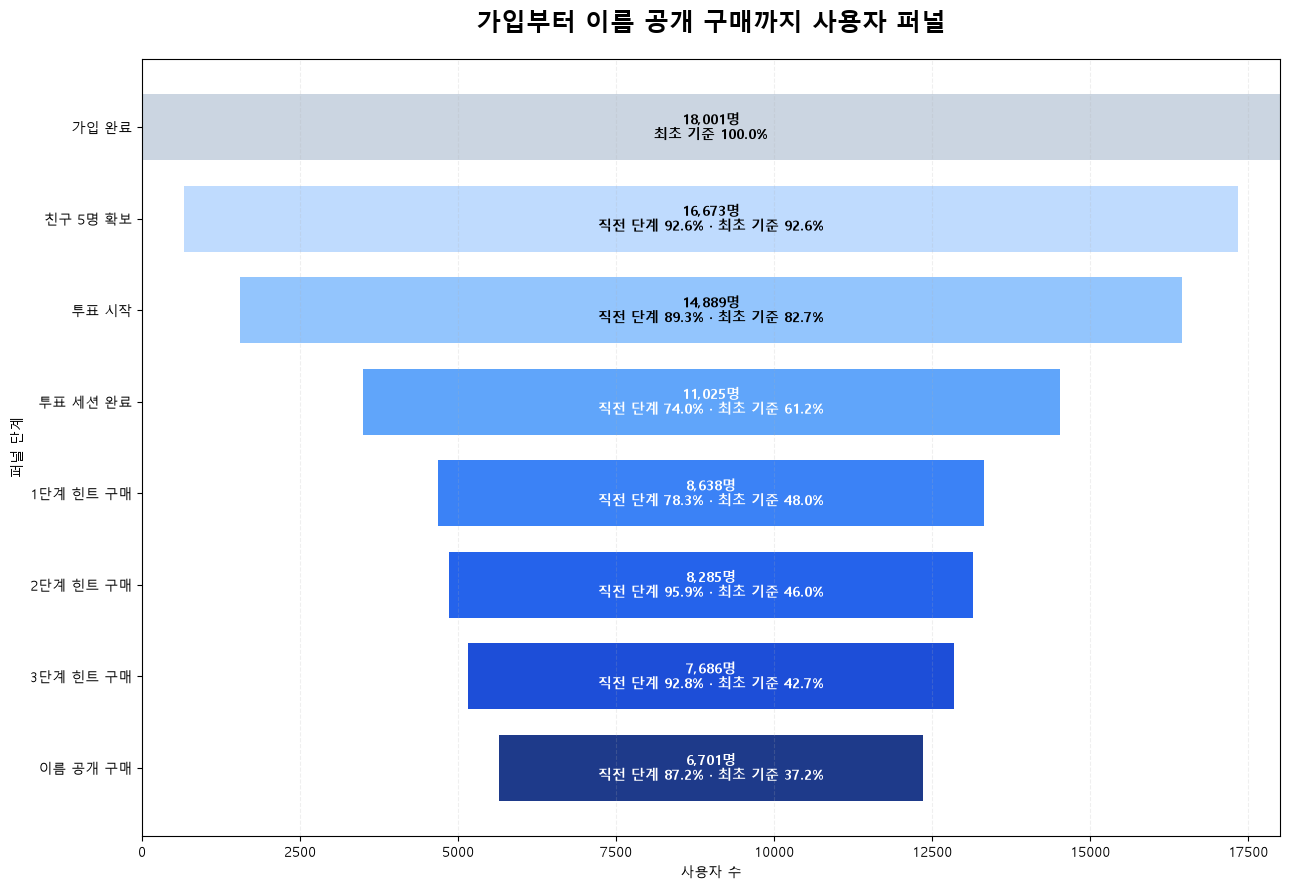

In [40]:
max_count = funnel_df["user_count"].max()

# 막대를 가운데 정렬하기 위한 시작 위치
left_positions = (
    max_count - funnel_df["user_count"]
) / 2

colors = [
    "#CBD5E1",
    "#BFDBFE",
    "#93C5FD",
    "#60A5FA",
    "#3B82F6",
    "#2563EB",
    "#1D4ED8",
    "#1E3A8A"
]

fig, ax = plt.subplots(figsize=(13, 9))

bars = ax.barh(
    funnel_df["stage"],
    funnel_df["user_count"],
    left=left_positions,
    color=colors,
    height=0.72
)

# 가입부터 이름 공개 순서로 위에서 아래로 표시
ax.invert_yaxis()

# 막대 안에 사용자 수와 전환율 표시
for index, bar in enumerate(bars):
    count = funnel_df.loc[index, "user_count"]
    step_rate = funnel_df.loc[
        index,
        "step_conversion_rate"
    ]
    overall_rate = funnel_df.loc[
        index,
        "overall_conversion_rate"
    ]

    center_x = max_count / 2
    center_y = bar.get_y() + bar.get_height() / 2

    # 밝은 막대에는 검은색, 진한 막대에는 흰색
    text_color = "black" if index <= 2 else "white"

    if index == 0:
        label = (
            f"{count:,}명\n"
            f"최초 기준 {overall_rate:.1f}%"
        )
    else:
        label = (
            f"{count:,}명\n"
            f"직전 단계 {step_rate:.1f}% · "
            f"최초 기준 {overall_rate:.1f}%"
        )

    ax.text(
        center_x,
        center_y,
        label,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=text_color
    )

ax.set_title(
    "가입부터 이름 공개 구매까지 사용자 퍼널",
    fontsize=18,
    fontweight="bold",
    pad=20
)
ax.set_xlabel("사용자 수")
ax.set_ylabel("퍼널 단계")

ax.set_xlim(0, max_count)
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

plt.tight_layout()
plt.show()

## 가입 완료부터 투표 세션 완료까지 퍼널 요약

위 종합 퍼널 중 앞 네 단계(가입 완료·친구 5명 확보·투표 시작·투표 세션 완료)만 뽑아 막대그래프로 보여준다.

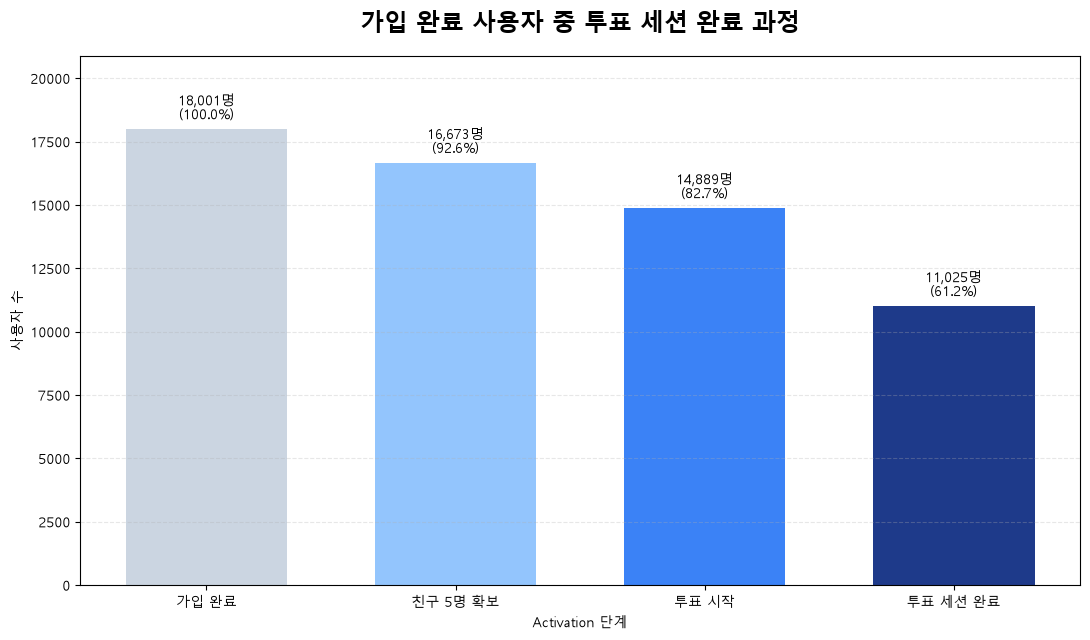

In [42]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

# --------------------------------------------------
# 데이터
# --------------------------------------------------

labels = [
    "가입 완료",
    "친구 5명 확보",
    "투표 시작",
    "투표 세션 완료"
]

values = [
    18001,
    16673,
    14889,
    11025
]

base_count = values[0]

# 가입 완료 대비 도달률
overall_rates = [
    value / base_count * 100
    for value in values
]

colors = [
    "#CBD5E1",
    "#93C5FD",
    "#3B82F6",
    "#1E3A8A"
]

# --------------------------------------------------
# 막대그래프
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6.5))

bars = ax.bar(
    labels,
    values,
    color=colors,
    width=0.65
)

# 막대 위에 사용자 수와 비율 표시
bar_labels = [
    f"{value:,}명\n({rate:.1f}%)"
    for value, rate in zip(
        values,
        overall_rates
    )
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=10
)

ax.set_title(
    "가입 완료 사용자 중 투표 세션 완료 과정",
    fontsize=17,
    fontweight="bold",
    pad=18
)
ax.set_xlabel("Activation 단계")
ax.set_ylabel("사용자 수")

ax.set_ylim(
    0,
    max(values) * 1.16
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

---



# 리텐션·재방문 분석

BigQuery `raw` 데이터셋의 합성 데이터(`_source = 'local'`)를 대상으로, 

사용자가 첫 실제 투표(`voted_at IS NOT NULL`) 이후 얼마나 다시 접속·재투표하는지를 여러 각도로 측정한다. 


D1·D7·D30, W1·W4 같은 표준 구간부터 학교 유형·학년별, 계절별·월별 코호트, 일 단위(D0~D30) 클래식 리텐션을 구한다.

In [1]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

## D1·D7·D30 리텐션

최초 투표를 한 사용자를 기준으로, 그 다음 날부터 1·7·30일 이내에 다시 접속(`user_session`)했는지와 최초 투표 세션이 아닌 세션에서 다시 투표했는지를 각각 접속 리텐션·투표 리텐션으로 센다.

In [26]:
# D1, D7, D30
retention_d1_d7_d30_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT 'D1' AS retention_period, 1 AS end_day, 1 AS sort_order
  UNION ALL
  SELECT 'D7', 7, 2
  UNION ALL
  SELECT 'D30', 30, 3
),

-- 탈퇴하지 않은 합성 데이터 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation을 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,
    f.first_vote_at,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 다음 날 이후 최초 재접속일
first_login_return AS (
  SELECT
    a.user_id,
    MIN(
      DATE(s.started_at, 'Asia/Seoul')
    ) AS first_login_return_date
  FROM activated_users AS a
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = a.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > a.first_vote_date
  GROUP BY a.user_id
),

-- 첫 투표 세션이 아닌 새로운 세션에서의 최초 재투표일
first_vote_return AS (
  SELECT
    a.user_id,
    MIN(
      DATE(v.voted_at, 'Asia/Seoul')
    ) AS first_vote_return_date
  FROM activated_users AS a
  JOIN actual_votes AS v
    ON v.user_id = a.user_id
  WHERE v.session_id != a.first_vote_session_id

    -- 첫 투표 당일 행동은 리텐션에서 제외
    AND DATE(v.voted_at, 'Asia/Seoul') > a.first_vote_date

  GROUP BY a.user_id
)

SELECT
  w.retention_period,

  -- 각 기간을 끝까지 관찰할 수 있었던 사용자
  COUNTIF(
    a.first_vote_date
      <= DATE_SUB(
           p.data_end_date,
           INTERVAL w.end_day DAY
         )
  ) AS eligible_user_count,

  -- 접속 리텐션
  COUNTIF(
    a.first_vote_date
      <= DATE_SUB(
           p.data_end_date,
           INTERVAL w.end_day DAY
         )
    AND DATE_DIFF(
          l.first_login_return_date,
          a.first_vote_date,
          DAY
        ) BETWEEN 1 AND w.end_day
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
        AND DATE_DIFF(
              l.first_login_return_date,
              a.first_vote_date,
              DAY
            ) BETWEEN 1 AND w.end_day
      ),
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
      )
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  -- 투표 리텐션: 힌트 구매 제외
  COUNTIF(
    a.first_vote_date
      <= DATE_SUB(
           p.data_end_date,
           INTERVAL w.end_day DAY
         )
    AND DATE_DIFF(
          v.first_vote_return_date,
          a.first_vote_date,
          DAY
        ) BETWEEN 1 AND w.end_day
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
        AND DATE_DIFF(
              v.first_vote_return_date,
              a.first_vote_date,
              DAY
            ) BETWEEN 1 AND w.end_day
      ),
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
      )
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM activated_users AS a
CROSS JOIN params AS p
CROSS JOIN retention_windows AS w
LEFT JOIN first_login_return AS l
  ON a.user_id = l.user_id
LEFT JOIN first_vote_return AS v
  ON a.user_id = v.user_id

GROUP BY
  w.retention_period,
  w.end_day,
  w.sort_order

ORDER BY w.sort_order
"""

In [27]:
cost(retention_d1_d7_d30_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [28]:
df_retention = bq.query(
    retention_d1_d7_d30_sql
).to_dataframe()

display(df_retention)

,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,D1,14843,6725,45.31,6293,42.40
1,D7,14661,8542,58.26,8308,56.67
2,D30,14010,8329,59.45,8120,57.96


In [30]:
# D1 → D7 → D30 순서 정렬
period_order = ["D1", "D7", "D30"]

formatted_df = (
    df_retention
    .set_index("retention_period")
    .reindex(period_order)
    .reset_index()
)

for _, row in formatted_df.iterrows():
    print(f"[{row['retention_period']}]")

    print(
        f"관찰 가능 사용자: "
        f"{int(row['eligible_user_count']):,}명"
    )

    print(
        f"접속 리텐션: "
        f"{int(row['login_retained_user_count']):,}명 "
        f"({float(row['login_retention_rate_percent']):.2f}%)"
    )

    print(
        f"투표 리텐션: "
        f"{int(row['vote_retained_user_count']):,}명 "
        f"({float(row['vote_retention_rate_percent']):.2f}%)"
    )

    print()

[D1]
관찰 가능 사용자: 14,843명
접속 리텐션: 6,725명 (45.31%)
투표 리텐션: 6,293명 (42.40%)

[D7]
관찰 가능 사용자: 14,661명
접속 리텐션: 8,542명 (58.26%)
투표 리텐션: 8,308명 (56.67%)

[D30]
관찰 가능 사용자: 14,010명
접속 리텐션: 8,329명 (59.45%)
투표 리텐션: 8,120명 (57.96%)



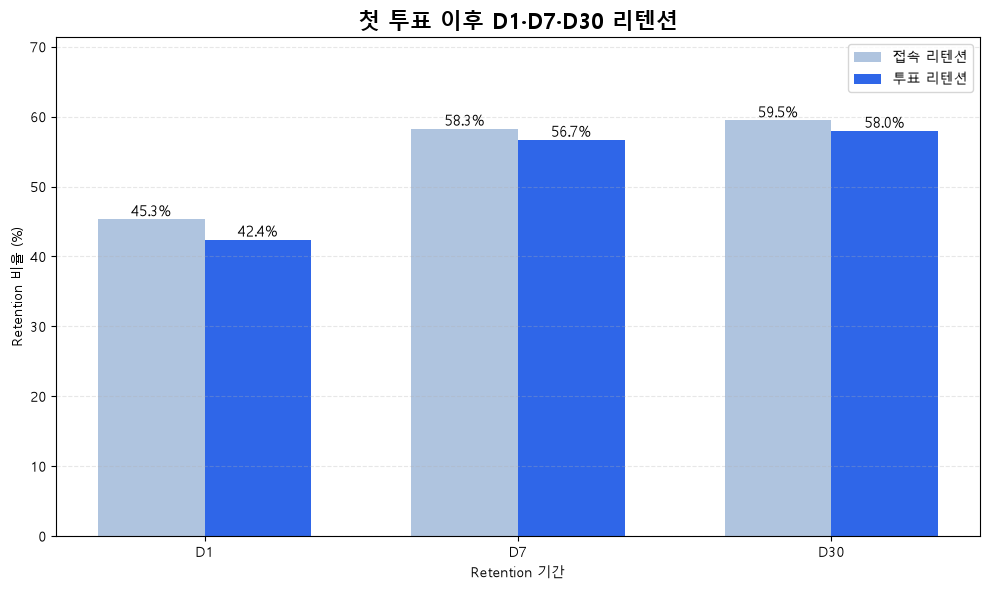

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

periods = df_retention["retention_period"]
login_rates = df_retention["login_retention_rate_percent"]
vote_rates = df_retention["vote_retention_rate_percent"]

x = np.arange(len(periods))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6))

login_bars = ax.bar(
    x - width / 2,
    login_rates,
    width,
    label="접속 리텐션",
    color="#AFC4DF"
)

vote_bars = ax.bar(
    x + width / 2,
    vote_rates,
    width,
    label="투표 리텐션",
    color="#2F66E8"
)

for bar, value in zip(login_bars, login_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value in zip(vote_bars, vote_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "첫 투표 이후 D1·D7·D30 리텐션",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Retention 기간")
ax.set_ylabel("Retention 비율 (%)")
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.set_ylim(
    0,
    max(login_rates.max(), vote_rates.max()) * 1.2
)

plt.tight_layout()
plt.show()

## W1·W4 주간 리텐션

같은 activation 기준으로, 관찰 구간을 1~7일(W1)·22~28일(W4)로 바꿔 그 구간 안에 재접속·재투표가 한 번이라도 있었는지를 본다.

In [32]:
# W1, W4
retention_w1_w4_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT
    'W1' AS retention_period,
    1 AS start_day,
    7 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT
    'W4',
    22,
    28,
    2
),

-- 탈퇴하지 않은 합성 데이터 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation을 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,
    f.first_vote_at,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 이후 재접속한 날짜
login_return_days AS (
  SELECT DISTINCT
    a.user_id,
    DATE(s.started_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = a.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > a.first_vote_date
),

-- 첫 투표 세션 이후 다른 세션에서 재투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    a.user_id,
    DATE(v.voted_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN actual_votes AS v
    ON v.user_id = a.user_id
  WHERE v.session_id != a.first_vote_session_id
    AND DATE(v.voted_at, 'Asia/Seoul') > a.first_vote_date
),

-- 각 기간을 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order
  FROM activated_users AS a
  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p
  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 사용자별 접속 리텐션 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,
    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained
  FROM eligible_users AS e
  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id
   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day
  GROUP BY
    e.user_id,
    e.retention_period
),

-- 사용자별 투표 리텐션 여부
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,
    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained
  FROM eligible_users AS e
  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id
   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day
  GROUP BY
    e.user_id,
    e.retention_period
)

SELECT
  e.retention_period,
  COUNT(*) AS eligible_user_count,

  COUNTIF(l.login_retained = 1)
    AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(l.login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(v.vote_retained = 1)
    AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM eligible_users AS e
JOIN login_flags AS l
  ON e.user_id = l.user_id
 AND e.retention_period = l.retention_period
JOIN vote_flags AS v
  ON e.user_id = v.user_id
 AND e.retention_period = v.retention_period

GROUP BY
  e.retention_period,
  e.sort_order

ORDER BY e.sort_order
"""

In [33]:
cost(retention_w1_w4_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [34]:
df_weekly_retention = bq.query(
    retention_w1_w4_sql
).to_dataframe()

display(df_weekly_retention)

,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,W1,14661,8542,58.26,8308,56.67
1,W4,14057,3011,21.42,2980,21.20


In [35]:
period_order = ["W1", "W4"]

formatted_weekly_df = (
    df_weekly_retention
    .set_index("retention_period")
    .reindex(period_order)
    .reset_index()
)

for _, row in formatted_weekly_df.iterrows():
    print(f"[{row['retention_period']}]")

    print(
        f"관찰 가능 사용자: "
        f"{int(row['eligible_user_count']):,}명"
    )

    print(
        f"접속 리텐션: "
        f"{int(row['login_retained_user_count']):,}명 "
        f"({float(row['login_retention_rate_percent']):.2f}%)"
    )

    print(
        f"투표 리텐션: "
        f"{int(row['vote_retained_user_count']):,}명 "
        f"({float(row['vote_retention_rate_percent']):.2f}%)"
    )

    print()

[W1]
관찰 가능 사용자: 14,661명
접속 리텐션: 8,542명 (58.26%)
투표 리텐션: 8,308명 (56.67%)

[W4]
관찰 가능 사용자: 14,057명
접속 리텐션: 3,011명 (21.42%)
투표 리텐션: 2,980명 (21.20%)



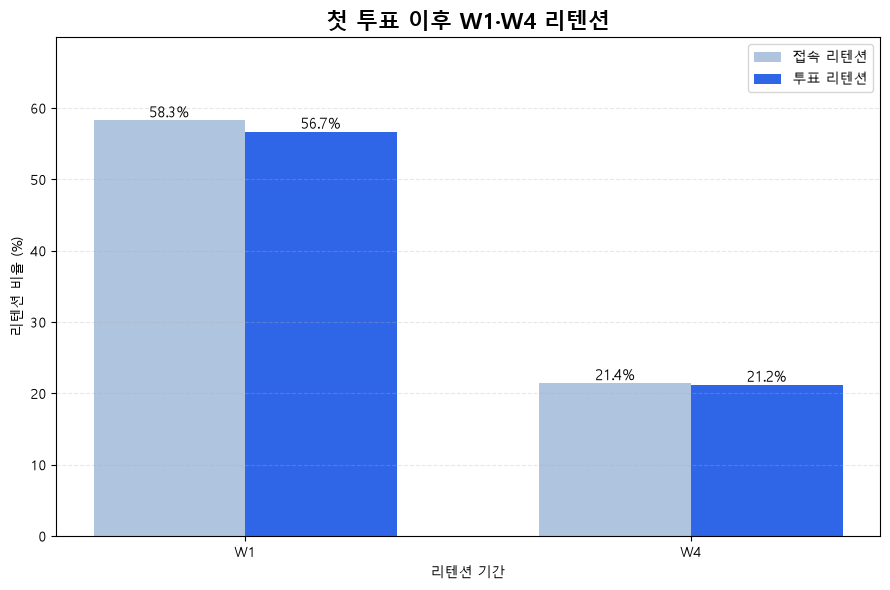

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

periods = df_weekly_retention["retention_period"]
login_rates = df_weekly_retention["login_retention_rate_percent"]
vote_rates = df_weekly_retention["vote_retention_rate_percent"]

x = np.arange(len(periods))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 6))

login_bars = ax.bar(
    x - width / 2,
    login_rates,
    width,
    label="접속 리텐션",
    color="#AFC4DF"
)

vote_bars = ax.bar(
    x + width / 2,
    vote_rates,
    width,
    label="투표 리텐션",
    color="#2F66E8"
)

for bar, value in zip(login_bars, login_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value in zip(vote_bars, vote_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "첫 투표 이후 W1·W4 리텐션",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("리텐션 기간")
ax.set_ylabel("리텐션 비율 (%)")
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

max_rate = max(login_rates.max(), vote_rates.max())
ax.set_ylim(0, max_rate * 1.2)

plt.tight_layout()
plt.show()

## 10문항 완료 여부에 따른 재방문율

10문항 완료/미완료 두 그룹의 W1·W4 접속·투표 재방문율을 비교한다.

In [37]:
# 투표 완료 사용자와 미완료 사용자의 재방문율
completion_revisit_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT
    'W1' AS retention_period,
    1 AS start_day,
    7 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT
    'W4',
    22,
    28,
    2
),

-- 탈퇴하지 않은 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.id AS vote_item_id,
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Activation 사용자
activated_users AS (
  SELECT
    u.user_id,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 실제 10문항을 완료한 세션
completed_sessions AS (
  SELECT
    vs.user_id,
    vs.id AS session_id
  FROM `ping-v2-503916.raw.vote_session` AS vs
  JOIN actual_votes AS v
    ON v.session_id = vs.id
   AND v.user_id = vs.user_id
  WHERE vs._source = 'local'
    AND vs._deleted_at IS NULL
    AND vs.status = 'COMPLETED'
    AND vs.completed_at IS NOT NULL
    AND vs.item_count = 10
  GROUP BY
    vs.user_id,
    vs.id
  HAVING COUNT(DISTINCT v.vote_item_id) >= 10
),

-- 사용자 단위 완료·미완료 구분
user_segments AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    a.first_vote_session_id,

    CASE
      WHEN c.user_id IS NOT NULL THEN '10문항 완료'
      ELSE '10문항 미완료'
    END AS completion_group

  FROM activated_users AS a

  LEFT JOIN (
    SELECT DISTINCT user_id
    FROM completed_sessions
  ) AS c
    ON a.user_id = c.user_id
),

-- 재접속 날짜
login_return_days AS (
  SELECT DISTINCT
    u.user_id,
    DATE(s.started_at, 'Asia/Seoul') AS activity_date
  FROM user_segments AS u
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = u.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > u.first_vote_date
),

-- 다른 투표 세션에서 재투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    u.user_id,
    DATE(v.voted_at, 'Asia/Seoul') AS activity_date
  FROM user_segments AS u
  JOIN actual_votes AS v
    ON v.user_id = u.user_id
  WHERE v.session_id != u.first_vote_session_id
    AND DATE(v.voted_at, 'Asia/Seoul') > u.first_vote_date
),

-- 각 구간을 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    u.user_id,
    u.first_vote_date,
    u.completion_group,
    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order
  FROM user_segments AS u
  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p
  WHERE u.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 사용자별 접속 재방문 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained

  FROM eligible_users AS e
  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id
   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
),

-- 사용자별 투표 재방문 여부
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained

  FROM eligible_users AS e
  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id
   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
)

SELECT
  e.retention_period,
  e.completion_group,

  COUNT(*) AS eligible_user_count,

  COUNTIF(l.login_retained = 1)
    AS login_return_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(l.login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_return_rate_percent,

  COUNTIF(v.vote_retained = 1)
    AS vote_return_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_return_rate_percent

FROM eligible_users AS e
JOIN login_flags AS l
  ON e.user_id = l.user_id
 AND e.retention_period = l.retention_period
JOIN vote_flags AS v
  ON e.user_id = v.user_id
 AND e.retention_period = v.retention_period

GROUP BY
  e.retention_period,
  e.completion_group,
  e.sort_order

ORDER BY
  e.sort_order,
  CASE e.completion_group
    WHEN '10문항 완료' THEN 1
    ELSE 2
  END
"""

In [38]:
cost(completion_revisit_sql)

예상 스캔량: 587.060 MiB
예상 스캔량: 0.573301 GiB
월 1 TiB 무료 용량의 약 0.05598641%


0.5733008729293942

In [39]:
df_completion_revisit = bq.query(
    completion_revisit_sql
).to_dataframe()

display(df_completion_revisit)

,retention_period,completion_group,eligible_user_count,login_return_user_count,login_return_rate_percent,vote_return_user_count,vote_return_rate_percent
0,W1,10문항 완료,10863,7851,72.27,7738,71.23
1,W1,10문항 미완료,3798,691,18.19,570,15.01
2,W4,10문항 완료,10454,3005,28.74,2975,28.46
3,W4,10문항 미완료,3603,6,0.17,5,0.14


In [40]:
period_order = ["W1", "W4"]
group_order = ["10문항 완료", "10문항 미완료"]

formatted_df = df_completion_revisit.copy()

formatted_df["period_order"] = (
    formatted_df["retention_period"]
    .map({period: index for index, period in enumerate(period_order)})
)

formatted_df["group_order"] = (
    formatted_df["completion_group"]
    .map({group: index for index, group in enumerate(group_order)})
)

formatted_df = formatted_df.sort_values(
    ["period_order", "group_order"]
)

for period in period_order:
    print(f"[{period}]")

    period_df = formatted_df[
        formatted_df["retention_period"] == period
    ]

    for _, row in period_df.iterrows():
        print(f"{row['completion_group']} 사용자")

        print(
            f"- 관찰 가능 사용자: "
            f"{int(row['eligible_user_count']):,}명"
        )

        print(
            f"- 접속 재방문: "
            f"{int(row['login_return_user_count']):,}명 "
            f"({float(row['login_return_rate_percent']):.2f}%)"
        )

        print(
            f"- 투표 재방문: "
            f"{int(row['vote_return_user_count']):,}명 "
            f"({float(row['vote_return_rate_percent']):.2f}%)"
        )

        print()

    print()

[W1]
10문항 완료 사용자
- 관찰 가능 사용자: 10,863명
- 접속 재방문: 7,851명 (72.27%)
- 투표 재방문: 7,738명 (71.23%)

10문항 미완료 사용자
- 관찰 가능 사용자: 3,798명
- 접속 재방문: 691명 (18.19%)
- 투표 재방문: 570명 (15.01%)


[W4]
10문항 완료 사용자
- 관찰 가능 사용자: 10,454명
- 접속 재방문: 3,005명 (28.74%)
- 투표 재방문: 2,975명 (28.46%)

10문항 미완료 사용자
- 관찰 가능 사용자: 3,603명
- 접속 재방문: 6명 (0.17%)
- 투표 재방문: 5명 (0.14%)




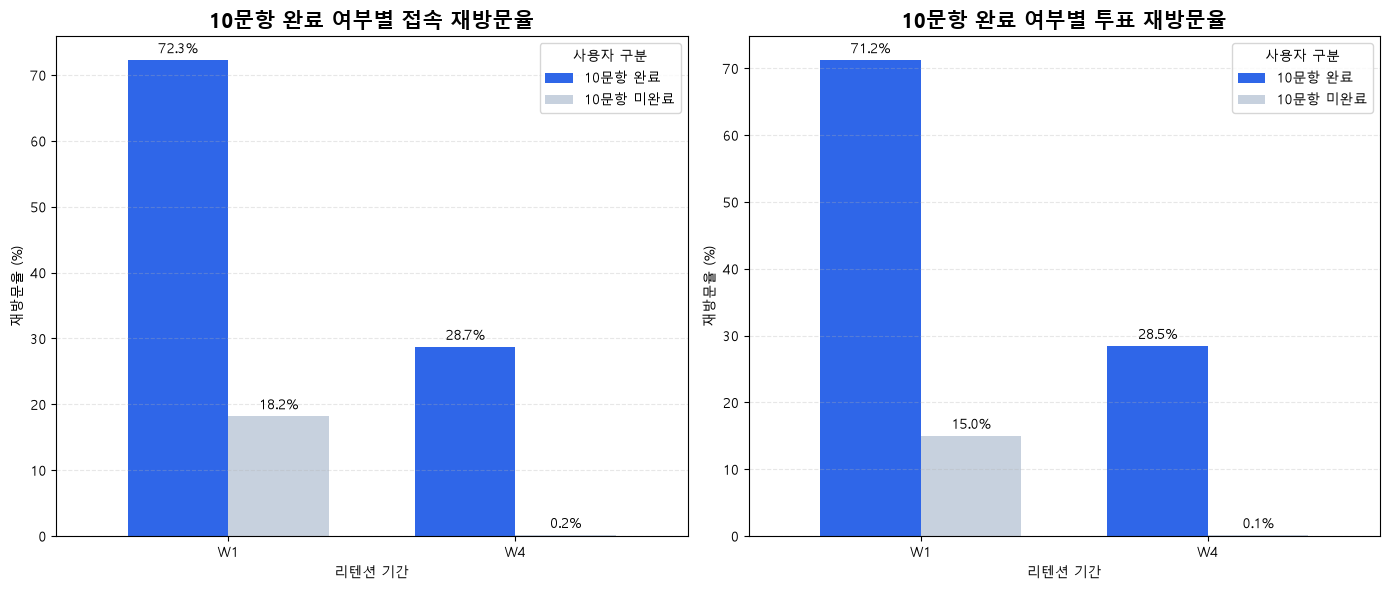

In [41]:
import matplotlib.pyplot as plt
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

period_order = ["W1", "W4"]
group_order = ["10문항 완료", "10문항 미완료"]

login_pivot = (
    df_completion_revisit
    .pivot(
        index="retention_period",
        columns="completion_group",
        values="login_return_rate_percent"
    )
    .reindex(index=period_order, columns=group_order)
)

vote_pivot = (
    df_completion_revisit
    .pivot(
        index="retention_period",
        columns="completion_group",
        values="vote_return_rate_percent"
    )
    .reindex(index=period_order, columns=group_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

login_pivot.plot(
    kind="bar",
    ax=axes[0],
    color=["#2F66E8", "#C7D1DE"],
    width=0.7
)

vote_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=["#2F66E8", "#C7D1DE"],
    width=0.7
)

titles = [
    "10문항 완료 여부별 접속 재방문율",
    "10문항 완료 여부별 투표 재방문율"
]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel("리텐션 기간")
    ax.set_ylabel("재방문율 (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(title="사용자 구분")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=10
        )

plt.tight_layout()
plt.show()

## 첫 투표 후 30일간 사용자당 활동 일수

첫 투표 후 30일을 전부 관찰할 수 있는 사용자에 대해, 30일간 접속일수(`login_active_days_30d`)와 재투표일수(`vote_active_days_30d`)를 세어 평균·중앙값·활동 0일 사용자 비율을 계산한다.

In [ ]:
# 사용자당 활동 일수
activity_days_30d_sql = """
WITH params AS (
  SELECT
    DATE '2026-07-23' AS data_end_date,
    30 AS observation_days
),

-- 탈퇴하지 않은 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation 충족 사용자
activated_users AS (
  SELECT
    u.user_id,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 이후 30일을 전부 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    a.first_vote_session_id
  FROM activated_users AS a
  CROSS JOIN params AS p
  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL p.observation_days DAY
       )
),

-- 사용자별 접속 활동 일수
login_activity AS (
  SELECT
    e.user_id,

    COUNT(
      DISTINCT DATE(s.started_at, 'Asia/Seoul')
    ) AS login_active_days_30d

  FROM eligible_users AS e
  LEFT JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = e.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
   AND s.started_at IS NOT NULL
   AND DATE_DIFF(
         DATE(s.started_at, 'Asia/Seoul'),
         e.first_vote_date,
         DAY
       ) BETWEEN 1 AND 30

  GROUP BY e.user_id
),

-- 사용자별 투표 활동 일수
vote_activity AS (
  SELECT
    e.user_id,

    COUNT(
      DISTINCT DATE(v.voted_at, 'Asia/Seoul')
    ) AS vote_active_days_30d

  FROM eligible_users AS e
  LEFT JOIN actual_votes AS v
    ON v.user_id = e.user_id

    -- 최초 투표 세션의 나머지 투표 제외
   AND v.session_id != e.first_vote_session_id

   AND DATE_DIFF(
         DATE(v.voted_at, 'Asia/Seoul'),
         e.first_vote_date,
         DAY
       ) BETWEEN 1 AND 30

  GROUP BY e.user_id
)

SELECT
  e.user_id,
  e.first_vote_date,

  COALESCE(
    l.login_active_days_30d,
    0
  ) AS login_active_days_30d,

  COALESCE(
    v.vote_active_days_30d,
    0
  ) AS vote_active_days_30d

FROM eligible_users AS e
LEFT JOIN login_activity AS l
  ON e.user_id = l.user_id
LEFT JOIN vote_activity AS v
  ON e.user_id = v.user_id

ORDER BY e.user_id
"""

In [43]:
cost(activity_days_30d_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [44]:
df_activity_days = bq.query(
    activity_days_30d_sql
).to_dataframe()

display(df_activity_days.head())

,user_id,first_vote_date,login_active_days_30d,vote_active_days_30d
0,1,2025-09-03,0,0
1,2,2025-09-01,29,27
2,3,2025-09-01,23,21
3,4,2025-09-01,23,21
4,5,2025-09-04,0,0


In [45]:
import pandas as pd

eligible_user_count = len(df_activity_days)

activity_summary = pd.DataFrame({
    "activity_type": [
        "접속 활동",
        "투표 활동"
    ],
    "average_active_days": [
        df_activity_days["login_active_days_30d"].mean(),
        df_activity_days["vote_active_days_30d"].mean()
    ],
    "median_active_days": [
        df_activity_days["login_active_days_30d"].median(),
        df_activity_days["vote_active_days_30d"].median()
    ],
    "zero_day_user_count": [
        (df_activity_days["login_active_days_30d"] == 0).sum(),
        (df_activity_days["vote_active_days_30d"] == 0).sum()
    ]
})

activity_summary["zero_day_user_rate_percent"] = (
    activity_summary["zero_day_user_count"]
    / eligible_user_count
    * 100
).round(2)

activity_summary["average_active_days"] = (
    activity_summary["average_active_days"].round(2)
)

activity_summary["median_active_days"] = (
    activity_summary["median_active_days"].round(2)
)

display(activity_summary)

,activity_type,average_active_days,median_active_days,zero_day_user_count,zero_day_user_rate_percent
0,접속 활동,6.90,1.0,5681,40.55
1,투표 활동,6.57,1.0,5890,42.04


In [46]:
print(f"30일 관찰 가능 사용자: {eligible_user_count:,}명")
print()

for _, row in activity_summary.iterrows():
    print(f"[{row['activity_type']}]")

    print(
        f"사용자당 평균 활동 일수: "
        f"{row['average_active_days']:.2f}일"
    )

    print(
        f"중앙값: "
        f"{row['median_active_days']:.2f}일"
    )

    print(
        f"활동 0일 사용자: "
        f"{int(row['zero_day_user_count']):,}명 "
        f"({row['zero_day_user_rate_percent']:.2f}%)"
    )

    print()

30일 관찰 가능 사용자: 14,010명

[접속 활동]
사용자당 평균 활동 일수: 6.90일
중앙값: 1.00일
활동 0일 사용자: 5,681명 (40.55%)

[투표 활동]
사용자당 평균 활동 일수: 6.57일
중앙값: 1.00일
활동 0일 사용자: 5,890명 (42.04%)



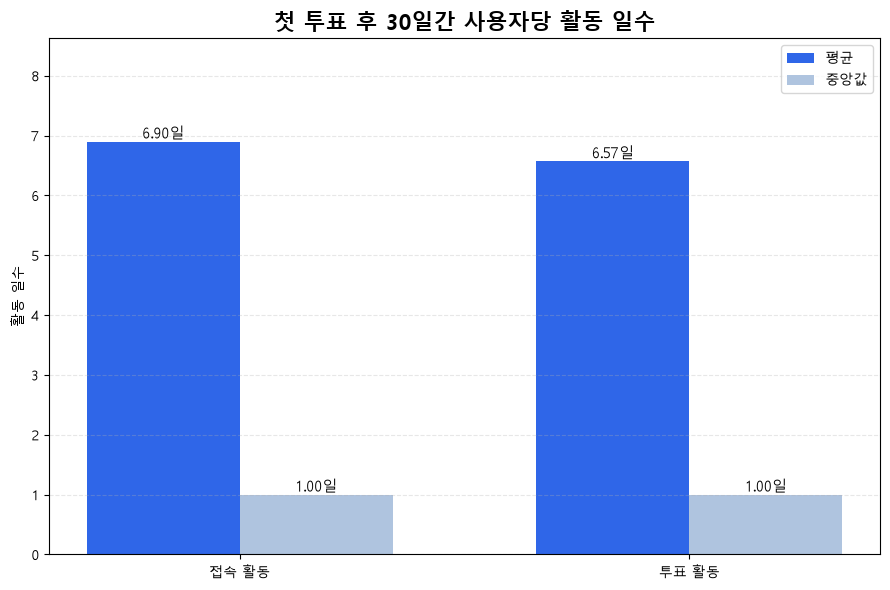

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

labels = activity_summary["activity_type"]
average_days = activity_summary["average_active_days"]
median_days = activity_summary["median_active_days"]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 6))

average_bars = ax.bar(
    x - width / 2,
    average_days,
    width,
    label="평균",
    color="#2F66E8"
)

median_bars = ax.bar(
    x + width / 2,
    median_days,
    width,
    label="중앙값",
    color="#AFC4DF"
)

for bar, value in zip(average_bars, average_days):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}일",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value in zip(median_bars, median_days):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}일",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "첫 투표 후 30일간 사용자당 활동 일수",
    fontsize=16,
    fontweight="bold"
)
ax.set_ylabel("활동 일수")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

max_value = max(average_days.max(), median_days.max())
ax.set_ylim(0, max_value * 1.25 if max_value > 0 else 1)

plt.tight_layout()
plt.show()

## 30일 이상 장기 미활동 후 복귀율

첫 투표일을 포함한 활동일(접속일 또는 재투표일)을 사용자별로 다음 활동일까지의 간격을 구한다. 

그 간격이 31일 이상 벌어졌다가 다시 활동한 경우를 '복귀'로, 마지막 활동 후 데이터 종료일까지 30일 이상 흐른 경우까지 포함해 '장기 미활동'으로 잡는다. 접속 기준·투표 기준 두 지표를 따로 집계한다.

In [48]:
# 장기 미접속
long_inactive_return_sql = """
WITH params AS (
  SELECT
    DATE '2026-07-23' AS data_end_date,
    30 AS inactivity_days
),

-- 탈퇴하지 않은 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation 충족 사용자
activated_users AS (
  SELECT
    u.user_id,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 접속 활동일
access_activity_days AS (
  -- 첫 투표일을 최초 앱 활동일로 설정
  SELECT
    '접속 기준' AS metric_type,
    user_id,
    first_vote_date AS activity_date
  FROM activated_users

  UNION DISTINCT

  SELECT
    '접속 기준' AS metric_type,
    a.user_id,
    DATE(s.started_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = a.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > a.first_vote_date
),

-- 투표 활동일
vote_activity_days AS (
  -- 최초 투표일
  SELECT
    '투표 기준' AS metric_type,
    user_id,
    first_vote_date AS activity_date
  FROM activated_users

  UNION DISTINCT

  -- 최초 투표 세션이 아닌 다른 세션의 투표
  SELECT
    '투표 기준' AS metric_type,
    a.user_id,
    DATE(v.voted_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN actual_votes AS v
    ON v.user_id = a.user_id
  WHERE v.session_id != a.first_vote_session_id
    AND DATE(v.voted_at, 'Asia/Seoul') > a.first_vote_date
),

all_activity_days AS (
  SELECT * FROM access_activity_days

  UNION ALL

  SELECT * FROM vote_activity_days
),

-- 활동일 다음에 언제 다시 활동했는지 확인
ordered_activity AS (
  SELECT
    metric_type,
    user_id,
    activity_date,

    LEAD(activity_date) OVER (
      PARTITION BY metric_type, user_id
      ORDER BY activity_date
    ) AS next_activity_date

  FROM all_activity_days
),

-- 장기 미활동 및 복귀 여부 판정
episode_flags AS (
  SELECT
    o.metric_type,
    o.user_id,

    -- 장기 미활동 경험 여부
    CASE
      -- 30일 연속 활동하지 않은 후 복귀
      WHEN o.next_activity_date IS NOT NULL
       AND DATE_DIFF(
             o.next_activity_date,
             o.activity_date,
             DAY
           ) >= p.inactivity_days + 1
      THEN 1

      -- 데이터 종료일까지 30일 이상 미활동
      WHEN o.next_activity_date IS NULL
       AND DATE_DIFF(
             p.data_end_date,
             o.activity_date,
             DAY
           ) >= p.inactivity_days
      THEN 1

      ELSE 0
    END AS has_long_inactive_episode,

    -- 장기 미활동 후 실제 복귀 여부
    CASE
      WHEN o.next_activity_date IS NOT NULL
       AND DATE_DIFF(
             o.next_activity_date,
             o.activity_date,
             DAY
           ) >= p.inactivity_days + 1
      THEN 1
      ELSE 0
    END AS has_returned_episode

  FROM ordered_activity AS o
  CROSS JOIN params AS p
),

-- 사용자 단위 집계
user_summary AS (
  SELECT
    metric_type,
    user_id,

    MAX(
      has_long_inactive_episode
    ) AS is_long_inactive_user,

    MAX(
      has_returned_episode
    ) AS is_returned_user

  FROM episode_flags
  GROUP BY
    metric_type,
    user_id
)

SELECT
  metric_type,

  COUNT(*) AS activated_user_count,

  COUNTIF(
    is_long_inactive_user = 1
  ) AS long_inactive_user_count,

  COUNTIF(
    is_returned_user = 1
  ) AS returned_user_count,

  COUNTIF(
    is_long_inactive_user = 1
  )
  -
  COUNTIF(
    is_returned_user = 1
  ) AS not_returned_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(is_returned_user = 1),
      COUNTIF(is_long_inactive_user = 1)
    ) * 100,
    2
  ) AS return_rate_percent

FROM user_summary
GROUP BY metric_type

ORDER BY
  CASE metric_type
    WHEN '접속 기준' THEN 1
    WHEN '투표 기준' THEN 2
  END
"""

In [49]:
cost(long_inactive_return_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [50]:
df_long_return = bq.query(
    long_inactive_return_sql
).to_dataframe()

display(df_long_return)

,metric_type,activated_user_count,long_inactive_user_count,returned_user_count,not_returned_user_count,return_rate_percent
0,접속 기준,14889,13320,655,12665,4.92
1,투표 기준,14889,13322,656,12666,4.92


In [51]:
metric_order = ["접속 기준", "투표 기준"]

formatted_long_return = (
    df_long_return
    .set_index("metric_type")
    .reindex(metric_order)
    .reset_index()
)

for _, row in formatted_long_return.iterrows():
    print(f"[{row['metric_type']}]")

    print(
        f"장기 미활동 사용자: "
        f"{int(row['long_inactive_user_count']):,}명"
    )

    print(
        f"복귀 사용자: "
        f"{int(row['returned_user_count']):,}명"
    )

    print(
        f"미복귀 사용자: "
        f"{int(row['not_returned_user_count']):,}명"
    )

    print(
        f"복귀율: "
        f"{float(row['return_rate_percent']):.2f}%"
    )

    print()

[접속 기준]
장기 미활동 사용자: 13,320명
복귀 사용자: 655명
미복귀 사용자: 12,665명
복귀율: 4.92%

[투표 기준]
장기 미활동 사용자: 13,322명
복귀 사용자: 656명
미복귀 사용자: 12,666명
복귀율: 4.92%



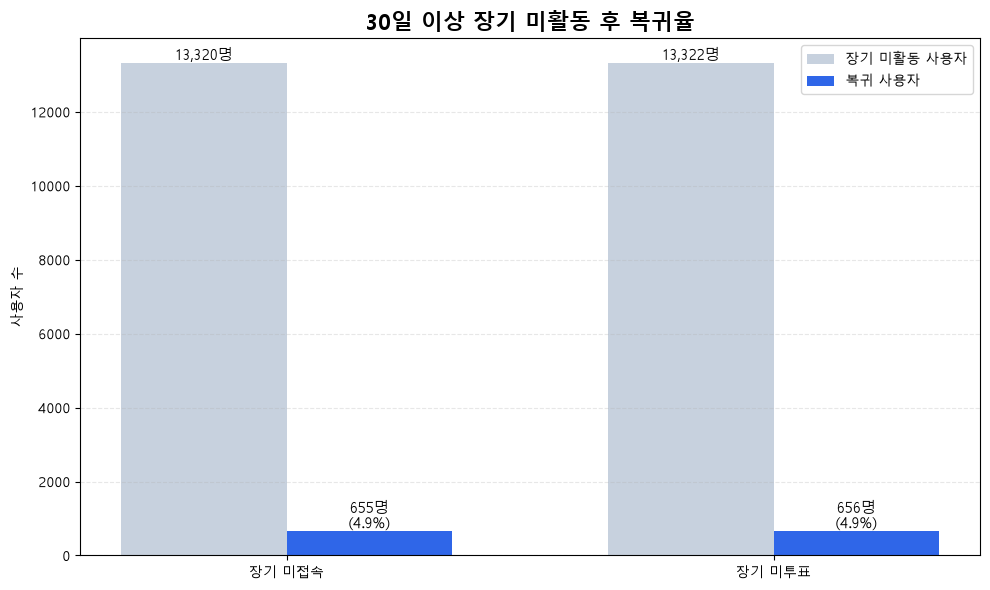

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

labels = df_long_return["metric_type"].replace({
    "접속 기준": "장기 미접속",
    "투표 기준": "장기 미투표"
})

inactive_counts = df_long_return["long_inactive_user_count"]
returned_counts = df_long_return["returned_user_count"]
return_rates = df_long_return["return_rate_percent"]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6))

inactive_bars = ax.bar(
    x - width / 2,
    inactive_counts,
    width,
    label="장기 미활동 사용자",
    color="#C7D1DE"
)

returned_bars = ax.bar(
    x + width / 2,
    returned_counts,
    width,
    label="복귀 사용자",
    color="#2F66E8"
)

for bar, value in zip(inactive_bars, inactive_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}명",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value, rate in zip(
    returned_bars,
    returned_counts,
    return_rates
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}명\n({rate:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "30일 이상 장기 미활동 후 복귀율",
    fontsize=16,
    fontweight="bold"
)
ax.set_ylabel("사용자 수")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

쿼리에서 변환되지 않은 학교 유형 값과 시각화에서 지정한 중학교·고등학교가 서로 맞지 않아, reindex() 과정에서 값이 전부 결측치가 된 것

## 학교 유형별 리텐션 — 결측치 원인 확인과 재계산

`school_type` 원본 값이 그래프에서 기대한 '중학교'·'고등학교' 표기와 어긋나 있었다. 

이어지는 셀은 그 값을 확인하고, `school_type`이 `'M'`/`'MIDDLE'`류·`'H'`/`'HIGH'`류인 경우를 각각 '중학교'·'고등학교'로 정규화하는 CASE 문으로 쿼리를 

다시 작성해 D1·D7·D30 리텐션을 집계한 뒤, 정규화된 이름으로 학교 유형별 막대그래프를 다시 그린다.

In [ ]:
# 1. 실제 학교 유형 값 확인
display(df_school_type_retention)

print(
    df_school_type_retention["school_type_name"]
    .drop_duplicates()
    .tolist()
)

,school_type_name,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,HIGH,D1,8487,3903,45.99,3656,43.08
1,MIDDLE,D1,6356,2822,44.40,2637,41.49
2,HIGH,D7,8392,4939,58.85,4801,57.21
3,MIDDLE,D7,6269,3603,57.47,3507,55.94
4,HIGH,D30,8017,4821,60.13,4698,58.60
5,MIDDLE,D30,5993,3508,58.53,3422,57.10


['HIGH', 'MIDDLE']


In [90]:
# 2. 수정된 학교 유형별 쿼리
school_type_retention_sql = retention_common_ctes + """
SELECT
  CASE
    WHEN school_type = 'M'
      OR UPPER(school_type) LIKE '%MIDDLE%'
    THEN '중학교'

    WHEN school_type = 'H'
      OR UPPER(school_type) LIKE '%HIGH%'
    THEN '고등학교'

    ELSE school_type
  END AS school_type_name,

  retention_period,

  COUNT(*) AS eligible_user_count,

  COUNTIF(
    login_retained = 1
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(
    vote_retained = 1
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM retention_user_flags

GROUP BY
  school_type,
  retention_period,
  sort_order

ORDER BY
  sort_order,
  school_type_name
"""

In [91]:
cost(school_type_retention_sql)

예상 스캔량: 416.145 MiB
예상 스캔량: 0.406392 GiB
월 1 TiB 무료 용량의 약 0.03968669%


0.40639173332601786

In [92]:
df_school_type_retention = bq.query(
    school_type_retention_sql
).to_dataframe()

display(df_school_type_retention)

,school_type_name,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,고등학교,D1,8487,3903,45.99,3656,43.08
1,중학교,D1,6356,2822,44.40,2637,41.49
2,고등학교,D7,8392,4939,58.85,4801,57.21
3,중학교,D7,6269,3603,57.47,3507,55.94
4,고등학교,D30,8017,4821,60.13,4698,58.60
5,중학교,D30,5993,3508,58.53,3422,57.10


[접속 리텐션 시각화 데이터]


retention_period,D1,D7,D30
school_type_name,,,
중학교,44.40,57.47,58.53
고등학교,45.99,58.85,60.13


[투표 리텐션 시각화 데이터]


retention_period,D1,D7,D30
school_type_name,,,
중학교,41.49,55.94,57.1
고등학교,43.08,57.21,58.6


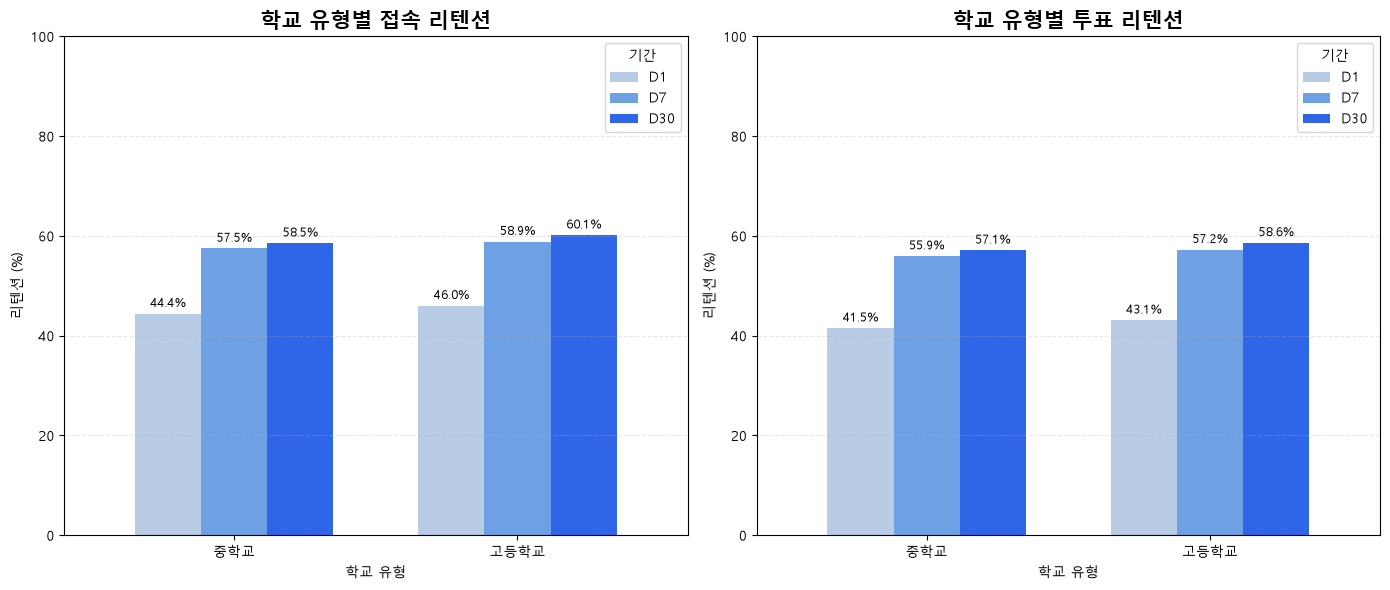

In [93]:
# 3. 수정한 시각화
import pandas as pd
import matplotlib.pyplot as plt
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_df = df_school_type_retention.copy()

# 리텐션 컬럼을 확실하게 숫자형으로 변환
rate_columns = [
    "login_retention_rate_percent",
    "vote_retention_rate_percent"
]

for column in rate_columns:
    plot_df[column] = pd.to_numeric(
        plot_df[column],
        errors="coerce"
    )

period_order = ["D1", "D7", "D30"]
school_type_order = ["중학교", "고등학교"]

login_pivot = (
    plot_df
    .pivot(
        index="school_type_name",
        columns="retention_period",
        values="login_retention_rate_percent"
    )
    .reindex(
        index=school_type_order,
        columns=period_order
    )
)

vote_pivot = (
    plot_df
    .pivot(
        index="school_type_name",
        columns="retention_period",
        values="vote_retention_rate_percent"
    )
    .reindex(
        index=school_type_order,
        columns=period_order
    )
)

print("[접속 리텐션 시각화 데이터]")
display(login_pivot)

print("[투표 리텐션 시각화 데이터]")
display(vote_pivot)

# 데이터가 모두 비어 있으면 그래프를 그리지 않고 오류 표시
if login_pivot.isna().all().all():
    raise ValueError(
        "접속 리텐션 데이터가 모두 비어 있습니다. "
        "school_type_name 값을 확인해주세요."
    )

if vote_pivot.isna().all().all():
    raise ValueError(
        "투표 리텐션 데이터가 모두 비어 있습니다. "
        "school_type_name 값을 확인해주세요."
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

login_pivot.plot(
    kind="bar",
    ax=axes[0],
    color=["#B9CCE5", "#6EA1E4", "#2F66E8"],
    width=0.7
)

vote_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=["#B9CCE5", "#6EA1E4", "#2F66E8"],
    width=0.7
)

for ax, title in zip(
    axes,
    [
        "학교 유형별 접속 리텐션",
        "학교 유형별 투표 리텐션"
    ]
):
    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold"
    )
    ax.set_xlabel("학교 유형")
    ax.set_ylabel("리텐션 (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(title="기간")

    for container in ax.containers:
        labels = [
            f"{bar.get_height():.1f}%"
            if pd.notna(bar.get_height())
            else ""
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()

## 학교 유형·학년별 리텐션

`grade_class`·`school`을 조인해 사용자별 학교 유형과 학년을 붙이고, 친구 5명을 확보했고 학교 유형이 중·고등학교이며 학년이 1~3인 사용자만 대상으로 

D1·D7·D30 접속·투표 리텐션을 학교 유형×학년 조합별로 집계해 그래프로 그린다.

In [2]:
# 학년별
school_grade_retention_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT
    'D1' AS retention_period,
    1 AS start_day,
    1 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT
    'D7',
    1,
    7,
    2

  UNION ALL

  SELECT
    'D30',
    1,
    30,
    3
),

-- 1. 탈퇴하지 않은 합성 데이터 사용자와 학교·학년 정보
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at,

    CASE
      WHEN UPPER(CAST(s.school_type AS STRING))
        IN ('M', 'MIDDLE', 'MIDDLE_SCHOOL')
      THEN '중학교'

      WHEN UPPER(CAST(s.school_type AS STRING))
        IN ('H', 'HIGH', 'HIGH_SCHOOL')
      THEN '고등학교'

      ELSE CAST(s.school_type AS STRING)
    END AS school_type_name,

    gc.grade

  FROM `ping-v2-503916.raw.app_user` AS u

  JOIN `ping-v2-503916.raw.grade_class` AS gc
    ON gc._source = u._source
   AND gc.id = u.class_id
   AND gc._deleted_at IS NULL

  JOIN `ping-v2-503916.raw.school` AS s
    ON s._source = gc._source
   AND s.id = gc.school_id
   AND s._deleted_at IS NULL

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

-- 2. 실제로 완료한 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at

  FROM `ping-v2-503916.raw.vote_item` AS vi

  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 3. 사용자별 최초 실제 투표 시점과 해당 세션
first_vote AS (
  SELECT
    user_id,

    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY
        voted_at,
        session_id
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes

  GROUP BY user_id
),

-- 4. Acquisition과 Activation을 모두 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,
    u.school_type_name,
    u.grade,

    DATE(
      f.first_vote_at,
      'Asia/Seoul'
    ) AS first_vote_date,

    f.first_vote_session_id

  FROM valid_users AS u

  JOIN first_vote AS f
    ON f.user_id = u.user_id

  -- 친구 5명 확보 조건
  WHERE u.service_unlocked_at IS NOT NULL
    AND u.school_type_name IN ('중학교', '고등학교')
    AND u.grade IN (1, 2, 3)
),

-- 5. 첫 투표 이후 다시 접속한 날짜
login_return_days AS (
  SELECT DISTINCT
    a.user_id,

    DATE(
      us.started_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM activated_users AS a

  JOIN `ping-v2-503916.raw.user_session` AS us
    ON us._source = 'local'
   AND us.user_id = a.user_id
   AND us._deleted_at IS NULL

  WHERE us.started_at IS NOT NULL

    -- 첫 투표 당일 제외
    AND DATE(
          us.started_at,
          'Asia/Seoul'
        ) > a.first_vote_date
),

-- 6. 최초 투표 세션이 아닌 다른 세션에서 재투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    a.user_id,

    DATE(
      v.voted_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM activated_users AS a

  JOIN actual_votes AS v
    ON v.user_id = a.user_id

  WHERE v.session_id != a.first_vote_session_id

    -- 첫 투표 당일 제외
    AND DATE(
          v.voted_at,
          'Asia/Seoul'
        ) > a.first_vote_date
),

-- 7. 기간을 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.school_type_name,
    a.grade,
    a.first_vote_date,

    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order

  FROM activated_users AS a

  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p

  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 8. 사용자별 접속 리텐션 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained

  FROM eligible_users AS e

  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id

   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
),

-- 9. 사용자별 투표 리텐션 여부
-- 힌트 구매는 포함하지 않음
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained

  FROM eligible_users AS e

  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id

   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
)

-- 10. 학교 유형·학년·기간별 집계
SELECT
  e.school_type_name,
  e.grade,
  e.retention_period,

  COUNT(*) AS eligible_user_count,

  COUNTIF(
    l.login_retained = 1
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(l.login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(
    v.vote_retained = 1
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM eligible_users AS e

JOIN login_flags AS l
  ON l.user_id = e.user_id
 AND l.retention_period = e.retention_period

JOIN vote_flags AS v
  ON v.user_id = e.user_id
 AND v.retention_period = e.retention_period

GROUP BY
  e.school_type_name,
  e.grade,
  e.retention_period,
  e.sort_order

ORDER BY
  e.sort_order,

  CASE e.school_type_name
    WHEN '중학교' THEN 1
    WHEN '고등학교' THEN 2
    ELSE 3
  END,

  e.grade
"""

In [3]:
cost(school_grade_retention_sql)

예상 스캔량: 416.156 MiB
예상 스캔량: 0.406402 GiB
월 1 TiB 무료 용량의 약 0.03968769%


0.40640195552259684

In [4]:
df_school_grade_retention = bq.query(
    school_grade_retention_sql
).to_dataframe()

display(df_school_grade_retention)

,school_type_name,grade,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,중학교,1,D1,2118,940,44.38,884,41.74
1,중학교,2,D1,2094,912,43.55,845,40.35
2,중학교,3,D1,2144,970,45.24,908,42.35
3,고등학교,1,D1,2854,1281,44.88,1210,42.40
4,고등학교,2,D1,2835,1320,46.56,1237,43.63
5,고등학교,3,D1,2798,1302,46.53,1209,43.21
6,중학교,1,D7,2098,1192,56.82,1165,55.53
7,중학교,2,D7,2061,1174,56.96,1138,55.22
8,중학교,3,D7,2110,1237,58.63,1204,57.06
9,고등학교,1,D7,2826,1642,58.10,1601,56.65


In [5]:
import pandas as pd

result_df = df_school_grade_retention.copy()

# BigQuery 숫자 자료형을 출력하기 편하게 변환
numeric_columns = [
    "grade",
    "eligible_user_count",
    "login_retained_user_count",
    "login_retention_rate_percent",
    "vote_retained_user_count",
    "vote_retention_rate_percent"
]

for column in numeric_columns:
    result_df[column] = pd.to_numeric(
        result_df[column],
        errors="coerce"
    )

school_type_order = [
    "중학교",
    "고등학교"
]

period_order = [
    "D1",
    "D7",
    "D30"
]

result_df["school_type_order"] = (
    result_df["school_type_name"]
    .map({
        "중학교": 1,
        "고등학교": 2
    })
)

result_df["period_order"] = (
    result_df["retention_period"]
    .map({
        "D1": 1,
        "D7": 2,
        "D30": 3
    })
)

result_df = result_df.sort_values(
    [
        "school_type_order",
        "grade",
        "period_order"
    ]
)

for school_type in school_type_order:
    print(f"[{school_type}]")
    print()

    type_df = result_df[
        result_df["school_type_name"] == school_type
    ]

    for grade in [1, 2, 3]:
        print(f"{grade}학년")

        grade_df = type_df[
            type_df["grade"] == grade
        ]

        for _, row in grade_df.iterrows():
            print(
                f"- {row['retention_period']} "
                f"관찰 가능 사용자: "
                f"{int(row['eligible_user_count']):,}명"
            )

            print(
                f"  접속 리텐션: "
                f"{int(row['login_retained_user_count']):,}명 "
                f"({float(row['login_retention_rate_percent']):.2f}%)"
            )

            print(
                f"  투표 리텐션: "
                f"{int(row['vote_retained_user_count']):,}명 "
                f"({float(row['vote_retention_rate_percent']):.2f}%)"
            )

        print()

    print()

[중학교]

1학년
- D1 관찰 가능 사용자: 2,118명
  접속 리텐션: 940명 (44.38%)
  투표 리텐션: 884명 (41.74%)
- D7 관찰 가능 사용자: 2,098명
  접속 리텐션: 1,192명 (56.82%)
  투표 리텐션: 1,165명 (55.53%)
- D30 관찰 가능 사용자: 2,016명
  접속 리텐션: 1,164명 (57.74%)
  투표 리텐션: 1,139명 (56.50%)

2학년
- D1 관찰 가능 사용자: 2,094명
  접속 리텐션: 912명 (43.55%)
  투표 리텐션: 845명 (40.35%)
- D7 관찰 가능 사용자: 2,061명
  접속 리텐션: 1,174명 (56.96%)
  투표 리텐션: 1,138명 (55.22%)
- D30 관찰 가능 사용자: 1,970명
  접속 리텐션: 1,140명 (57.87%)
  투표 리텐션: 1,107명 (56.19%)

3학년
- D1 관찰 가능 사용자: 2,144명
  접속 리텐션: 970명 (45.24%)
  투표 리텐션: 908명 (42.35%)
- D7 관찰 가능 사용자: 2,110명
  접속 리텐션: 1,237명 (58.63%)
  투표 리텐션: 1,204명 (57.06%)
- D30 관찰 가능 사용자: 2,007명
  접속 리텐션: 1,204명 (59.99%)
  투표 리텐션: 1,176명 (58.59%)


[고등학교]

1학년
- D1 관찰 가능 사용자: 2,854명
  접속 리텐션: 1,281명 (44.88%)
  투표 리텐션: 1,210명 (42.40%)
- D7 관찰 가능 사용자: 2,826명
  접속 리텐션: 1,642명 (58.10%)
  투표 리텐션: 1,601명 (56.65%)
- D30 관찰 가능 사용자: 2,698명
  접속 리텐션: 1,596명 (59.15%)
  투표 리텐션: 1,560명 (57.82%)

2학년
- D1 관찰 가능 사용자: 2,835명
  접속 리텐션: 1,320명 (46.56%)
  투표 리텐션: 1,237명 (4

[접속 리텐션 시각화 데이터]


retention_period,D1,D7,D30
school_grade,,,
중학교 1학년,44.38,56.82,57.74
중학교 2학년,43.55,56.96,57.87
중학교 3학년,45.24,58.63,59.99
고등학교 1학년,44.88,58.10,59.15
고등학교 2학년,46.56,59.79,61.22
고등학교 3학년,46.53,58.67,60.04


[투표 리텐션 시각화 데이터]


retention_period,D1,D7,D30
school_grade,,,
중학교 1학년,41.74,55.53,56.50
중학교 2학년,40.35,55.22,56.19
중학교 3학년,42.35,57.06,58.59
고등학교 1학년,42.40,56.65,57.82
고등학교 2학년,43.63,58.18,59.76
고등학교 3학년,43.21,56.79,58.23


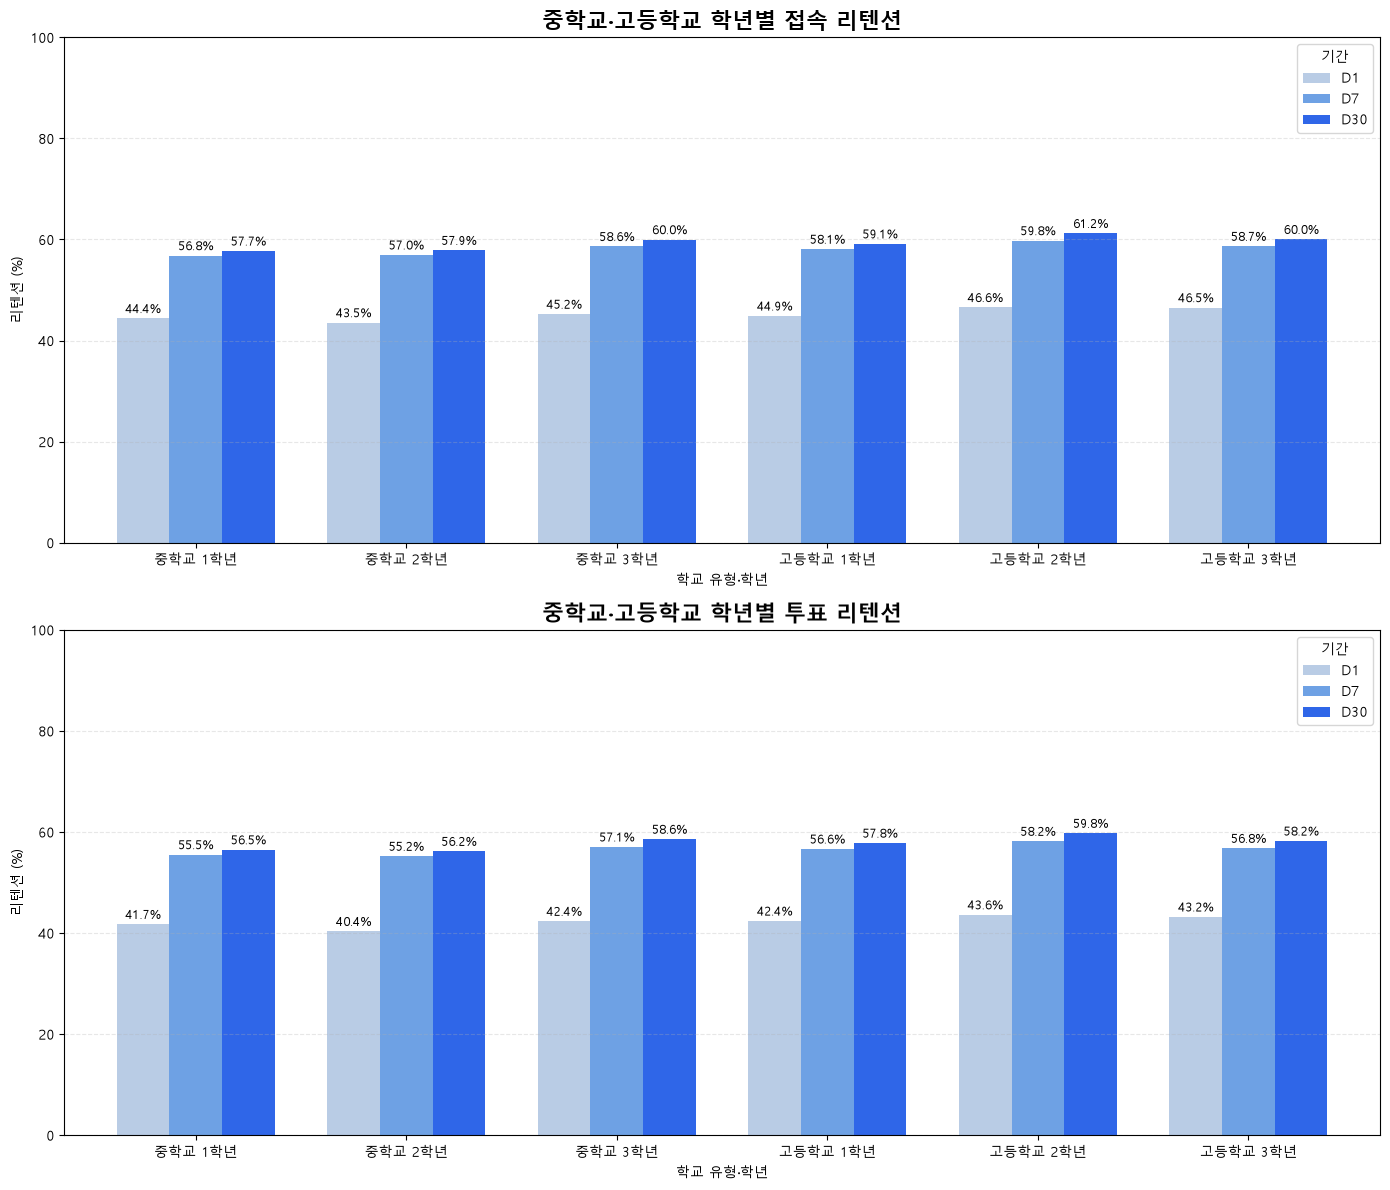

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

# Windows·Mac 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_df = df_school_grade_retention.copy()

# 숫자형 변환
plot_df["grade"] = pd.to_numeric(
    plot_df["grade"],
    errors="coerce"
)

rate_columns = [
    "login_retention_rate_percent",
    "vote_retention_rate_percent"
]

for column in rate_columns:
    plot_df[column] = pd.to_numeric(
        plot_df[column],
        errors="coerce"
    )

# 그래프에 사용할 학교 유형·학년 표시명
plot_df["school_grade"] = (
    plot_df["school_type_name"]
    + " "
    + plot_df["grade"].astype("Int64").astype(str)
    + "학년"
)

school_grade_order = [
    "중학교 1학년",
    "중학교 2학년",
    "중학교 3학년",
    "고등학교 1학년",
    "고등학교 2학년",
    "고등학교 3학년"
]

period_order = [
    "D1",
    "D7",
    "D30"
]

# 접속 리텐션 피벗
login_pivot = (
    plot_df
    .pivot(
        index="school_grade",
        columns="retention_period",
        values="login_retention_rate_percent"
    )
    .reindex(
        index=school_grade_order,
        columns=period_order
    )
)

# 투표 리텐션 피벗
vote_pivot = (
    plot_df
    .pivot(
        index="school_grade",
        columns="retention_period",
        values="vote_retention_rate_percent"
    )
    .reindex(
        index=school_grade_order,
        columns=period_order
    )
)

# 그래프를 그리기 전에 실제 피벗 데이터 확인
print("[접속 리텐션 시각화 데이터]")
display(login_pivot)

print("[투표 리텐션 시각화 데이터]")
display(vote_pivot)

if login_pivot.isna().all().all():
    raise ValueError(
        "접속 리텐션 데이터가 모두 비어 있습니다. "
        "학교 유형과 학년 값을 확인해주세요."
    )

if vote_pivot.isna().all().all():
    raise ValueError(
        "투표 리텐션 데이터가 모두 비어 있습니다. "
        "학교 유형과 학년 값을 확인해주세요."
    )

colors = [
    "#B9CCE5",
    "#6EA1E4",
    "#2F66E8"
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 12)
)

# 접속 리텐션
login_pivot.plot(
    kind="bar",
    ax=axes[0],
    color=colors,
    width=0.75
)

# 투표 리텐션
vote_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=colors,
    width=0.75
)

titles = [
    "중학교·고등학교 학년별 접속 리텐션",
    "중학교·고등학교 학년별 투표 리텐션"
]

for ax, title in zip(axes, titles):
    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold"
    )

    ax.set_xlabel("학교 유형·학년")
    ax.set_ylabel("리텐션 (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(
        axis="x",
        rotation=0
    )
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )
    ax.legend(
        title="기간"
    )

    # 막대 위 퍼센트 표시
    for container in ax.containers:
        labels = []

        for bar in container:
            height = bar.get_height()

            if pd.notna(height):
                labels.append(
                    f"{height:.1f}%"
                )
            else:
                labels.append("")

        ax.bar_label(
            container,
            labels=labels,
            padding=2,
            fontsize=9
        )

plt.tight_layout()
plt.show()

## 주차별 레인지 리텐션 (W1~W4)

첫 투표 이후를 1~7일(W1)·8~14일(W2)·15~21일(W3)·22~28일(W4)로 서로 겹치지 않게 나눠, 각 구간 안에 재접속·재투표가 있었는지를 구간별 리텐션율로 계산하고 꺾은선 그래프로 그린다.

In [7]:
# 레인지 리텐션
weekly_range_retention_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

-- 서로 겹치지 않는 주차별 레인지
retention_windows AS (
  SELECT
    'W1' AS retention_period,
    1 AS start_day,
    7 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT
    'W2',
    8,
    14,
    2

  UNION ALL

  SELECT
    'W3',
    15,
    21,
    3

  UNION ALL

  SELECT
    'W4',
    22,
    28,
    4
),

-- 탈퇴하지 않은 합성 데이터 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 유효한 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1

      FROM `ping-v2-503916.raw.user_withdrawal` AS w

      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

-- 실제 투표를 완료한 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at

  FROM `ping-v2-503916.raw.vote_item` AS vi

  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표 시점과 해당 투표 세션
first_vote AS (
  SELECT
    user_id,

    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY
        voted_at,
        session_id
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes

  GROUP BY user_id
),

-- Acquisition과 Activation을 모두 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,

    DATE(
      f.first_vote_at,
      'Asia/Seoul'
    ) AS first_vote_date,

    f.first_vote_session_id

  FROM valid_users AS u

  JOIN first_vote AS f
    ON f.user_id = u.user_id

  -- 친구 5명 확보
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 이후 다시 접속한 날짜
login_return_days AS (
  SELECT DISTINCT
    a.user_id,

    DATE(
      us.started_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM activated_users AS a

  JOIN `ping-v2-503916.raw.user_session` AS us
    ON us._source = 'local'
   AND us.user_id = a.user_id
   AND us._deleted_at IS NULL

  WHERE us.started_at IS NOT NULL

    -- 첫 투표 당일 제외
    AND DATE(
          us.started_at,
          'Asia/Seoul'
        ) > a.first_vote_date
),

-- 첫 투표와 다른 세션에서 다시 투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    a.user_id,

    DATE(
      v.voted_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM activated_users AS a

  JOIN actual_votes AS v
    ON v.user_id = a.user_id

  -- 최초 투표 세션의 나머지 투표는 재투표에서 제외
  WHERE v.session_id != a.first_vote_session_id

    -- 첫 투표 당일 제외
    AND DATE(
          v.voted_at,
          'Asia/Seoul'
        ) > a.first_vote_date
),

-- 각 주차를 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.first_vote_date,

    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order

  FROM activated_users AS a

  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p

  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 사용자별 주차 접속 리텐션 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained

  FROM eligible_users AS e

  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id

   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
),

-- 사용자별 주차 투표 리텐션 여부
-- 힌트 구매는 포함하지 않음
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained

  FROM eligible_users AS e

  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id

   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
)

SELECT
  e.retention_period,
  e.start_day,
  e.end_day,

  COUNT(*) AS eligible_user_count,

  COUNTIF(
    l.login_retained = 1
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(l.login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(
    v.vote_retained = 1
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM eligible_users AS e

JOIN login_flags AS l
  ON l.user_id = e.user_id
 AND l.retention_period = e.retention_period

JOIN vote_flags AS v
  ON v.user_id = e.user_id
 AND v.retention_period = e.retention_period

GROUP BY
  e.retention_period,
  e.start_day,
  e.end_day,
  e.sort_order

ORDER BY e.sort_order
"""

In [8]:
cost(weekly_range_retention_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [9]:
df_weekly_range_retention = bq.query(
    weekly_range_retention_sql
).to_dataframe()

display(df_weekly_range_retention)

,retention_period,start_day,end_day,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,W1,1,7,14661,8542,58.26,8308,56.67
1,W2,8,14,14453,5195,35.94,5153,35.65
2,W3,15,21,14250,4062,28.51,4033,28.30
3,W4,22,28,14057,3011,21.42,2980,21.20


In [10]:
import pandas as pd

weekly_output = df_weekly_range_retention.copy()

numeric_columns = [
    "start_day",
    "end_day",
    "eligible_user_count",
    "login_retained_user_count",
    "login_retention_rate_percent",
    "vote_retained_user_count",
    "vote_retention_rate_percent"
]

for column in numeric_columns:
    weekly_output[column] = pd.to_numeric(
        weekly_output[column],
        errors="coerce"
    )

period_order = {
    "W1": 1,
    "W2": 2,
    "W3": 3,
    "W4": 4
}

weekly_output["period_order"] = (
    weekly_output["retention_period"]
    .map(period_order)
)

weekly_output = weekly_output.sort_values(
    "period_order"
)

for _, row in weekly_output.iterrows():
    print(
        f"[{row['retention_period']}: "
        f"{int(row['start_day'])}~"
        f"{int(row['end_day'])}일]"
    )

    print(
        f"관찰 가능 사용자: "
        f"{int(row['eligible_user_count']):,}명"
    )

    print(
        f"접속 리텐션: "
        f"{int(row['login_retained_user_count']):,}명 "
        f"({float(row['login_retention_rate_percent']):.2f}%)"
    )

    print(
        f"투표 리텐션: "
        f"{int(row['vote_retained_user_count']):,}명 "
        f"({float(row['vote_retention_rate_percent']):.2f}%)"
    )

    print()

[W1: 1~7일]
관찰 가능 사용자: 14,661명
접속 리텐션: 8,542명 (58.26%)
투표 리텐션: 8,308명 (56.67%)

[W2: 8~14일]
관찰 가능 사용자: 14,453명
접속 리텐션: 5,195명 (35.94%)
투표 리텐션: 5,153명 (35.65%)

[W3: 15~21일]
관찰 가능 사용자: 14,250명
접속 리텐션: 4,062명 (28.51%)
투표 리텐션: 4,033명 (28.30%)

[W4: 22~28일]
관찰 가능 사용자: 14,057명
접속 리텐션: 3,011명 (21.42%)
투표 리텐션: 2,980명 (21.20%)



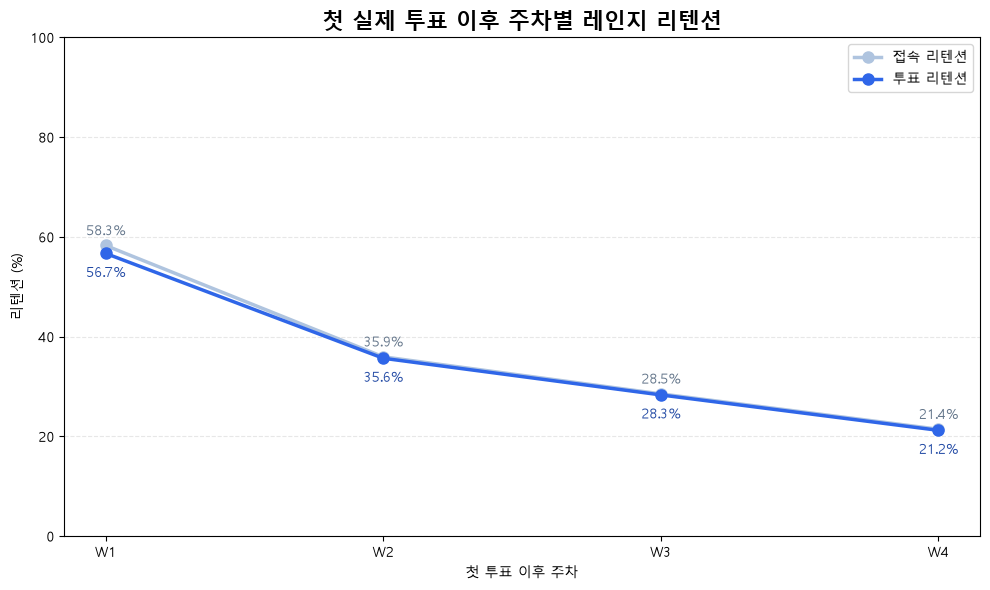

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_df = df_weekly_range_retention.copy()

rate_columns = [
    "login_retention_rate_percent",
    "vote_retention_rate_percent"
]

for column in rate_columns:
    plot_df[column] = pd.to_numeric(
        plot_df[column],
        errors="coerce"
    )

period_order = [
    "W1",
    "W2",
    "W3",
    "W4"
]

plot_df["period_order"] = (
    plot_df["retention_period"]
    .map({
        "W1": 1,
        "W2": 2,
        "W3": 3,
        "W4": 4
    })
)

plot_df = plot_df.sort_values(
    "period_order"
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

# 접속 리텐션
ax.plot(
    plot_df["retention_period"],
    plot_df["login_retention_rate_percent"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#AFC4DF",
    label="접속 리텐션"
)

# 투표 리텐션
ax.plot(
    plot_df["retention_period"],
    plot_df["vote_retention_rate_percent"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#2F66E8",
    label="투표 리텐션"
)

# 데이터 레이블
for _, row in plot_df.iterrows():
    ax.text(
        row["retention_period"],
        row["login_retention_rate_percent"] + 1.5,
        f"{row['login_retention_rate_percent']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#63758A"
    )

    ax.text(
        row["retention_period"],
        row["vote_retention_rate_percent"] - 2.5,
        f"{row['vote_retention_rate_percent']:.1f}%",
        ha="center",
        va="top",
        fontsize=10,
        color="#2149A4"
    )

ax.set_title(
    "첫 실제 투표 이후 주차별 레인지 리텐션",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("첫 투표 이후 주차")
ax.set_ylabel("리텐션 (%)")
ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

## 출시 직후 vs 개학 직후 주별 코호트

최초 실제 투표일이 출시 직후 또는 개학 직후에 속하는 사용자를 

각각 월요일 시작 주 단위 코호트로 묶고, W0(기준 주)부터 W8까지 구간별 재투표 리텐션을 계산해 코호트별 히트맵으로 그린다.

In [12]:
# 주 단위 코호트
seasonal_vote_cohort_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

-- 코호트 이후 서로 겹치지 않는 주차 구간
retention_windows AS (
  SELECT 'W0' AS retention_period, 0 AS start_day, 0 AS end_day, 0 AS sort_order
  UNION ALL
  SELECT 'W1', 1, 7, 1
  UNION ALL
  SELECT 'W2', 8, 14, 2
  UNION ALL
  SELECT 'W3', 15, 21, 3
  UNION ALL
  SELECT 'W4', 22, 28, 4
  UNION ALL
  SELECT 'W5', 29, 35, 5
  UNION ALL
  SELECT 'W6', 36, 42, 6
  UNION ALL
  SELECT 'W7', 43, 49, 7
  UNION ALL
  SELECT 'W8', 50, 56, 8
),

-- 탈퇴하지 않은 합성 데이터 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 유효한 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1

      FROM `ping-v2-503916.raw.user_withdrawal` AS w

      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at

  FROM `ping-v2-503916.raw.vote_item` AS vi

  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표 시점과 최초 투표 세션
first_vote AS (
  SELECT
    user_id,

    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY
        voted_at,
        session_id
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes

  GROUP BY user_id
),

-- Acquisition과 Activation을 모두 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,
    f.first_vote_at,

    DATE(
      f.first_vote_at,
      'Asia/Seoul'
    ) AS first_vote_date,

    f.first_vote_session_id

  FROM valid_users AS u

  JOIN first_vote AS f
    ON f.user_id = u.user_id

  -- 친구 5명 확보 조건
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 출시 직후와 개학 직후의 코호트 사용자
cohort_users AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    a.first_vote_session_id,

    CASE
      WHEN a.first_vote_date
        BETWEEN DATE '2025-09-01'
            AND DATE '2025-11-30'
      THEN '출시 직후'

      WHEN a.first_vote_date
        BETWEEN DATE '2026-03-02'
            AND DATE '2026-05-31'
      THEN '개학 직후'
    END AS season_group,

    -- 월요일을 한 주의 시작으로 설정
    DATE_TRUNC(
      a.first_vote_date,
      WEEK(MONDAY)
    ) AS cohort_week_start

  FROM activated_users AS a

  WHERE a.first_vote_date
      BETWEEN DATE '2025-09-01'
          AND DATE '2025-11-30'

     OR a.first_vote_date
      BETWEEN DATE '2026-03-02'
          AND DATE '2026-05-31'
),

-- 코호트 주의 마지막 날짜
cohort_users_with_end AS (
  SELECT
    *,
    DATE_ADD(
      cohort_week_start,
      INTERVAL 6 DAY
    ) AS cohort_week_end

  FROM cohort_users
),

-- 최초 투표와 다른 세션에서 다시 투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    c.user_id,

    DATE(
      v.voted_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM cohort_users_with_end AS c

  JOIN actual_votes AS v
    ON v.user_id = c.user_id

  -- 최초 투표 세션의 나머지 투표 제외
  WHERE v.session_id != c.first_vote_session_id

    -- 최초 투표 당일 행동 제외
    AND DATE(
          v.voted_at,
          'Asia/Seoul'
        ) > c.first_vote_date
),

-- 사용자와 W0~W8 조합 생성
expanded_users AS (
  SELECT
    c.user_id,
    c.season_group,
    c.cohort_week_start,
    c.cohort_week_end,
    c.first_vote_date,

    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order,

    -- 코호트 전체가 해당 주차까지 관찰 가능한지 확인
    CASE
      WHEN w.retention_period = 'W0'
      THEN 1

      WHEN c.cohort_week_end
        <= DATE_SUB(
             p.data_end_date,
             INTERVAL w.end_day DAY
           )
      THEN 1

      ELSE 0
    END AS is_observable

  FROM cohort_users_with_end AS c

  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p
),

-- 사용자별 주차 리텐션 여부
user_retention_flags AS (
  SELECT
    e.user_id,
    e.season_group,
    e.cohort_week_start,
    e.cohort_week_end,
    e.retention_period,
    e.start_day,
    e.end_day,
    e.sort_order,
    e.is_observable,

    CASE
      -- W0는 최초 실제 투표를 한 코호트이므로 100%
      WHEN e.retention_period = 'W0'
      THEN 1

      -- 아직 관찰할 수 없는 구간은 NULL
      WHEN e.is_observable = 0
      THEN NULL

      -- 해당 주차에 재투표가 있으면 1
      ELSE MAX(
        CASE
          WHEN v.user_id IS NOT NULL
          THEN 1
          ELSE 0
        END
      )
    END AS vote_retained

  FROM expanded_users AS e

  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id

   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.season_group,
    e.cohort_week_start,
    e.cohort_week_end,
    e.retention_period,
    e.start_day,
    e.end_day,
    e.sort_order,
    e.is_observable
)

SELECT
  season_group,
  cohort_week_start,
  cohort_week_end,
  retention_period,
  start_day,
  end_day,

  -- 해당 주에 처음 실제 투표한 전체 사용자
  COUNT(*) AS cohort_user_count,

  -- 코호트 전체를 관찰할 수 있을 때만 분모 표시
  IF(
    COUNTIF(is_observable = 1) = 0,
    NULL,
    COUNTIF(is_observable = 1)
  ) AS eligible_user_count,

  -- 해당 주차 재투표 사용자
  IF(
    COUNTIF(is_observable = 1) = 0,
    NULL,
    COUNTIF(vote_retained = 1)
  ) AS retained_user_count,

  -- 투표 코호트 리텐션
  ROUND(
    SAFE_DIVIDE(
      COUNTIF(vote_retained = 1),
      COUNTIF(is_observable = 1)
    ) * 100,
    2
  ) AS retention_rate_percent,

  -- 직접 이탈률을 확인하기 위한 보조 지표
  ROUND(
    100
    - SAFE_DIVIDE(
        COUNTIF(vote_retained = 1),
        COUNTIF(is_observable = 1)
      ) * 100,
    2
  ) AS churn_rate_percent

FROM user_retention_flags

GROUP BY
  season_group,
  cohort_week_start,
  cohort_week_end,
  retention_period,
  start_day,
  end_day,
  sort_order

ORDER BY
  CASE season_group
    WHEN '출시 직후' THEN 1
    WHEN '개학 직후' THEN 2
  END,
  cohort_week_start,
  sort_order
"""

In [13]:
cost(seasonal_vote_cohort_sql)

예상 스캔량: 394.157 MiB
예상 스캔량: 0.384919 GiB
월 1 TiB 무료 용량의 약 0.03758976%


0.3849191116169095

In [14]:
df_seasonal_cohort = bq.query(
    seasonal_vote_cohort_sql
).to_dataframe()

display(df_seasonal_cohort)

,season_group,cohort_week_start,cohort_week_end,retention_period,start_day,end_day,cohort_user_count,eligible_user_count,retained_user_count,retention_rate_percent,churn_rate_percent
0,출시 직후,2025-09-01,2025-09-07,W0,0,0,823,823,823,100.00,0.00
1,출시 직후,2025-09-01,2025-09-07,W1,1,7,823,823,570,69.26,30.74
2,출시 직후,2025-09-01,2025-09-07,W2,8,14,823,823,344,41.80,58.20
3,출시 직후,2025-09-01,2025-09-07,W3,15,21,823,823,291,35.36,64.64
4,출시 직후,2025-09-01,2025-09-07,W4,22,28,823,823,220,26.73,73.27
...,...,...,...,...,...,...,...,...,...,...,...
229,개학 직후,2026-05-25,2026-05-31,W4,22,28,275,275,56,20.36,79.64
230,개학 직후,2026-05-25,2026-05-31,W5,29,35,275,275,45,16.36,83.64
231,개학 직후,2026-05-25,2026-05-31,W6,36,42,275,275,39,14.18,85.82
232,개학 직후,2026-05-25,2026-05-31,W7,43,49,275,275,38,13.82,86.18


In [15]:
import pandas as pd

cohort_output = df_seasonal_cohort.copy()

date_columns = [
    "cohort_week_start",
    "cohort_week_end"
]

for column in date_columns:
    cohort_output[column] = pd.to_datetime(
        cohort_output[column]
    )

numeric_columns = [
    "cohort_user_count",
    "eligible_user_count",
    "retained_user_count",
    "retention_rate_percent",
    "churn_rate_percent"
]

for column in numeric_columns:
    cohort_output[column] = pd.to_numeric(
        cohort_output[column],
        errors="coerce"
    )

period_order = [
    "W0",
    "W1",
    "W2",
    "W3",
    "W4",
    "W5",
    "W6",
    "W7",
    "W8"
]

period_map = {
    period: index
    for index, period in enumerate(period_order)
}

cohort_output["period_order"] = (
    cohort_output["retention_period"]
    .map(period_map)
)

cohort_output = cohort_output.sort_values(
    [
        "season_group",
        "cohort_week_start",
        "period_order"
    ]
)

season_order = [
    "출시 직후",
    "개학 직후"
]

for season in season_order:
    print("=" * 65)
    print(f"[{season} 코호트]")
    print("=" * 65)
    print()

    season_df = cohort_output[
        cohort_output["season_group"] == season
    ]

    cohort_dates = (
        season_df[
            [
                "cohort_week_start",
                "cohort_week_end"
            ]
        ]
        .drop_duplicates()
        .sort_values("cohort_week_start")
    )

    for _, date_row in cohort_dates.iterrows():
        start_date = date_row["cohort_week_start"]
        end_date = date_row["cohort_week_end"]

        cohort_df = season_df[
            season_df["cohort_week_start"] == start_date
        ].sort_values("period_order")

        cohort_size = int(
            cohort_df["cohort_user_count"].iloc[0]
        )

        print(
            f"[{start_date:%Y-%m-%d} ~ "
            f"{end_date:%Y-%m-%d}] "
            f"코호트 사용자: {cohort_size:,}명"
        )

        result_parts = []

        for _, row in cohort_df.iterrows():
            period = row["retention_period"]
            rate = row["retention_rate_percent"]
            retained_count = row["retained_user_count"]

            if pd.isna(rate):
                result_parts.append(
                    f"{period}: 관찰 불가"
                )
            else:
                result_parts.append(
                    f"{period}: "
                    f"{int(retained_count):,}명 "
                    f"({rate:.2f}%)"
                )

        print(" | ".join(result_parts))
        print()

[출시 직후 코호트]

[2025-09-01 ~ 2025-09-07] 코호트 사용자: 823명
W0: 823명 (100.00%) | W1: 570명 (69.26%) | W2: 344명 (41.80%) | W3: 291명 (35.36%) | W4: 220명 (26.73%) | W5: 155명 (18.83%) | W6: 126명 (15.31%) | W7: 121명 (14.70%) | W8: 106명 (12.88%)

[2025-09-08 ~ 2025-09-14] 코호트 사용자: 1,170명
W0: 1,170명 (100.00%) | W1: 790명 (67.52%) | W2: 433명 (37.01%) | W3: 357명 (30.51%) | W4: 268명 (22.91%) | W5: 177명 (15.13%) | W6: 150명 (12.82%) | W7: 139명 (11.88%) | W8: 129명 (11.03%)

[2025-09-15 ~ 2025-09-21] 코호트 사용자: 1,243명
W0: 1,243명 (100.00%) | W1: 821명 (66.05%) | W2: 477명 (38.37%) | W3: 366명 (29.44%) | W4: 266명 (21.40%) | W5: 194명 (15.61%) | W6: 175명 (14.08%) | W7: 160명 (12.87%) | W8: 147명 (11.83%)

[2025-09-22 ~ 2025-09-28] 코호트 사용자: 1,241명
W0: 1,241명 (100.00%) | W1: 849명 (68.41%) | W2: 467명 (37.63%) | W3: 356명 (28.69%) | W4: 232명 (18.69%) | W5: 175명 (14.10%) | W6: 164명 (13.22%) | W7: 144명 (11.60%) | W8: 133명 (10.72%)

[2025-09-29 ~ 2025-10-05] 코호트 사용자: 774명
W0: 774명 (100.00%) | W1: 393명 (50.78%) | W2: 237명 (30.6

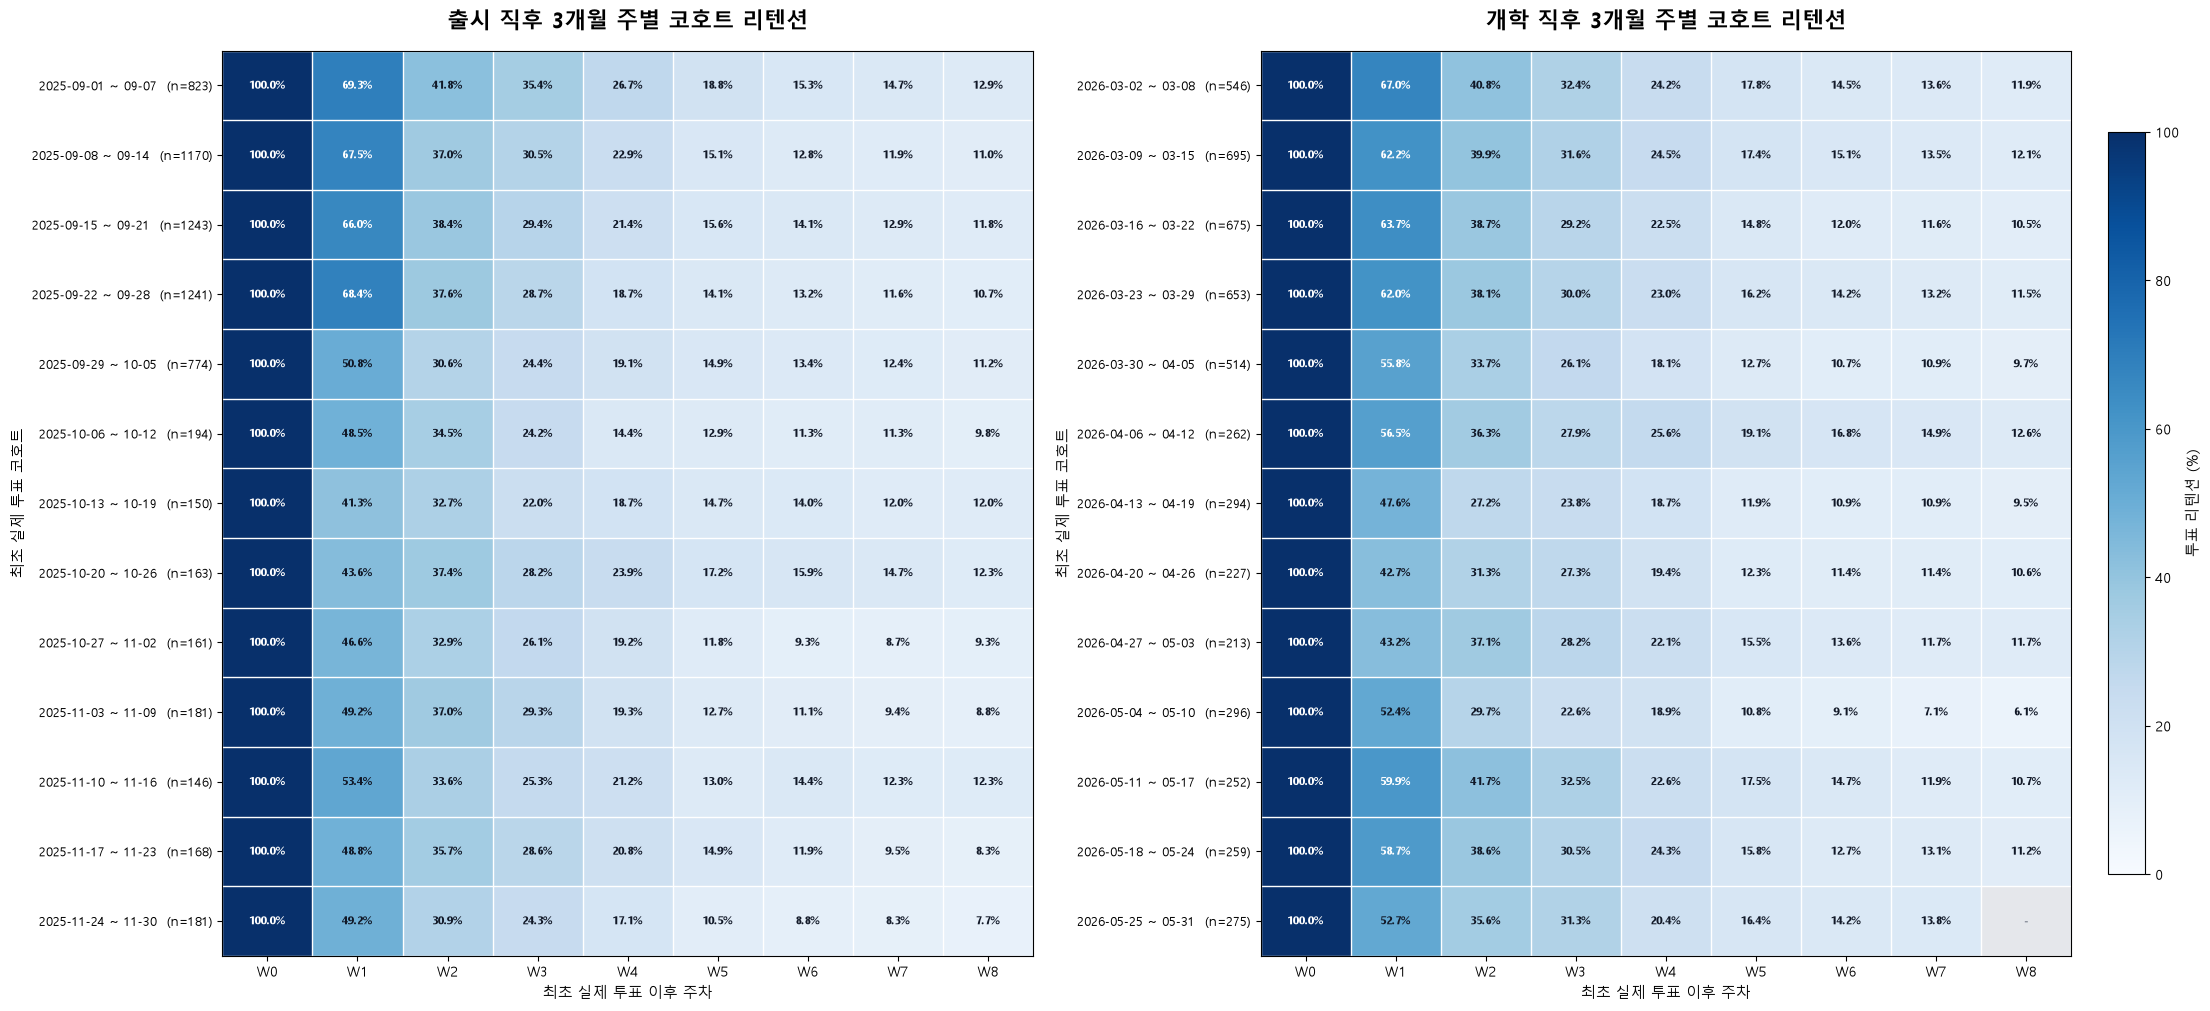

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

# Windows·Mac 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_df = df_seasonal_cohort.copy()

# 날짜형 변환
plot_df["cohort_week_start"] = pd.to_datetime(
    plot_df["cohort_week_start"]
)

plot_df["cohort_week_end"] = pd.to_datetime(
    plot_df["cohort_week_end"]
)

# 숫자형 변환
plot_df["retention_rate_percent"] = pd.to_numeric(
    plot_df["retention_rate_percent"],
    errors="coerce"
)

plot_df["cohort_user_count"] = pd.to_numeric(
    plot_df["cohort_user_count"],
    errors="coerce"
)

# 코호트 행 표시명
plot_df["cohort_label"] = (
    plot_df["cohort_week_start"].dt.strftime("%Y-%m-%d")
    + " ~ "
    + plot_df["cohort_week_end"].dt.strftime("%m-%d")
    + "  (n="
    + plot_df["cohort_user_count"]
      .astype("Int64")
      .astype(str)
    + ")"
)

# 일반적인 코호트 차트처럼 W0 포함
period_order = [
    "W0",
    "W1",
    "W2",
    "W3",
    "W4",
    "W5",
    "W6",
    "W7",
    "W8"
]

season_order = [
    "출시 직후",
    "개학 직후"
]

# 결측값은 회색으로 표시
cohort_cmap = plt.cm.Blues.copy()
cohort_cmap.set_bad(
    color="#E5E7EB"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, 10),
    constrained_layout=True
)

last_image = None

for ax, season in zip(
    axes,
    season_order
):
    season_df = (
        plot_df[
            plot_df["season_group"] == season
        ]
        .sort_values(
            [
                "cohort_week_start",
                "retention_period"
            ]
        )
    )

    # 코호트 행 순서
    cohort_order = (
        season_df[
            [
                "cohort_week_start",
                "cohort_label"
            ]
        ]
        .drop_duplicates()
        .sort_values("cohort_week_start")
        ["cohort_label"]
        .tolist()
    )

    # 히트맵용 피벗 테이블
    heatmap_data = (
        season_df
        .pivot(
            index="cohort_label",
            columns="retention_period",
            values="retention_rate_percent"
        )
        .reindex(
            index=cohort_order,
            columns=period_order
        )
    )

    # 숫자 행렬
    heatmap_values = (
        heatmap_data
        .astype(float)
        .to_numpy()
    )

    # 결측값 마스킹
    masked_values = np.ma.masked_invalid(
        heatmap_values
    )

    last_image = ax.imshow(
        masked_values,
        cmap=cohort_cmap,
        vmin=0,
        vmax=100,
        aspect="auto"
    )

    # X축: W0~W8
    ax.set_xticks(
        np.arange(len(period_order))
    )

    ax.set_xticklabels(
        period_order
    )

    # Y축: 주별 코호트
    ax.set_yticks(
        np.arange(len(cohort_order))
    )

    ax.set_yticklabels(
        cohort_order,
        fontsize=9
    )

    ax.set_title(
        f"{season} 3개월 주별 코호트 리텐션",
        fontsize=16,
        fontweight="bold",
        pad=16
    )

    ax.set_xlabel(
        "최초 실제 투표 이후 주차",
        fontsize=11
    )

    ax.set_ylabel(
        "최초 실제 투표 코호트",
        fontsize=11
    )

    # 셀 경계선
    ax.set_xticks(
        np.arange(
            -0.5,
            len(period_order),
            1
        ),
        minor=True
    )

    ax.set_yticks(
        np.arange(
            -0.5,
            len(cohort_order),
            1
        ),
        minor=True
    )

    ax.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=1
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    # 셀 안에 비율 표시
    for row_index in range(
        len(cohort_order)
    ):
        for column_index in range(
            len(period_order)
        ):
            value = heatmap_values[
                row_index,
                column_index
            ]

            # 관찰 기간이 부족한 셀
            if np.isnan(value):
                cell_text = "-"
                text_color = "#6B7280"

            else:
                cell_text = f"{value:.1f}%"

                # 배경색에 따른 글자색 조절
                if value >= 55:
                    text_color = "white"
                else:
                    text_color = "#111827"

            ax.text(
                column_index,
                row_index,
                cell_text,
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
                fontweight=(
                    "bold"
                    if not np.isnan(value)
                    else "normal"
                )
            )

# 두 그래프가 동일한 색상 기준을 공유
colorbar = fig.colorbar(
    last_image,
    ax=axes.ravel().tolist(),
    shrink=0.82,
    pad=0.02
)

colorbar.set_label(
    "투표 리텐션 (%)",
    fontsize=11
)

plt.show()

## 월별 코호트 리텐션 히트맵

2025-09-01부터 데이터 종료일까지 최초 투표월(`cohort_month`)을 기준으로 사용자를 월별 코호트로 묶고, 

W0~W8 구간의 재투표 리텐션을 코호트×기간 히트맵으로 그린다.

In [20]:
# 월별 11개 코호트
monthly_cohort_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS cohort_start_month,
    DATE '2026-07-23' AS data_end_date
),

-- W0는 최초 투표를 완료한 코호트 자체
-- W1부터는 서로 겹치지 않는 주 단위 구간
retention_periods AS (
  SELECT 0 AS period_order, 'W0' AS retention_period, 0 AS start_day, 0 AS end_day
  UNION ALL
  SELECT 1, 'W1', 1, 7
  UNION ALL
  SELECT 2, 'W2', 8, 14
  UNION ALL
  SELECT 3, 'W3', 15, 21
  UNION ALL
  SELECT 4, 'W4', 22, 28
  UNION ALL
  SELECT 5, 'W5', 29, 35
  UNION ALL
  SELECT 6, 'W6', 36, 42
  UNION ALL
  SELECT 7, 'W7', 43, 49
  UNION ALL
  SELECT 8, 'W8', 50, 56
),

-- 탈퇴하지 않았고 친구 5명 조건을 충족한 사용자
valid_unlocked_users AS (
  SELECT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    -- user_withdrawal에 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at,
    DATE(vi.voted_at, 'Asia/Seoul') AS vote_date
  FROM `ping-v2-503916.raw.vote_item` AS vi
  INNER JOIN valid_unlocked_users AS vu
    ON vi.user_id = vu.user_id
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표와 해당 세션
first_vote AS (
  SELECT
    user_id,

    ARRAY_AGG(
      STRUCT(
        voted_at,
        session_id
      )
      ORDER BY voted_at, session_id
      LIMIT 1
    )[OFFSET(0)] AS first_vote_info

  FROM actual_votes
  GROUP BY user_id
),

-- Retention 분석 기준 사용자
activated_users AS (
  SELECT
    user_id,
    first_vote_info.voted_at AS first_vote_at,
    first_vote_info.session_id AS first_session_id,

    DATE(
      first_vote_info.voted_at,
      'Asia/Seoul'
    ) AS first_vote_date,

    DATE_TRUNC(
      DATE(first_vote_info.voted_at, 'Asia/Seoul'),
      MONTH
    ) AS cohort_month

  FROM first_vote
  CROSS JOIN params
  WHERE DATE(first_vote_info.voted_at, 'Asia/Seoul')
        BETWEEN cohort_start_month AND data_end_date
),

-- 최초 투표와 다른 세션에서 발생한 재투표
return_votes AS (
  SELECT DISTINCT
    au.user_id,
    au.cohort_month,
    au.first_vote_date,
    av.vote_date AS return_vote_date,

    DATE_DIFF(
      av.vote_date,
      au.first_vote_date,
      DAY
    ) AS days_after_first_vote

  FROM activated_users AS au
  INNER JOIN actual_votes AS av
    ON av.user_id = au.user_id

    -- 최초 투표 세션 안에서 이어서 한 투표는 재방문으로 보지 않음
    AND av.session_id != au.first_session_id

    -- 최초 투표 다음 날 이후 행동만 포함
    AND av.vote_date > au.first_vote_date
),

-- 코호트 사용자 × 리텐션 기간
cohort_period_base AS (
  SELECT
    au.cohort_month,
    au.user_id,
    rp.period_order,
    rp.retention_period,
    rp.start_day,
    rp.end_day,
    p.data_end_date,

    -- 해당 월 전체 사용자가 해당 기간까지 관찰 가능한지 판정
    CASE
      WHEN rp.period_order = 0 THEN TRUE
      WHEN DATE_ADD(
             LAST_DAY(au.cohort_month, MONTH),
             INTERVAL rp.end_day DAY
           ) <= p.data_end_date
        THEN TRUE
      ELSE FALSE
    END AS is_observable

  FROM activated_users AS au
  CROSS JOIN retention_periods AS rp
  CROSS JOIN params AS p
),

-- 기간별 재투표 여부
user_retention AS (
  SELECT
    cpb.cohort_month,
    cpb.user_id,
    cpb.period_order,
    cpb.retention_period,
    cpb.start_day,
    cpb.end_day,
    cpb.data_end_date,
    cpb.is_observable,

    CASE
      -- W0는 코호트 기준 사용자이므로 모두 1
      WHEN cpb.period_order = 0 THEN 1

      -- 관찰기간이 부족하면 결과 없음
      WHEN NOT cpb.is_observable THEN NULL

      -- 해당 주차 구간에 재투표한 경우
      WHEN COUNTIF(
        rv.days_after_first_vote
        BETWEEN cpb.start_day AND cpb.end_day
      ) > 0 THEN 1

      ELSE 0
    END AS is_retained

  FROM cohort_period_base AS cpb
  LEFT JOIN return_votes AS rv
    ON rv.user_id = cpb.user_id
    AND rv.days_after_first_vote
        BETWEEN cpb.start_day AND cpb.end_day

  GROUP BY
    cpb.cohort_month,
    cpb.user_id,
    cpb.period_order,
    cpb.retention_period,
    cpb.start_day,
    cpb.end_day,
    cpb.data_end_date,
    cpb.is_observable
),

-- 월별 코호트 집계
cohort_result AS (
  SELECT
    cohort_month,
    period_order,
    retention_period,
    start_day,
    end_day,
    data_end_date,
    is_observable,

    COUNT(DISTINCT user_id) AS cohort_user_count,

    CASE
      WHEN is_observable
        THEN COUNT(DISTINCT user_id)
      ELSE NULL
    END AS eligible_user_count,

    CASE
      WHEN is_observable
        THEN COUNT(DISTINCT IF(is_retained = 1, user_id, NULL))
      ELSE NULL
    END AS retained_user_count

  FROM user_retention
  GROUP BY
    cohort_month,
    period_order,
    retention_period,
    start_day,
    end_day,
    data_end_date,
    is_observable
)

SELECT
  FORMAT_DATE('%Y-%m', cohort_month) AS cohort_label,
  cohort_month,
  retention_period,
  period_order,
  start_day,
  end_day,
  cohort_user_count,
  eligible_user_count,
  retained_user_count,

  CASE
    WHEN is_observable THEN
      ROUND(
        SAFE_DIVIDE(
          retained_user_count,
          eligible_user_count
        ) * 100,
        2
      )
    ELSE NULL
  END AS retention_rate_percent,

  CASE
    WHEN is_observable THEN
      ROUND(
        (
          1 - SAFE_DIVIDE(
            retained_user_count,
            eligible_user_count
          )
        ) * 100,
        2
      )
    ELSE NULL
  END AS churn_rate_percent,

  is_observable,

  CASE
    WHEN cohort_month = DATE_TRUNC(data_end_date, MONTH)
      THEN '부분 월'
    ELSE '완료 월'
  END AS cohort_status

FROM cohort_result
ORDER BY
  cohort_month,
  period_order
"""

In [21]:
cost(monthly_cohort_sql)

예상 스캔량: 394.157 MiB
예상 스캔량: 0.384919 GiB
월 1 TiB 무료 용량의 약 0.03758976%


0.3849191116169095

In [22]:
monthly_cohort_df = (
    bq.query(monthly_cohort_sql)
      .result()
      .to_dataframe()
)

monthly_cohort_df.head(20)

,cohort_label,cohort_month,retention_period,period_order,start_day,end_day,cohort_user_count,eligible_user_count,retained_user_count,retention_rate_percent,churn_rate_percent,is_observable,cohort_status
0,2025-09,2025-09-01,W0,0,0,0,4843,4843,4843,100.00,0.00,True,완료 월
1,2025-09,2025-09-01,W1,1,1,7,4843,4843,3237,66.84,33.16,True,완료 월
2,2025-09,2025-09-01,W2,2,8,14,4843,4843,1833,37.85,62.15,True,완료 월
3,2025-09,2025-09-01,W3,3,15,21,4843,4843,1456,30.06,69.94,True,완료 월
4,2025-09,2025-09-01,W4,4,22,28,4843,4843,1054,21.76,78.24,True,완료 월
5,2025-09,2025-09-01,W5,5,29,35,4843,4843,753,15.55,84.45,True,완료 월
6,2025-09,2025-09-01,W6,6,36,42,4843,4843,662,13.67,86.33,True,완료 월
7,2025-09,2025-09-01,W7,7,43,49,4843,4843,606,12.51,87.49,True,완료 월
8,2025-09,2025-09-01,W8,8,50,56,4843,4843,554,11.44,88.56,True,완료 월
9,2025-10,2025-10-01,W0,0,0,0,1025,1025,1025,100.00,0.00,True,완료 월


In [23]:
import pandas as pd

period_order = [
    "W0", "W1", "W2", "W3", "W4",
    "W5", "W6", "W7", "W8"
]

sentence_df = monthly_cohort_df.copy()

sentence_df["retention_rate_percent"] = pd.to_numeric(
    sentence_df["retention_rate_percent"],
    errors="coerce"
)

for cohort_label in sorted(sentence_df["cohort_label"].unique()):
    
    cohort_data = (
        sentence_df[
            sentence_df["cohort_label"] == cohort_label
        ]
        .set_index("retention_period")
        .reindex(period_order)
    )

    cohort_user_count = int(
        cohort_data["cohort_user_count"].dropna().iloc[0]
    )

    cohort_status = (
        cohort_data["cohort_status"].dropna().iloc[0]
    )

    retention_texts = []

    for period in period_order:
        rate = cohort_data.loc[
            period,
            "retention_rate_percent"
        ]

        if pd.isna(rate):
            retention_texts.append(
                f"{period} 관찰 불가"
            )
        else:
            retention_texts.append(
                f"{period} {float(rate):.2f}%"
            )

    print(
        f"[{cohort_label} 코호트 · {cohort_status}] "
        f"사용자 {cohort_user_count:,}명 | "
        + " · ".join(retention_texts)
    )

[2025-09 코호트 · 완료 월] 사용자 4,843명 | W0 100.00% · W1 66.84% · W2 37.85% · W3 30.06% · W4 21.76% · W5 15.55% · W6 13.67% · W7 12.51% · W8 11.44%
[2025-10 코호트 · 완료 월] 사용자 1,025명 | W0 100.00% · W1 45.46% · W2 33.07% · W3 25.17% · W4 19.02% · W5 14.83% · W6 13.27% · W7 12.29% · W8 11.12%
[2025-11 코호트 · 완료 월] 사용자 727명 | W0 100.00% · W1 49.52% · W2 34.11% · W3 26.82% · W4 19.67% · W5 12.52% · W6 11.28% · W7 9.90% · W8 9.35%
[2025-12 코호트 · 완료 월] 사용자 731명 | W0 100.00% · W1 41.72% · W2 29.96% · W3 22.30% · W4 17.37% · W5 12.45% · W6 10.67% · W7 9.17% · W8 8.62%
[2026-01 코호트 · 완료 월] 사용자 404명 | W0 100.00% · W1 39.60% · W2 31.93% · W3 26.24% · W4 19.80% · W5 17.08% · W6 15.10% · W7 15.59% · W8 15.35%
[2026-02 코호트 · 완료 월] 사용자 392명 | W0 100.00% · W1 37.50% · W2 30.10% · W3 26.53% · W4 21.17% · W5 15.82% · W6 14.54% · W7 13.27% · W8 12.24%
[2026-03 코호트 · 완료 월] 사용자 2,807명 | W0 100.00% · W1 63.09% · W2 39.05% · W3 30.42% · W4 23.01% · W5 16.32% · W6 13.86% · W7 12.93% · W8 11.51%
[2026-04 코호트 · 완료 월] 사용자 

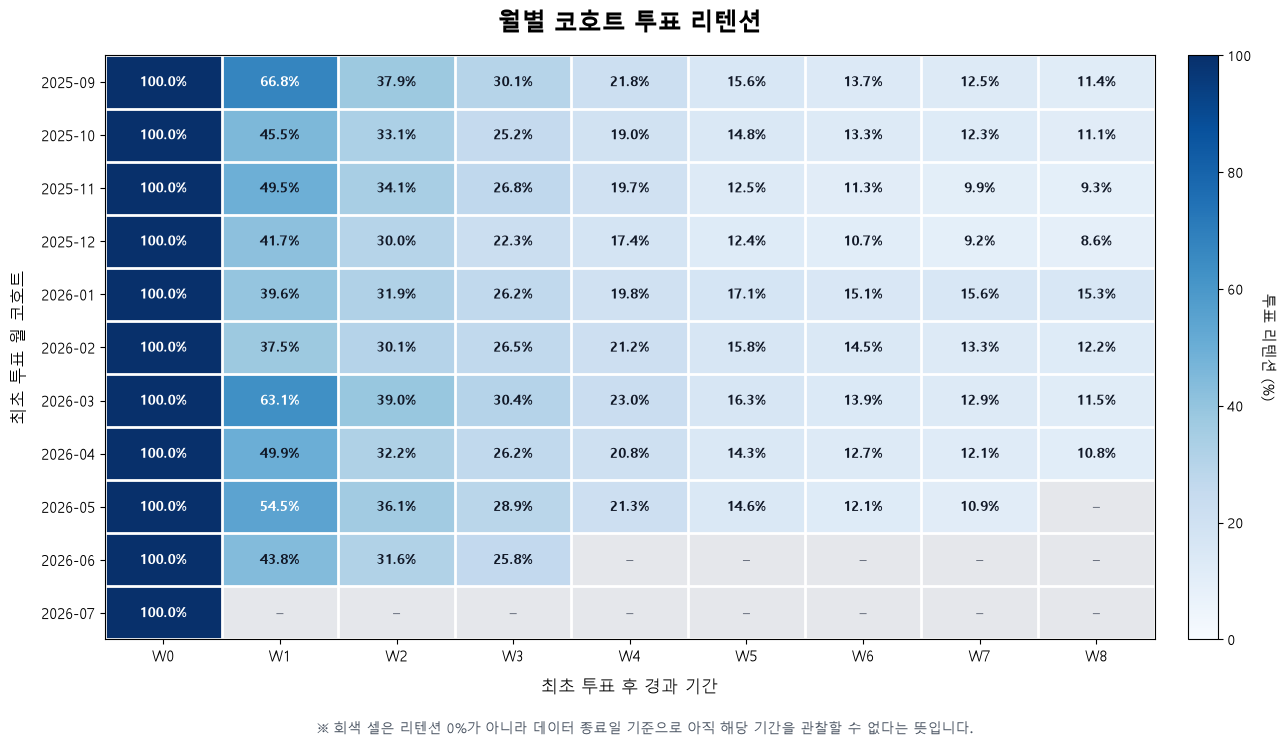

In [25]:
import platform
from copy import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트 설정
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 코호트·리텐션 기간 순서 설정
# =========================================================

period_order = [
    "W0", "W1", "W2", "W3", "W4",
    "W5", "W6", "W7", "W8"
]

cohort_order = sorted(
    monthly_cohort_df["cohort_label"]
    .dropna()
    .unique()
)


# =========================================================
# 3. 히트맵용 데이터 생성
# =========================================================

heatmap_df = (
    monthly_cohort_df
    .pivot_table(
        index="cohort_label",
        columns="retention_period",
        values="retention_rate_percent",
        aggfunc="first"
    )
    .reindex(
        index=cohort_order,
        columns=period_order
    )
)

# BigQuery 결과의 Decimal 또는 문자열을 숫자로 변환
heatmap_df = heatmap_df.apply(
    pd.to_numeric,
    errors="coerce"
)

# NumPy 배열로 변환
heatmap_values = heatmap_df.to_numpy(
    dtype=float
)

# NULL 값을 마스킹
# 관찰기간이 부족한 셀을 0%와 구분하기 위함
masked_values = np.ma.masked_invalid(
    heatmap_values
)


# =========================================================
# 4. 색상 설정
# =========================================================

# Matplotlib 구버전에서도 작동하도록 설정
cmap = copy(plt.cm.Blues)

# 관찰기간이 부족한 셀은 회색
cmap.set_bad(
    color="#E5E7EB"
)


# =========================================================
# 5. 히트맵 생성
# =========================================================

fig, ax = plt.subplots(
    figsize=(13, 7.5)
)

image = ax.imshow(
    masked_values,
    cmap=cmap,
    vmin=0,
    vmax=100,
    aspect="auto"
)


# =========================================================
# 6. X축·Y축 설정
# =========================================================

ax.set_xticks(
    np.arange(len(period_order))
)

ax.set_xticklabels(
    period_order,
    fontsize=11
)

ax.set_yticks(
    np.arange(len(cohort_order))
)

ax.set_yticklabels(
    cohort_order,
    fontsize=11
)

ax.set_xlabel(
    "최초 투표 후 경과 기간",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "최초 투표 월 코호트",
    fontsize=12,
    labelpad=10
)

ax.set_title(
    "월별 코호트 투표 리텐션",
    fontsize=17,
    fontweight="bold",
    pad=18
)


# =========================================================
# 7. 셀 경계선 설정
# =========================================================

ax.set_xticks(
    np.arange(-0.5, len(period_order), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(cohort_order), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)


# =========================================================
# 8. 셀 안에 리텐션 수치 표시
# =========================================================

for row_idx in range(len(cohort_order)):
    for col_idx in range(len(period_order)):

        value = heatmap_values[
            row_idx,
            col_idx
        ]

        if np.isnan(value):
            # 관찰기간 부족
            label = "–"
            text_color = "#6B7280"
            font_weight = "normal"

        else:
            label = f"{value:.1f}%"

            # 배경색이 진한 셀은 흰색 글자 사용
            if value >= 50:
                text_color = "white"
            else:
                text_color = "#111827"

            font_weight = "bold"

        ax.text(
            col_idx,
            row_idx,
            label,
            ha="center",
            va="center",
            fontsize=10,
            fontweight=font_weight,
            color=text_color
        )


# =========================================================
# 9. 컬러바 설정
# =========================================================

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.03
)

colorbar.set_label(
    "투표 리텐션 (%)",
    rotation=270,
    labelpad=18,
    fontsize=11
)


# =========================================================
# 10. 설명 문구
# =========================================================

fig.text(
    0.5,
    0.015,
    "※ 회색 셀은 리텐션 0%가 아니라 데이터 종료일 기준으로 아직 해당 기간을 관찰할 수 없다는 뜻입니다.",
    ha="center",
    fontsize=10,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.045, 1, 1]
)

plt.show()

## D0~D30 클래식(일 단위) 리텐션

2025-09-01부터 데이터 종료일 30일 전 사이에 최초 투표한 사용자를 대상으로, D0부터 D30까지 각 날짜에 '정확히 그 날짜'에 최초 세션이 아닌 곳에서 재투표했는지를 확인해(구간 누적이 아닌 일 단위 스냅샷) 리텐션 곡선을 그린다.

In [26]:
# 클래식 리텐션
classic_retention_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date,
    30 AS max_retention_day
),

-- D0부터 D30까지 생성
retention_days AS (
  SELECT
    day_number,
    CONCAT('D', CAST(day_number AS STRING)) AS retention_day
  FROM UNNEST(
    GENERATE_ARRAY(0, 30)
  ) AS day_number
),

-- 탈퇴하지 않았고 친구 5명 조건을 충족한 사용자
valid_unlocked_users AS (
  SELECT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    -- 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 유효 사용자의 실제 투표
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at,
    DATE(
      vi.voted_at,
      'Asia/Seoul'
    ) AS vote_date

  FROM `ping-v2-503916.raw.vote_item` AS vi

  INNER JOIN valid_unlocked_users AS vu
    ON vi.user_id = vu.user_id

  CROSS JOIN params AS p

  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL

    -- 데이터 종료일 이후 기록이 있더라도 제외
    AND DATE(
      vi.voted_at,
      'Asia/Seoul'
    ) <= p.data_end_date
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    session_id AS first_session_id,
    voted_at AS first_vote_at,
    vote_date AS first_vote_date

  FROM actual_votes

  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY user_id
    ORDER BY voted_at, session_id
  ) = 1
),

-- D30까지 전부 관찰할 수 있는 사용자만 포함
eligible_users AS (
  SELECT
    fv.user_id,
    fv.first_session_id,
    fv.first_vote_at,
    fv.first_vote_date

  FROM first_vote AS fv
  CROSS JOIN params AS p

  WHERE fv.first_vote_date
        BETWEEN p.analysis_start_date
        AND DATE_SUB(
          p.data_end_date,
          INTERVAL p.max_retention_day DAY
        )
),

-- 최초 투표와 다른 세션에서 발생한 재투표
return_votes AS (
  SELECT DISTINCT
    eu.user_id,
    av.vote_date AS return_vote_date,

    DATE_DIFF(
      av.vote_date,
      eu.first_vote_date,
      DAY
    ) AS days_after_first_vote

  FROM eligible_users AS eu

  INNER JOIN actual_votes AS av
    ON av.user_id = eu.user_id

    -- 최초 세션의 연속 투표 제외
    AND av.session_id != eu.first_session_id

    -- 최초 투표 다음 날부터 D30까지만 사용
    AND av.vote_date > eu.first_vote_date
    AND DATE_DIFF(
          av.vote_date,
          eu.first_vote_date,
          DAY
        ) BETWEEN 1 AND 30
),

-- 사용자와 D0~D30을 조합
user_day_retention AS (
  SELECT
    eu.user_id,
    rd.day_number,
    rd.retention_day,

    CASE
      -- D0는 최초 실제 투표 사용자이므로 모두 잔존
      WHEN rd.day_number = 0 THEN 1

      -- 정확히 해당 날짜에 다른 세션에서 재투표한 경우
      WHEN COUNTIF(
        rv.days_after_first_vote = rd.day_number
      ) > 0 THEN 1

      ELSE 0
    END AS is_retained

  FROM eligible_users AS eu

  CROSS JOIN retention_days AS rd

  LEFT JOIN return_votes AS rv
    ON rv.user_id = eu.user_id
    AND rv.days_after_first_vote = rd.day_number

  GROUP BY
    eu.user_id,
    rd.day_number,
    rd.retention_day
)

SELECT
  day_number,
  retention_day,

  COUNT(DISTINCT user_id) AS eligible_user_count,

  COUNT(
    DISTINCT IF(
      is_retained = 1,
      user_id,
      NULL
    )
  ) AS retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNT(
        DISTINCT IF(
          is_retained = 1,
          user_id,
          NULL
        )
      ),
      COUNT(DISTINCT user_id)
    ) * 100,
    2
  ) AS retention_rate_percent,

  ROUND(
    (
      1 - SAFE_DIVIDE(
        COUNT(
          DISTINCT IF(
            is_retained = 1,
            user_id,
            NULL
          )
        ),
        COUNT(DISTINCT user_id)
      )
    ) * 100,
    2
  ) AS non_return_rate_percent

FROM user_day_retention

GROUP BY
  day_number,
  retention_day

ORDER BY
  day_number
"""

In [27]:
cost(classic_retention_sql)

예상 스캔량: 394.157 MiB
예상 스캔량: 0.384919 GiB
월 1 TiB 무료 용량의 약 0.03758976%


0.3849191116169095

In [28]:
classic_retention_df = (
    bq.query(classic_retention_sql)
      .result()
      .to_dataframe()
)

classic_retention_df

,day_number,retention_day,eligible_user_count,retained_user_count,retention_rate_percent,non_return_rate_percent
0,0,D0,14010,14010,100.00,0.00
1,1,D1,14010,5990,42.76,57.24
2,2,D2,14010,5078,36.25,63.75
3,3,D3,14010,4736,33.80,66.20
4,4,D4,14010,4404,31.43,68.57
5,5,D5,14010,4237,30.24,69.76
6,6,D6,14010,4079,29.11,70.89
7,7,D7,14010,3958,28.25,71.75
8,8,D8,14010,3803,27.14,72.86
9,9,D9,14010,3660,26.12,73.88


In [29]:
eligible_user_count = int(
    classic_retention_df[
        "eligible_user_count"
    ].iloc[0]
)

print("[30일 클래식 투표 리텐션]")
print(
    f"분석 대상 사용자: "
    f"{eligible_user_count:,}명"
)
print(
    "분석 기준: 최초 실제 투표일을 D0로 설정하고, "
    "정확히 해당 날짜에 다른 세션에서 재투표했는지 확인"
)
print("-" * 65)

for _, row in classic_retention_df.iterrows():

    day = row["retention_day"]
    retained = int(
        row["retained_user_count"]
    )
    rate = float(
        row["retention_rate_percent"]
    )

    if row["day_number"] == 0:
        print(
            f"{day}: 기준 사용자 "
            f"{retained:,}명 ({rate:.2f}%)"
        )
    else:
        print(
            f"{day}: 재투표 사용자 "
            f"{retained:,}명 / "
            f"{eligible_user_count:,}명 "
            f"({rate:.2f}%)"
        )

[30일 클래식 투표 리텐션]
분석 대상 사용자: 14,010명
분석 기준: 최초 실제 투표일을 D0로 설정하고, 정확히 해당 날짜에 다른 세션에서 재투표했는지 확인
-----------------------------------------------------------------
D0: 기준 사용자 14,010명 (100.00%)
D1: 재투표 사용자 5,990명 / 14,010명 (42.76%)
D2: 재투표 사용자 5,078명 / 14,010명 (36.25%)
D3: 재투표 사용자 4,736명 / 14,010명 (33.80%)
D4: 재투표 사용자 4,404명 / 14,010명 (31.43%)
D5: 재투표 사용자 4,237명 / 14,010명 (30.24%)
D6: 재투표 사용자 4,079명 / 14,010명 (29.11%)
D7: 재투표 사용자 3,958명 / 14,010명 (28.25%)
D8: 재투표 사용자 3,803명 / 14,010명 (27.14%)
D9: 재투표 사용자 3,660명 / 14,010명 (26.12%)
D10: 재투표 사용자 3,532명 / 14,010명 (25.21%)
D11: 재투표 사용자 3,415명 / 14,010명 (24.38%)
D12: 재투표 사용자 3,321명 / 14,010명 (23.70%)
D13: 재투표 사용자 3,220명 / 14,010명 (22.98%)
D14: 재투표 사용자 3,095명 / 14,010명 (22.09%)
D15: 재투표 사용자 3,020명 / 14,010명 (21.56%)
D16: 재투표 사용자 2,863명 / 14,010명 (20.44%)
D17: 재투표 사용자 2,787명 / 14,010명 (19.89%)
D18: 재투표 사용자 2,626명 / 14,010명 (18.74%)
D19: 재투표 사용자 2,550명 / 14,010명 (18.20%)
D20: 재투표 사용자 2,480명 / 14,010명 (17.70%)
D21: 재투표 사용자 2,363명 / 14,010명 (16.87%)
D2

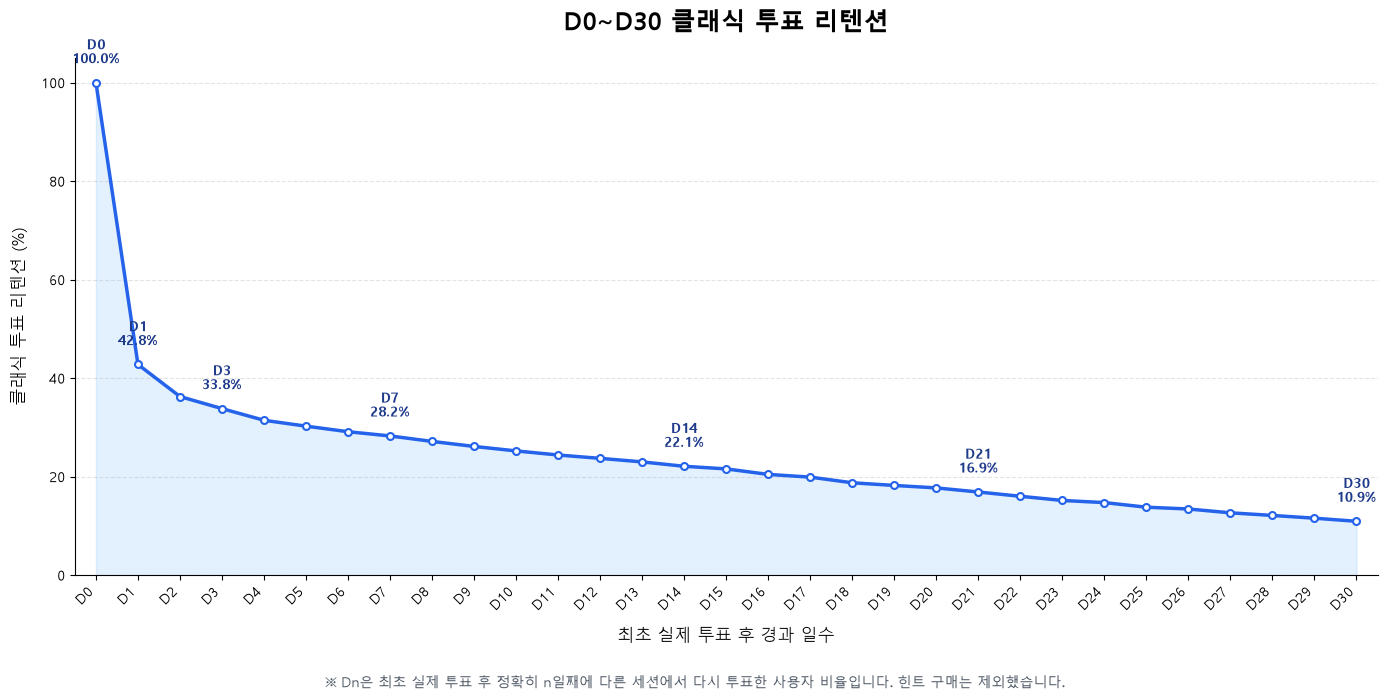

In [30]:
import platform

import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트 설정
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 시각화용 데이터 정리
# =========================================================

plot_df = classic_retention_df.copy()

plot_df["day_number"] = pd.to_numeric(
    plot_df["day_number"],
    errors="coerce"
)

plot_df["retention_rate_percent"] = pd.to_numeric(
    plot_df["retention_rate_percent"],
    errors="coerce"
)

plot_df = plot_df.sort_values(
    "day_number"
)


# =========================================================
# 3. 클래식 리텐션 선 그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)

ax.plot(
    plot_df["day_number"],
    plot_df["retention_rate_percent"],
    color="#2563EB",
    linewidth=2.5,
    marker="o",
    markersize=5,
    markerfacecolor="white",
    markeredgecolor="#2563EB",
    markeredgewidth=1.5
)

ax.fill_between(
    plot_df["day_number"],
    plot_df["retention_rate_percent"],
    0,
    color="#93C5FD",
    alpha=0.25
)


# =========================================================
# 4. 주요 날짜 라벨 표시
# =========================================================

important_days = [
    0, 1, 3, 7, 14, 21, 30
]

important_points = plot_df[
    plot_df["day_number"].isin(
        important_days
    )
]

for _, row in important_points.iterrows():

    day_number = int(
        row["day_number"]
    )

    rate = float(
        row["retention_rate_percent"]
    )

    ax.annotate(
        f"D{day_number}\n{rate:.1f}%",
        xy=(day_number, rate),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#1E3A8A"
    )


# =========================================================
# 5. 축과 제목 설정
# =========================================================

ax.set_title(
    "D0~D30 클래식 투표 리텐션",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "최초 실제 투표 후 경과 일수",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "클래식 투표 리텐션 (%)",
    fontsize=12,
    labelpad=10
)

ax.set_xticks(
    range(0, 31)
)

ax.set_xticklabels(
    [f"D{day}" for day in range(0, 31)],
    rotation=45,
    ha="right"
)

ax.set_xlim(
    -0.5,
    30.5
)

ax.set_ylim(
    0,
    105
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================
# 6. 분석 기준 설명
# =========================================================

fig.text(
    0.5,
    0.01,
    "※ Dn은 최초 실제 투표 후 정확히 n일째에 다른 세션에서 다시 투표한 사용자 비율입니다. 힌트 구매는 제외했습니다.",
    ha="center",
    fontsize=10,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

---



# 결제·매출 분석

BigQuery `raw` 데이터셋의 합성 데이터(`_source = 'local'`)를 대상으로, 유료 하트 결제를 분석한다.


테스트·스텁 결제와 탈퇴 사용자를 제외한 실제 성공 결제(`status = 'SUCCESS'`)만 기준으로 삼는다.

결제 전환율, 가입 후 첫 결제까지 걸리는 시간, 결제로 이어지는 행동, 힌트 구매·하트 잔액과의 관계, 결제 여부에 따른 투표 리텐션 차이를 순서대로 살펴본다.

In [1]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

## 전체 사용자 중 실제 결제 사용자는 얼마나 되는가?

분석기간(2025-09-01~2026-07-23) 안에 완료된 결제를 기준으로,

결제자 수·비결제자 수와 전환율(`payer_conversion_rate_percent`)을 계산한다.

In [2]:
# 전체 사용자 중 실제 결제 사용자는 얼마나 되는가?
revenue_payer_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date
),

-- Acquisition 기준과 동일한 유효 가입자
valid_users AS (
  SELECT DISTINCT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 성공 결제 기록
successful_payments AS (
  SELECT DISTINCT
    hp.user_id
  FROM `ping-v2-503916.raw.heart_purchase` AS hp

  INNER JOIN valid_users AS vu
    ON hp.user_id = vu.user_id

  CROSS JOIN params AS p

  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL

    -- 성공한 결제만 인정
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL

    -- 실제 스토어 결제번호가 있는 기록만 인정
    AND hp.store_transaction_id IS NOT NULL

    -- 테스트·스텁 결제 제외
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )

    -- 정상적인 유료 결제만 인정
    AND hp.price_krw > 0
    AND hp.heart_amount > 0

    -- 분석기간 안에 완료된 결제만 인정
    AND DATE(
      hp.completed_at,
      'Asia/Seoul'
    ) BETWEEN p.analysis_start_date
          AND p.data_end_date
)

SELECT
  COUNT(DISTINCT vu.user_id) AS total_user_count,

  COUNT(
    DISTINCT IF(
      sp.user_id IS NOT NULL,
      vu.user_id,
      NULL
    )
  ) AS payer_user_count,

  COUNT(
    DISTINCT IF(
      sp.user_id IS NULL,
      vu.user_id,
      NULL
    )
  ) AS non_payer_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNT(
        DISTINCT IF(
          sp.user_id IS NOT NULL,
          vu.user_id,
          NULL
        )
      ),
      COUNT(DISTINCT vu.user_id)
    ) * 100,
    2
  ) AS payer_conversion_rate_percent,

  ROUND(
    SAFE_DIVIDE(
      COUNT(
        DISTINCT IF(
          sp.user_id IS NULL,
          vu.user_id,
          NULL
        )
      ),
      COUNT(DISTINCT vu.user_id)
    ) * 100,
    2
  ) AS non_payer_rate_percent

FROM valid_users AS vu

LEFT JOIN successful_payments AS sp
  ON vu.user_id = sp.user_id
"""

In [3]:
cost(revenue_payer_sql)

예상 스캔량: 1.115 MiB
예상 스캔량: 0.001089 GiB
월 1 TiB 무료 용량의 약 0.00010634%


0.0010888772085309029

In [4]:
revenue_payer_df = (
    bq.query(revenue_payer_sql)
      .result()
      .to_dataframe()
)

revenue_payer_df

,total_user_count,payer_user_count,non_payer_user_count,payer_conversion_rate_percent,non_payer_rate_percent
0,18001,3246,14755,18.03,81.97


In [5]:
result = revenue_payer_df.iloc[0]

total_users = int(
    result["total_user_count"]
)

payer_users = int(
    result["payer_user_count"]
)

non_payer_users = int(
    result["non_payer_user_count"]
)

payer_rate = float(
    result["payer_conversion_rate_percent"]
)

non_payer_rate = float(
    result["non_payer_rate_percent"]
)

print("[Revenue · 실제 결제 사용자 분석]")
print(f"전체 유효 사용자: {total_users:,}명")
print(
    f"실제 결제 사용자: "
    f"{payer_users:,}명 ({payer_rate:.2f}%)"
)
print(
    f"비결제 사용자: "
    f"{non_payer_users:,}명 ({non_payer_rate:.2f}%)"
)
print()
print(
    f"전체 유효 사용자 {total_users:,}명 중 "
    f"{payer_users:,}명이 하트 상품을 한 번 이상 실제로 결제했으며, "
    f"전체 결제 전환율은 {payer_rate:.2f}%입니다."
)

[Revenue · 실제 결제 사용자 분석]
전체 유효 사용자: 18,001명
실제 결제 사용자: 3,246명 (18.03%)
비결제 사용자: 14,755명 (81.97%)

전체 유효 사용자 18,001명 중 3,246명이 하트 상품을 한 번 이상 실제로 결제했으며, 전체 결제 전환율은 18.03%입니다.


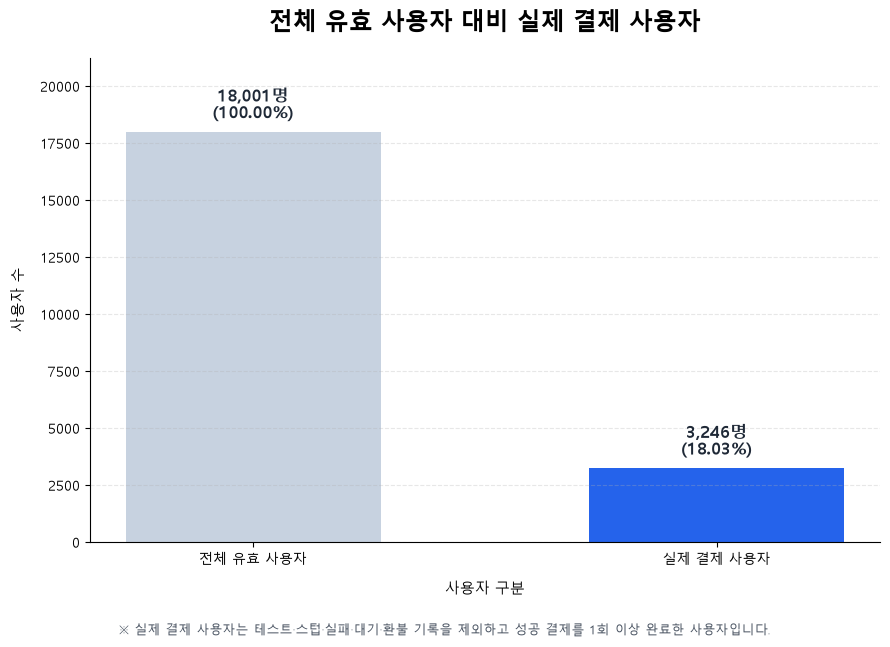

In [6]:
import platform
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 결과값 가져오기
# =========================================================

result = revenue_payer_df.iloc[0]

total_users = int(
    result["total_user_count"]
)

payer_users = int(
    result["payer_user_count"]
)

payer_rate = float(
    result["payer_conversion_rate_percent"]
)


# =========================================================
# 3. 막대그래프
# =========================================================

labels = [
    "전체 유효 사용자",
    "실제 결제 사용자"
]

values = [
    total_users,
    payer_users
]

rates = [
    100.0,
    payer_rate
]

colors = [
    "#C7D2E0",
    "#2563EB"
]

fig, ax = plt.subplots(
    figsize=(9, 6.5)
)

bars = ax.bar(
    labels,
    values,
    color=colors,
    width=0.55
)


# =========================================================
# 4. 데이터 라벨
# =========================================================

for bar, value, rate in zip(
    bars,
    values,
    rates
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total_users * 0.025,
        f"{value:,}명\n({rate:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="#1F2937"
    )


# =========================================================
# 5. 그래프 설정
# =========================================================

ax.set_title(
    "전체 유효 사용자 대비 실제 결제 사용자",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "사용자 구분",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "사용자 수",
    fontsize=11,
    labelpad=10
)

ax.set_ylim(
    0,
    total_users * 1.18
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.015,
    "※ 실제 결제 사용자는 테스트·스텁·실패·대기·환불 기록을 제외하고 성공 결제를 1회 이상 완료한 사용자입니다.",
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

## 가입 후 첫 결제까지 얼마나 걸리는가?

실제 성공 결제 중 사용자별 최초 결제 시각(`first_payment_at`)을 구하고, 가입 시각(`signup_at`)과의 차이를 시간·일 단위로 계산한다. 

가입 시각보다 이른 결제 기록은 `WHERE fp.first_payment_at >= vu.signup_at` 으로 제외한다.

In [7]:
# 가입 후 첫 결제까지 얼마나 걸리는가?
first_purchase_delay_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date
),

-- 탈퇴하지 않은 유효 가입자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.created_at AS signup_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 성공 결제
successful_payments AS (
  SELECT
    hp.user_id,
    hp.completed_at

  FROM `ping-v2-503916.raw.heart_purchase` AS hp

  INNER JOIN valid_users AS vu
    ON hp.user_id = vu.user_id

  CROSS JOIN params AS p

  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL
    AND hp.store_transaction_id IS NOT NULL

    -- 테스트·스텁 결제 제외
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )

    AND hp.price_krw > 0
    AND hp.heart_amount > 0

    AND DATE(
      hp.completed_at,
      'Asia/Seoul'
    ) BETWEEN p.analysis_start_date
          AND p.data_end_date
),

-- 사용자별 최초 성공 결제
first_payment AS (
  SELECT
    user_id,
    MIN(completed_at) AS first_payment_at

  FROM successful_payments
  GROUP BY user_id
)

SELECT
  vu.user_id,

  vu.signup_at,

  fp.first_payment_at,

  DATETIME(
    vu.signup_at,
    'Asia/Seoul'
  ) AS signup_datetime_kst,

  DATETIME(
    fp.first_payment_at,
    'Asia/Seoul'
  ) AS first_payment_datetime_kst,

  -- 가입 후 첫 결제까지 걸린 시간
  TIMESTAMP_DIFF(
    fp.first_payment_at,
    vu.signup_at,
    HOUR
  ) AS hours_to_first_purchase,

  -- 소수점 단위 일수
  ROUND(
    TIMESTAMP_DIFF(
      fp.first_payment_at,
      vu.signup_at,
      HOUR
    ) / 24.0,
    2
  ) AS days_to_first_purchase

FROM valid_users AS vu

INNER JOIN first_payment AS fp
  ON vu.user_id = fp.user_id

-- 가입보다 먼저 발생한 비정상 결제 기록 제외
WHERE fp.first_payment_at >= vu.signup_at

ORDER BY days_to_first_purchase
"""

In [8]:
cost(first_purchase_delay_sql)

예상 스캔량: 1.268 MiB
예상 스캔량: 0.001238 GiB
월 1 TiB 무료 용량의 약 0.00012090%


0.0012380601838231087

In [9]:
first_purchase_delay_df = (
    bq.query(first_purchase_delay_sql)
      .result()
      .to_dataframe()
)

first_purchase_delay_df.head()

,user_id,signup_at,first_payment_at,signup_datetime_kst,first_payment_datetime_kst,hours_to_first_purchase,days_to_first_purchase
0,17183,2026-05-16 18:33:49+00:00,2026-05-16 18:36:11+00:00,2026-05-17 03:33:49,2026-05-17 03:36:11,0,0.0
1,18889,2026-06-24 15:02:14+00:00,2026-06-24 15:46:42+00:00,2026-06-25 00:02:14,2026-06-25 00:46:42,0,0.0
2,19692,2026-07-15 20:42:44+00:00,2026-07-15 20:47:45+00:00,2026-07-16 05:42:44,2026-07-16 05:47:45,0,0.0
3,19761,2026-07-17 13:59:25+00:00,2026-07-17 14:16:38+00:00,2026-07-17 22:59:25,2026-07-17 23:16:38,0,0.0
4,19574,2026-07-12 11:27:39+00:00,2026-07-12 12:01:50+00:00,2026-07-12 20:27:39,2026-07-12 21:01:50,0,0.0


In [10]:
payer_count = len(
    first_purchase_delay_df
)

delay_days = first_purchase_delay_df[
    "days_to_first_purchase"
].dropna()

average_days = delay_days.mean()
median_days = delay_days.median()

p25_days = delay_days.quantile(0.25)
p75_days = delay_days.quantile(0.75)
p90_days = delay_days.quantile(0.90)

within_1day_count = (
    delay_days <= 1
).sum()

within_7days_count = (
    delay_days <= 7
).sum()

within_30days_count = (
    delay_days <= 30
).sum()

within_1day_rate = (
    within_1day_count / payer_count * 100
)

within_7days_rate = (
    within_7days_count / payer_count * 100
)

within_30days_rate = (
    within_30days_count / payer_count * 100
)

print("[가입 후 첫 결제 소요 기간]")
print(f"실제 결제 사용자: {payer_count:,}명")
print(
    f"첫 결제까지 평균 소요 기간: "
    f"{average_days:.2f}일"
)
print(
    f"첫 결제까지 중앙 소요 기간: "
    f"{median_days:.2f}일"
)
print(
    f"하위 25%는 {p25_days:.2f}일 이내, "
    f"75%는 {p75_days:.2f}일 이내, "
    f"90%는 {p90_days:.2f}일 이내에 첫 결제를 완료했습니다."
)
print()
print(
    f"가입 후 24시간 이내 결제: "
    f"{within_1day_count:,}명 "
    f"({within_1day_rate:.2f}%)"
)
print(
    f"가입 후 7일 이내 결제: "
    f"{within_7days_count:,}명 "
    f"({within_7days_rate:.2f}%)"
)
print(
    f"가입 후 30일 이내 결제: "
    f"{within_30days_count:,}명 "
    f"({within_30days_rate:.2f}%)"
)

[가입 후 첫 결제 소요 기간]
실제 결제 사용자: 3,246명
첫 결제까지 평균 소요 기간: 60.56일
첫 결제까지 중앙 소요 기간: 36.77일
하위 25%는 11.88일 이내, 75%는 86.81일 이내, 90%는 156.39일 이내에 첫 결제를 완료했습니다.

가입 후 24시간 이내 결제: 134명 (4.13%)
가입 후 7일 이내 결제: 563명 (17.34%)
가입 후 30일 이내 결제: 1,463명 (45.07%)


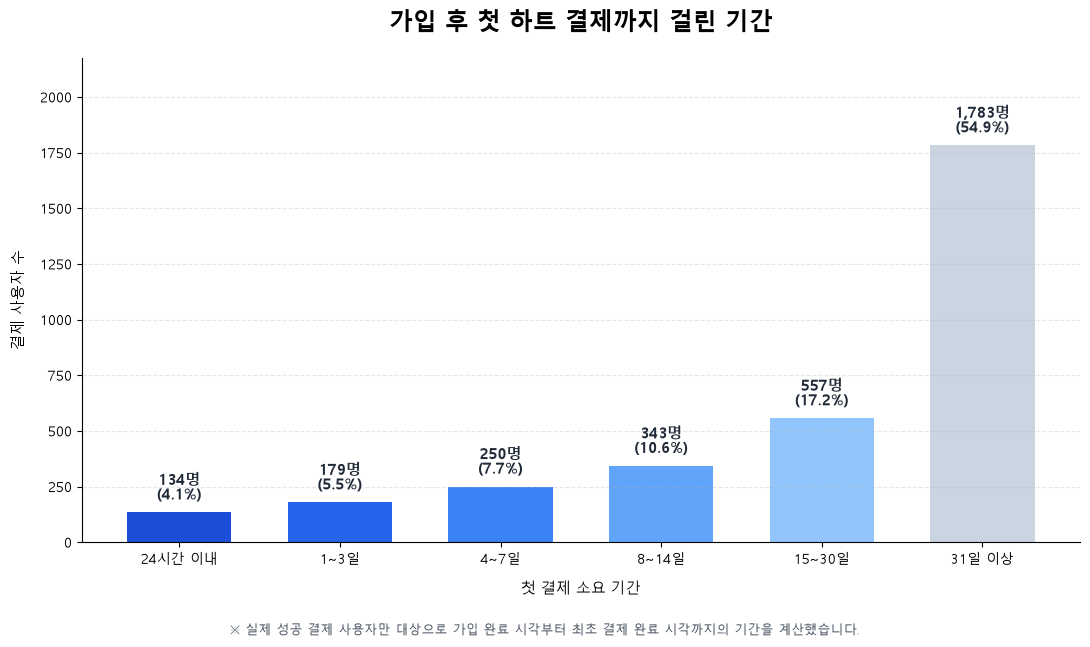

In [11]:
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 결제 소요 기간 구간 설정
# =========================================================

plot_df = first_purchase_delay_df.copy()

plot_df["days_to_first_purchase"] = pd.to_numeric(
    plot_df["days_to_first_purchase"],
    errors="coerce"
)

bins = [
    -0.001,
    1,
    3,
    7,
    14,
    30,
    np.inf
]

labels = [
    "24시간 이내",
    "1~3일",
    "4~7일",
    "8~14일",
    "15~30일",
    "31일 이상"
]

plot_df["purchase_delay_group"] = pd.cut(
    plot_df["days_to_first_purchase"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


# =========================================================
# 3. 구간별 사용자 집계
# =========================================================

delay_summary = (
    plot_df["purchase_delay_group"]
    .value_counts(sort=False)
    .reindex(labels, fill_value=0)
    .reset_index()
)

delay_summary.columns = [
    "purchase_delay_group",
    "payer_count"
]

total_payers = delay_summary[
    "payer_count"
].sum()

delay_summary["payer_rate_percent"] = (
    delay_summary["payer_count"]
    / total_payers
    * 100
)


# =========================================================
# 4. 막대그래프 생성
# =========================================================

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

colors = [
    "#1D4ED8",
    "#2563EB",
    "#3B82F6",
    "#60A5FA",
    "#93C5FD",
    "#CBD5E1"
]

bars = ax.bar(
    delay_summary["purchase_delay_group"],
    delay_summary["payer_count"],
    color=colors,
    width=0.65
)


# =========================================================
# 5. 데이터 라벨
# =========================================================

maximum_count = max(
    delay_summary["payer_count"].max(),
    1
)

for bar, count, rate in zip(
    bars,
    delay_summary["payer_count"],
    delay_summary["payer_rate_percent"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + maximum_count * 0.025,
        f"{int(count):,}명\n({rate:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color="#1F2937"
    )


# =========================================================
# 6. 그래프 설정
# =========================================================

ax.set_title(
    "가입 후 첫 하트 결제까지 걸린 기간",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "첫 결제 소요 기간",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "결제 사용자 수",
    fontsize=11,
    labelpad=10
)

ax.set_ylim(
    0,
    maximum_count * 1.22
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.015,
    "※ 실제 성공 결제 사용자만 대상으로 가입 완료 시각부터 최초 결제 완료 시각까지의 기간을 계산했습니다.",
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

## 어떤 행동을 많이 한 사용자가 결제로 이어지는가?

가입 후 첫 7일간의 앱 접속·친구 요청 발송·투표 세션·실제 투표·후보 셔플·받은 투표 열람·하트 힌트 구매·게시판 활동(글·댓글·좋아요) 횟수를 각각 집계한다. 

이를 0회부터 11회 이상까지 5개 구간으로 나눠, 구간별 8~30일차 결제 전환율과 결제자·비결제자의 평균 행동 횟수를 비교한다.

In [12]:
# 어떤 행동을 많이 한 사용자가 결제로 이어지는가?
behavior_to_purchase_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date
),

-- 탈퇴하지 않은 유효 가입자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.created_at AS signup_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 성공 결제
successful_payments AS (
  SELECT
    hp.user_id,
    hp.completed_at
  FROM `ping-v2-503916.raw.heart_purchase` AS hp
  INNER JOIN valid_users AS vu
    ON hp.user_id = vu.user_id
  CROSS JOIN params AS p
  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL
    AND hp.store_transaction_id IS NOT NULL
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )
    AND hp.price_krw > 0
    AND hp.heart_amount > 0
    AND DATE(hp.completed_at, 'Asia/Seoul')
        <= p.data_end_date
),

-- 사용자별 최초 결제
first_purchase AS (
  SELECT
    user_id,
    MIN(completed_at) AS first_purchase_at
  FROM successful_payments
  GROUP BY user_id
),

-- 가입 후 30일을 모두 관찰할 수 있는 사용자
-- 첫 7일 이내 결제자는 행동-결제 순서를 보장할 수 없어 제외
eligible_users AS (
  SELECT
    vu.user_id,
    vu.signup_at,
    fp.first_purchase_at,

    CASE
      WHEN fp.first_purchase_at
           >= TIMESTAMP_ADD(vu.signup_at, INTERVAL 7 DAY)
       AND fp.first_purchase_at
           < TIMESTAMP_ADD(vu.signup_at, INTERVAL 31 DAY)
      THEN 1
      ELSE 0
    END AS is_payer_30d

  FROM valid_users AS vu
  LEFT JOIN first_purchase AS fp
    ON vu.user_id = fp.user_id
  CROSS JOIN params AS p

  WHERE DATE(vu.signup_at, 'Asia/Seoul')
        BETWEEN p.analysis_start_date
        AND DATE_SUB(p.data_end_date, INTERVAL 30 DAY)

    AND (
      fp.first_purchase_at IS NULL
      OR fp.first_purchase_at
         >= TIMESTAMP_ADD(vu.signup_at, INTERVAL 7 DAY)
    )
),

-- 가입 후 첫 7일 앱 접속
session_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT us.id) AS app_session_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.user_session` AS us
    ON us.user_id = eu.user_id
   AND us.started_at >= eu.signup_at
   AND us.started_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE us._source = 'local'
    AND us._deleted_at IS NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 친구 요청 발송
friend_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT fr.id) AS friend_request_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.friend_request` AS fr
    ON fr.sender_id = eu.user_id
   AND fr.created_at >= eu.signup_at
   AND fr.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE fr._source = 'local'
    AND fr._deleted_at IS NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 실제 투표와 투표 세션
vote_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT vi.session_id) AS vote_session_count,
    COUNT(DISTINCT vi.id) AS vote_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.vote_item` AS vi
    ON vi.user_id = eu.user_id
   AND vi.voted_at >= eu.signup_at
   AND vi.voted_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 후보 셔플
shuffle_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT vs.id) AS shuffle_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.vote_item` AS vi
    ON vi.user_id = eu.user_id
  INNER JOIN `ping-v2-503916.raw.vote_shuffle` AS vs
    ON vs.vote_item_id = vi.id
   AND vs.created_at >= eu.signup_at
   AND vs.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vs._source = 'local'
    AND vs._deleted_at IS NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 받은 투표 열람
received_vote_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT vr.id) AS received_vote_read_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.vote_received` AS vr
    ON vr.receiver_id = eu.user_id
   AND vr.read_at >= eu.signup_at
   AND vr.read_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE vr._source = 'local'
    AND vr._deleted_at IS NULL
    AND vr.is_read = TRUE
    AND vr.read_at IS NOT NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 하트 힌트 구매
hint_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT hp.id) AS hint_purchase_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.hint_purchase` AS hp
    ON hp.user_id = eu.user_id
   AND hp.created_at >= eu.signup_at
   AND hp.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 게시판 활동
board_events AS (
  SELECT author_id AS user_id, created_at
  FROM `ping-v2-503916.raw.post`
  WHERE _source = 'local'
    AND _deleted_at IS NULL

  UNION ALL

  SELECT author_id AS user_id, created_at
  FROM `ping-v2-503916.raw.post_comment`
  WHERE _source = 'local'
    AND _deleted_at IS NULL

  UNION ALL

  SELECT user_id, created_at
  FROM `ping-v2-503916.raw.post_like`
  WHERE _source = 'local'
    AND _deleted_at IS NULL

  UNION ALL

  SELECT user_id, created_at
  FROM `ping-v2-503916.raw.comment_like`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

board_behavior AS (
  SELECT
    eu.user_id,
    COUNT(*) AS board_action_count
  FROM eligible_users AS eu
  INNER JOIN board_events AS be
    ON be.user_id = eu.user_id
   AND be.created_at >= eu.signup_at
   AND be.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  GROUP BY eu.user_id
),

-- 사용자별 행동 데이터 결합
behavior_features AS (
  SELECT
    eu.user_id,
    eu.is_payer_30d,

    COALESCE(sb.app_session_count, 0)
      AS app_session_count,

    COALESCE(fb.friend_request_count, 0)
      AS friend_request_count,

    COALESCE(vb.vote_session_count, 0)
      AS vote_session_count,

    COALESCE(vb.vote_count, 0)
      AS vote_count,

    COALESCE(shb.shuffle_count, 0)
      AS shuffle_count,

    COALESCE(rvb.received_vote_read_count, 0)
      AS received_vote_read_count,

    COALESCE(hb.hint_purchase_count, 0)
      AS hint_purchase_count,

    COALESCE(bb.board_action_count, 0)
      AS board_action_count

  FROM eligible_users AS eu
  LEFT JOIN session_behavior AS sb
    ON eu.user_id = sb.user_id
  LEFT JOIN friend_behavior AS fb
    ON eu.user_id = fb.user_id
  LEFT JOIN vote_behavior AS vb
    ON eu.user_id = vb.user_id
  LEFT JOIN shuffle_behavior AS shb
    ON eu.user_id = shb.user_id
  LEFT JOIN received_vote_behavior AS rvb
    ON eu.user_id = rvb.user_id
  LEFT JOIN hint_behavior AS hb
    ON eu.user_id = hb.user_id
  LEFT JOIN board_behavior AS bb
    ON eu.user_id = bb.user_id
),

-- 행동별 세로 형태로 변환
behavior_long AS (
  SELECT
    user_id,
    is_payer_30d,
    behavior_code,
    activity_count
  FROM behavior_features
  UNPIVOT (
    activity_count FOR behavior_code IN (
      app_session_count,
      friend_request_count,
      vote_session_count,
      vote_count,
      shuffle_count,
      received_vote_read_count,
      hint_purchase_count,
      board_action_count
    )
  )
),

-- 행동 횟수 구간화
behavior_bucketed AS (
  SELECT
    user_id,
    is_payer_30d,
    behavior_code,

    CASE behavior_code
      WHEN 'app_session_count' THEN '앱 접속'
      WHEN 'friend_request_count' THEN '친구 요청 발송'
      WHEN 'vote_session_count' THEN '투표 세션'
      WHEN 'vote_count' THEN '실제 투표'
      WHEN 'shuffle_count' THEN '후보 셔플'
      WHEN 'received_vote_read_count' THEN '받은 투표 열람'
      WHEN 'hint_purchase_count' THEN '하트 힌트 구매'
      WHEN 'board_action_count' THEN '게시판 활동'
    END AS behavior_name,

    activity_count,

    CASE
      WHEN activity_count = 0 THEN '0회'
      WHEN activity_count BETWEEN 1 AND 2 THEN '1~2회'
      WHEN activity_count BETWEEN 3 AND 5 THEN '3~5회'
      WHEN activity_count BETWEEN 6 AND 10 THEN '6~10회'
      ELSE '11회 이상'
    END AS activity_group,

    CASE
      WHEN activity_count = 0 THEN 0
      WHEN activity_count BETWEEN 1 AND 2 THEN 1
      WHEN activity_count BETWEEN 3 AND 5 THEN 2
      WHEN activity_count BETWEEN 6 AND 10 THEN 3
      ELSE 4
    END AS group_order

  FROM behavior_long
),

-- 행동 구간별 결제 전환율
bucket_summary AS (
  SELECT
    behavior_code,
    behavior_name,
    activity_group,
    group_order,
    COUNT(DISTINCT user_id) AS user_count,
    COUNT(DISTINCT IF(is_payer_30d = 1, user_id, NULL))
      AS payer_user_count,

    ROUND(
      SAFE_DIVIDE(
        COUNT(DISTINCT IF(is_payer_30d = 1, user_id, NULL)),
        COUNT(DISTINCT user_id)
      ) * 100,
      2
    ) AS purchase_conversion_rate_percent

  FROM behavior_bucketed
  GROUP BY
    behavior_code,
    behavior_name,
    activity_group,
    group_order
),

-- 결제자와 비결제자의 평균 행동량
behavior_comparison AS (
  SELECT
    behavior_code,

    ROUND(
      AVG(IF(is_payer_30d = 1, activity_count, NULL)),
      2
    ) AS payer_avg_count,

    ROUND(
      AVG(IF(is_payer_30d = 0, activity_count, NULL)),
      2
    ) AS non_payer_avg_count

  FROM behavior_bucketed
  GROUP BY behavior_code
)

SELECT
  bs.behavior_code,
  bs.behavior_name,
  bs.activity_group,
  bs.group_order,
  bs.user_count,
  bs.payer_user_count,
  bs.purchase_conversion_rate_percent,
  bc.payer_avg_count,
  bc.non_payer_avg_count,

  ROUND(
    SAFE_DIVIDE(
      bc.payer_avg_count,
      bc.non_payer_avg_count
    ),
    2
  ) AS payer_to_nonpayer_activity_ratio

FROM bucket_summary AS bs
LEFT JOIN behavior_comparison AS bc
  USING (behavior_code)

ORDER BY
  behavior_name,
  group_order
"""

In [13]:
cost(behavior_to_purchase_sql)

예상 스캔량: 1,037.481 MiB
예상 스캔량: 1.013165 GiB
월 1 TiB 무료 용량의 약 0.09894194%


1.013165457174182

In [14]:
behavior_purchase_df = (
    bq.query(behavior_to_purchase_sql)
      .result()
      .to_dataframe()
)

behavior_purchase_df.head(20)

,behavior_code,behavior_name,activity_group,group_order,user_count,payer_user_count,purchase_conversion_rate_percent,payer_avg_count,non_payer_avg_count,payer_to_nonpayer_activity_ratio
0,board_action_count,게시판 활동,0회,0,4730,243,5.14,7.11,6.98,1.02
1,board_action_count,게시판 활동,1~2회,1,3054,173,5.66,7.11,6.98,1.02
2,board_action_count,게시판 활동,3~5회,2,2627,136,5.18,7.11,6.98,1.02
3,board_action_count,게시판 활동,6~10회,3,2208,122,5.53,7.11,6.98,1.02
4,board_action_count,게시판 활동,11회 이상,4,3922,209,5.33,7.11,6.98,1.02
5,received_vote_read_count,받은 투표 열람,0회,0,3894,230,5.91,18.90,19.32,0.98
6,received_vote_read_count,받은 투표 열람,1~2회,1,2070,119,5.75,18.90,19.32,0.98
7,received_vote_read_count,받은 투표 열람,3~5회,2,1959,97,4.95,18.90,19.32,0.98
8,received_vote_read_count,받은 투표 열람,6~10회,3,2069,91,4.40,18.90,19.32,0.98
9,received_vote_read_count,받은 투표 열람,11회 이상,4,6549,346,5.28,18.90,19.32,0.98


In [15]:
first_behavior = behavior_purchase_df[
    "behavior_name"
].iloc[0]

base_df = behavior_purchase_df[
    behavior_purchase_df["behavior_name"] == first_behavior
]

analysis_user_count = int(
    base_df["user_count"].sum()
)

payer_user_count = int(
    base_df["payer_user_count"].sum()
)

overall_conversion_rate = (
    payer_user_count
    / analysis_user_count
    * 100
)

print("[첫 7일 행동과 후속 결제 분석]")
print(
    f"분석 대상 사용자: {analysis_user_count:,}명"
)
print(
    f"가입 7일 이후부터 30일 이내 결제 사용자: "
    f"{payer_user_count:,}명 "
    f"({overall_conversion_rate:.2f}%)"
)
print(
    "※ 첫 7일 이내 이미 결제한 사용자는 "
    "행동과 결제의 시간 순서를 지키기 위해 제외했습니다."
)

[첫 7일 행동과 후속 결제 분석]
분석 대상 사용자: 16,541명
가입 7일 이후부터 30일 이내 결제 사용자: 883명 (5.34%)
※ 첫 7일 이내 이미 결제한 사용자는 행동과 결제의 시간 순서를 지키기 위해 제외했습니다.


In [16]:
comparison_df = (
    behavior_purchase_df[
        [
            "behavior_name",
            "payer_avg_count",
            "non_payer_avg_count",
            "payer_to_nonpayer_activity_ratio"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "payer_to_nonpayer_activity_ratio",
        ascending=False
    )
)

print("\n[결제자와 비결제자의 첫 7일 평균 행동량]")

for _, row in comparison_df.iterrows():

    ratio = row[
        "payer_to_nonpayer_activity_ratio"
    ]

    ratio_text = (
        f"{ratio:.2f}배"
        if pd.notna(ratio)
        else "비교 불가"
    )

    print(
        f"{row['behavior_name']}: "
        f"결제자 평균 {row['payer_avg_count']:.2f}회, "
        f"비결제자 평균 {row['non_payer_avg_count']:.2f}회 "
        f"({ratio_text})"
    )


[결제자와 비결제자의 첫 7일 평균 행동량]
후보 셔플: 결제자 평균 29.22회, 비결제자 평균 16.56회 (1.76배)
실제 투표: 결제자 평균 118.56회, 비결제자 평균 75.59회 (1.57배)
투표 세션: 결제자 평균 13.53회, 비결제자 평균 8.81회 (1.54배)
앱 접속: 결제자 평균 9.48회, 비결제자 평균 7.42회 (1.28배)
하트 힌트 구매: 결제자 평균 7.11회, 비결제자 평균 6.34회 (1.12배)
친구 요청 발송: 결제자 평균 8.46회, 비결제자 평균 7.83회 (1.08배)
게시판 활동: 결제자 평균 7.11회, 비결제자 평균 6.98회 (1.02배)
받은 투표 열람: 결제자 평균 18.90회, 비결제자 평균 19.32회 (0.98배)


In [17]:
group_order = [
    "0회",
    "1~2회",
    "3~5회",
    "6~10회",
    "11회 이상"
]

print("\n[행동량별 결제 전환율]")

for behavior_name in comparison_df["behavior_name"]:

    temp = (
        behavior_purchase_df[
            behavior_purchase_df[
                "behavior_name"
            ] == behavior_name
        ]
        .set_index("activity_group")
        .reindex(group_order)
    )

    group_text = []

    for activity_group, row in temp.iterrows():

        if pd.isna(row["user_count"]):
            continue

        group_text.append(
            f"{activity_group} "
            f"{row['purchase_conversion_rate_percent']:.2f}%"
            f"(n={int(row['user_count']):,})"
        )

    print(
        f"{behavior_name}: "
        + " → ".join(group_text)
    )


[행동량별 결제 전환율]
후보 셔플: 0회 5.04%(n=5,718) → 1~2회 4.02%(n=3,683) → 3~5회 5.62%(n=2,330) → 6~10회 5.93%(n=1,333) → 11회 이상 6.82%(n=3,477)
실제 투표: 0회 5.58%(n=3,227) → 1~2회 4.93%(n=832) → 3~5회 4.92%(n=732) → 6~10회 4.77%(n=3,770) → 11회 이상 5.59%(n=7,980)
투표 세션: 0회 5.58%(n=3,227) → 1~2회 4.85%(n=6,986) → 3~5회 4.72%(n=2,142) → 6~10회 4.89%(n=1,371) → 11회 이상 6.96%(n=2,815)
앱 접속: 0회 4.67%(n=1,414) → 1~2회 5.21%(n=6,912) → 3~5회 4.55%(n=3,359) → 6~10회 5.34%(n=1,647) → 11회 이상 6.73%(n=3,209)
하트 힌트 구매: 0회 5.11%(n=8,266) → 1~2회 5.02%(n=1,774) → 3~5회 5.65%(n=1,610) → 6~10회 4.95%(n=1,476) → 11회 이상 6.09%(n=3,415)
친구 요청 발송: 0회 4.79%(n=1,002) → 1~2회 6.12%(n=2,060) → 3~5회 4.35%(n=3,931) → 6~10회 4.91%(n=5,789) → 11회 이상 6.76%(n=3,759)
게시판 활동: 0회 5.14%(n=4,730) → 1~2회 5.66%(n=3,054) → 3~5회 5.18%(n=2,627) → 6~10회 5.53%(n=2,208) → 11회 이상 5.33%(n=3,922)
받은 투표 열람: 0회 5.91%(n=3,894) → 1~2회 5.75%(n=2,070) → 3~5회 4.95%(n=1,959) → 6~10회 4.40%(n=2,069) → 11회 이상 5.28%(n=6,549)


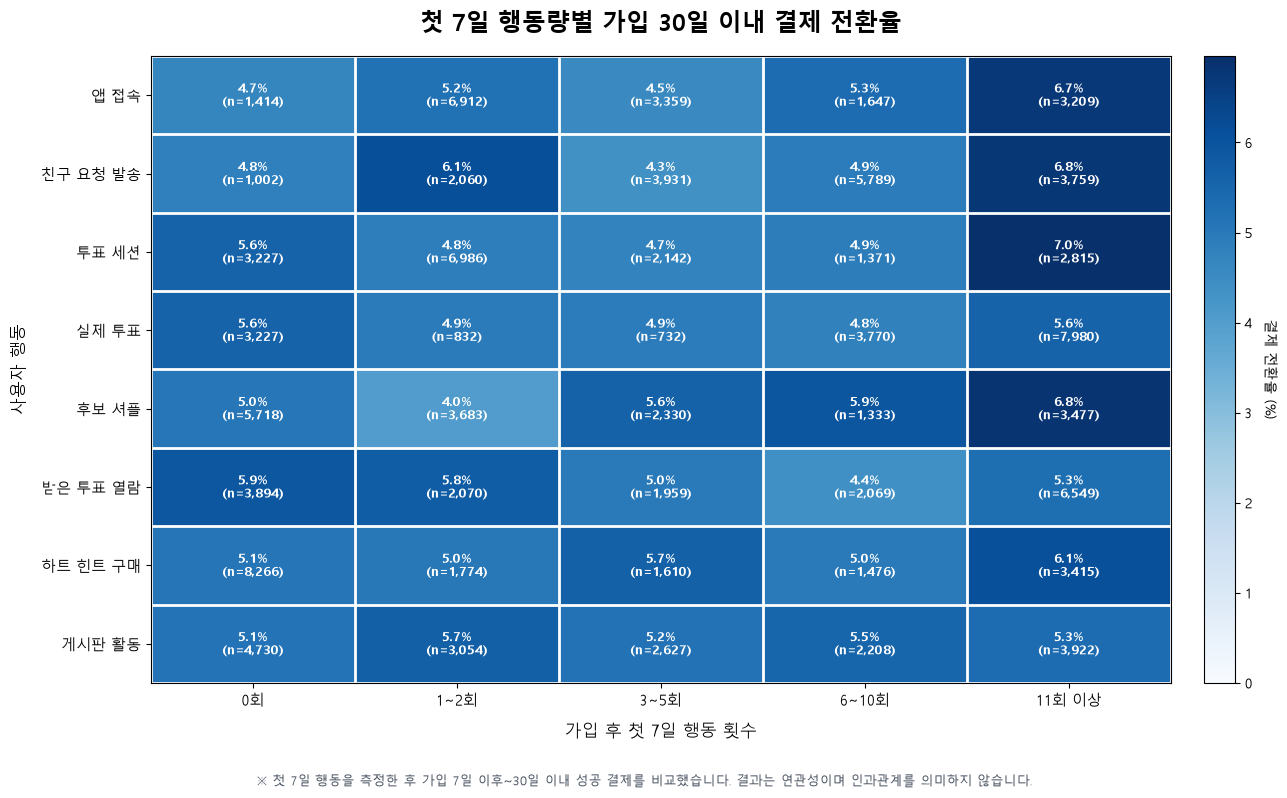

In [18]:
import platform
from copy import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 히트맵 데이터
# =========================================================

activity_order = [
    "0회",
    "1~2회",
    "3~5회",
    "6~10회",
    "11회 이상"
]

behavior_order = [
    "앱 접속",
    "친구 요청 발송",
    "투표 세션",
    "실제 투표",
    "후보 셔플",
    "받은 투표 열람",
    "하트 힌트 구매",
    "게시판 활동"
]

heatmap_df = (
    behavior_purchase_df
    .pivot_table(
        index="behavior_name",
        columns="activity_group",
        values="purchase_conversion_rate_percent",
        aggfunc="first"
    )
    .reindex(
        index=behavior_order,
        columns=activity_order
    )
)

count_df = (
    behavior_purchase_df
    .pivot_table(
        index="behavior_name",
        columns="activity_group",
        values="user_count",
        aggfunc="first"
    )
    .reindex(
        index=behavior_order,
        columns=activity_order
    )
)

heatmap_df = heatmap_df.apply(
    pd.to_numeric,
    errors="coerce"
)

count_df = count_df.apply(
    pd.to_numeric,
    errors="coerce"
)

heatmap_values = heatmap_df.to_numpy(dtype=float)
count_values = count_df.to_numpy(dtype=float)

masked_values = np.ma.masked_invalid(
    heatmap_values
)


# =========================================================
# 3. 색상
# =========================================================

cmap = copy(plt.cm.Blues)
cmap.set_bad(color="#E5E7EB")

maximum_rate = np.nanmax(heatmap_values)

if not np.isfinite(maximum_rate):
    maximum_rate = 1


# =========================================================
# 4. 시각화
# =========================================================

fig, ax = plt.subplots(
    figsize=(13, 8)
)

image = ax.imshow(
    masked_values,
    cmap=cmap,
    vmin=0,
    vmax=max(maximum_rate, 1),
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(activity_order))
)
ax.set_xticklabels(
    activity_order,
    fontsize=11
)

ax.set_yticks(
    np.arange(len(behavior_order))
)
ax.set_yticklabels(
    behavior_order,
    fontsize=11
)

ax.set_xlabel(
    "가입 후 첫 7일 행동 횟수",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "사용자 행동",
    fontsize=12,
    labelpad=10
)

ax.set_title(
    "첫 7일 행동량별 가입 30일 이내 결제 전환율",
    fontsize=17,
    fontweight="bold",
    pad=18
)


# 셀 경계선
ax.set_xticks(
    np.arange(-0.5, len(activity_order), 1),
    minor=True
)
ax.set_yticks(
    np.arange(-0.5, len(behavior_order), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)


# 셀 값 표시
for row_idx in range(len(behavior_order)):
    for col_idx in range(len(activity_order)):

        rate = heatmap_values[
            row_idx,
            col_idx
        ]

        count = count_values[
            row_idx,
            col_idx
        ]

        if np.isnan(rate):
            label = "–"
            text_color = "#6B7280"
        else:
            label = (
                f"{rate:.1f}%\n"
                f"(n={int(count):,})"
            )

            text_color = (
                "white"
                if rate >= maximum_rate * 0.55
                else "#111827"
            )

        ax.text(
            col_idx,
            row_idx,
            label,
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color=text_color
        )


# 컬러바
colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.03
)

colorbar.set_label(
    "결제 전환율 (%)",
    rotation=270,
    labelpad=18
)

fig.text(
    0.5,
    0.012,
    "※ 첫 7일 행동을 측정한 후 가입 7일 이후~30일 이내 성공 결제를 비교했습니다. 결과는 연관성이며 인과관계를 의미하지 않습니다.",
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

## 힌트 구매나 하트 부족 경험이 결제와 관련 있는가?

첫 7일간 유료 힌트 구매 여부와 하트 잔액이 200 미만으로 떨어진 적이 있는지를 각각 0/1 로 표시해,

힌트 구매×저잔액 경험 조합으로 4개 집단(`user_group`)을 나눈다. 

힌트 구매도 저잔액 경험도 없는 집단을 기준으로 삼아 각 집단의 결제 전환율 차이와 배율을 계산한다.

In [19]:
# 힌트 구매나 하트 부족 경험이 결제와 관련 있는가?
hint_balance_purchase_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date,
    200 AS minimum_hint_cost
),

-- 탈퇴하지 않은 유효 가입자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.created_at AS signup_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 성공 결제
successful_payments AS (
  SELECT
    hp.user_id,
    hp.completed_at
  FROM `ping-v2-503916.raw.heart_purchase` AS hp
  INNER JOIN valid_users AS vu
    ON hp.user_id = vu.user_id
  CROSS JOIN params AS p
  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL
    AND hp.store_transaction_id IS NOT NULL
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )
    AND hp.price_krw > 0
    AND hp.heart_amount > 0
    AND DATE(hp.completed_at, 'Asia/Seoul')
        <= p.data_end_date
),

-- 사용자별 최초 성공 결제
first_purchase AS (
  SELECT
    user_id,
    MIN(completed_at) AS first_purchase_at
  FROM successful_payments
  GROUP BY user_id
),

-- D30까지 관찰 가능한 사용자
-- 첫 7일 이내 결제자는 제외
eligible_users AS (
  SELECT
    vu.user_id,
    vu.signup_at,
    fp.first_purchase_at,

    CASE
      WHEN fp.first_purchase_at
           >= TIMESTAMP_ADD(vu.signup_at, INTERVAL 7 DAY)
       AND fp.first_purchase_at
           < TIMESTAMP_ADD(vu.signup_at, INTERVAL 31 DAY)
      THEN 1
      ELSE 0
    END AS is_payer_30d

  FROM valid_users AS vu
  LEFT JOIN first_purchase AS fp
    ON vu.user_id = fp.user_id
  CROSS JOIN params AS p

  WHERE DATE(vu.signup_at, 'Asia/Seoul')
        BETWEEN p.analysis_start_date
        AND DATE_SUB(p.data_end_date, INTERVAL 30 DAY)

    AND (
      fp.first_purchase_at IS NULL
      OR fp.first_purchase_at
         >= TIMESTAMP_ADD(vu.signup_at, INTERVAL 7 DAY)
    )
),

-- 가입 후 첫 7일 유료 힌트 구매
hint_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT hp.id) AS hint_purchase_count,
    SUM(hp.heart_cost) AS total_hint_heart_spent

  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.hint_purchase` AS hp
    ON hp.user_id = eu.user_id
   AND hp.created_at >= eu.signup_at
   AND hp.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)

  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL

    -- 광고로 무료 해금한 힌트가 있다면 제외
    AND hp.heart_cost > 0

  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 하트 잔액 상태
heart_balance_behavior AS (
  SELECT
    eu.user_id,

    MIN(ht.balance_after) AS minimum_balance,

    COUNTIF(
      ht.balance_after < p.minimum_hint_cost
    ) AS low_balance_event_count

  FROM eligible_users AS eu

  INNER JOIN `ping-v2-503916.raw.heart_transaction` AS ht
    ON ht.user_id = eu.user_id
   AND ht.created_at >= eu.signup_at
   AND ht.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)

  CROSS JOIN params AS p

  WHERE ht._source = 'local'
    AND ht._deleted_at IS NULL

  GROUP BY eu.user_id
),

-- 사용자별 특징 결합
user_features AS (
  SELECT
    eu.user_id,
    eu.is_payer_30d,

    COALESCE(
      hb.hint_purchase_count,
      0
    ) AS hint_purchase_count,

    COALESCE(
      hb.total_hint_heart_spent,
      0
    ) AS total_hint_heart_spent,

    hbb.minimum_balance,

    COALESCE(
      hbb.low_balance_event_count,
      0
    ) AS low_balance_event_count,

    CASE
      WHEN COALESCE(hb.hint_purchase_count, 0) > 0
      THEN 1
      ELSE 0
    END AS has_hint_purchase,

    CASE
      WHEN COALESCE(hbb.low_balance_event_count, 0) > 0
      THEN 1
      ELSE 0
    END AS has_low_balance_proxy

  FROM eligible_users AS eu
  LEFT JOIN hint_behavior AS hb
    ON eu.user_id = hb.user_id
  LEFT JOIN heart_balance_behavior AS hbb
    ON eu.user_id = hbb.user_id
),

-- 힌트 구매 여부 × 저잔액 여부로 네 집단 구성
user_groups AS (
  SELECT
    *,

    CASE
      WHEN has_hint_purchase = 0
       AND has_low_balance_proxy = 0
        THEN '힌트 없음·저잔액 없음'

      WHEN has_hint_purchase = 1
       AND has_low_balance_proxy = 0
        THEN '힌트 구매·저잔액 없음'

      WHEN has_hint_purchase = 0
       AND has_low_balance_proxy = 1
        THEN '힌트 없음·저잔액 있음'

      WHEN has_hint_purchase = 1
       AND has_low_balance_proxy = 1
        THEN '힌트 구매·저잔액 있음'
    END AS user_group,

    CASE
      WHEN has_hint_purchase = 0
       AND has_low_balance_proxy = 0 THEN 0

      WHEN has_hint_purchase = 1
       AND has_low_balance_proxy = 0 THEN 1

      WHEN has_hint_purchase = 0
       AND has_low_balance_proxy = 1 THEN 2

      WHEN has_hint_purchase = 1
       AND has_low_balance_proxy = 1 THEN 3
    END AS group_order

  FROM user_features
),

group_summary AS (
  SELECT
    user_group,
    group_order,

    COUNT(DISTINCT user_id) AS user_count,

    COUNT(
      DISTINCT IF(
        is_payer_30d = 1,
        user_id,
        NULL
      )
    ) AS payer_user_count,

    ROUND(
      SAFE_DIVIDE(
        COUNT(
          DISTINCT IF(
            is_payer_30d = 1,
            user_id,
            NULL
          )
        ),
        COUNT(DISTINCT user_id)
      ) * 100,
      2
    ) AS purchase_conversion_rate_percent,

    ROUND(
      AVG(hint_purchase_count),
      2
    ) AS avg_hint_purchase_count,

    ROUND(
      AVG(total_hint_heart_spent),
      2
    ) AS avg_hint_heart_spent,

    ROUND(
      AVG(minimum_balance),
      2
    ) AS avg_minimum_balance

  FROM user_groups

  GROUP BY
    user_group,
    group_order
),

-- 힌트도 없고 저잔액도 없는 집단을 기준으로 사용
reference_group AS (
  SELECT
    purchase_conversion_rate_percent
      AS reference_conversion_rate
  FROM group_summary
  WHERE group_order = 0
)

SELECT
  gs.user_group,
  gs.group_order,
  gs.user_count,
  gs.payer_user_count,
  gs.purchase_conversion_rate_percent,
  gs.avg_hint_purchase_count,
  gs.avg_hint_heart_spent,
  gs.avg_minimum_balance,

  ROUND(
    gs.purchase_conversion_rate_percent
    - rg.reference_conversion_rate,
    2
  ) AS conversion_difference_percent_point,

  ROUND(
    SAFE_DIVIDE(
      gs.purchase_conversion_rate_percent,
      rg.reference_conversion_rate
    ),
    2
  ) AS conversion_rate_ratio

FROM group_summary AS gs
CROSS JOIN reference_group AS rg

ORDER BY gs.group_order
"""

In [20]:
cost(hint_balance_purchase_sql)

예상 스캔량: 593.218 MiB
예상 스캔량: 0.579314 GiB
월 1 TiB 무료 용량의 약 0.05657365%


0.5793141378089786

In [21]:
hint_balance_purchase_df = (
    bq.query(hint_balance_purchase_sql)
      .result()
      .to_dataframe()
)

hint_balance_purchase_df

,user_group,group_order,user_count,payer_user_count,purchase_conversion_rate_percent,avg_hint_purchase_count,avg_hint_heart_spent,avg_minimum_balance,conversion_difference_percent_point,conversion_rate_ratio
0,힌트 없음·저잔액 없음,0,8320,425,5.11,0.00,0.00,403.89,0.00,1.00
1,힌트 구매·저잔액 없음,1,5299,281,5.30,5.44,111.96,356.88,0.19,1.04
2,힌트 없음·저잔액 있음,2,2,0,0.00,0.00,0.00,28.00,-5.11,0.00
3,힌트 구매·저잔액 있음,3,2920,177,6.06,22.98,479.91,53.95,0.95,1.19


In [22]:
analysis_user_count = int(
    hint_balance_purchase_df[
        "user_count"
    ].sum()
)

payer_user_count = int(
    hint_balance_purchase_df[
        "payer_user_count"
    ].sum()
)

overall_conversion_rate = (
    payer_user_count
    / analysis_user_count
    * 100
)

print("[힌트 구매·저잔액 상태와 후속 결제]")
print(
    f"분석 대상 사용자: "
    f"{analysis_user_count:,}명"
)
print(
    f"가입 7일 이후~30일 이내 결제 사용자: "
    f"{payer_user_count:,}명 "
    f"({overall_conversion_rate:.2f}%)"
)
print("-" * 75)

for _, row in (
    hint_balance_purchase_df
    .sort_values("group_order")
    .iterrows()
):
    print(
        f"{row['user_group']}: "
        f"{int(row['user_count']):,}명 중 "
        f"{int(row['payer_user_count']):,}명 결제 "
        f"({row['purchase_conversion_rate_percent']:.2f}%) | "
        f"기준 집단 대비 "
        f"{row['conversion_difference_percent_point']:+.2f}%p"
    )

[힌트 구매·저잔액 상태와 후속 결제]
분석 대상 사용자: 16,541명
가입 7일 이후~30일 이내 결제 사용자: 883명 (5.34%)
---------------------------------------------------------------------------
힌트 없음·저잔액 없음: 8,320명 중 425명 결제 (5.11%) | 기준 집단 대비 +0.00%p
힌트 구매·저잔액 없음: 5,299명 중 281명 결제 (5.30%) | 기준 집단 대비 +0.19%p
힌트 없음·저잔액 있음: 2명 중 0명 결제 (0.00%) | 기준 집단 대비 -5.11%p
힌트 구매·저잔액 있음: 2,920명 중 177명 결제 (6.06%) | 기준 집단 대비 +0.95%p


In [23]:
valid_result = hint_balance_purchase_df[
    hint_balance_purchase_df["user_count"] >= 30
].copy()

top_group = valid_result.loc[
    valid_result[
        "purchase_conversion_rate_percent"
    ].idxmax()
]

print()
print(
    f"결제 전환율이 가장 높은 집단은 "
    f"'{top_group['user_group']}'이며, "
    f"전환율은 "
    f"{top_group['purchase_conversion_rate_percent']:.2f}%입니다."
)


결제 전환율이 가장 높은 집단은 '힌트 구매·저잔액 있음'이며, 전환율은 6.06%입니다.


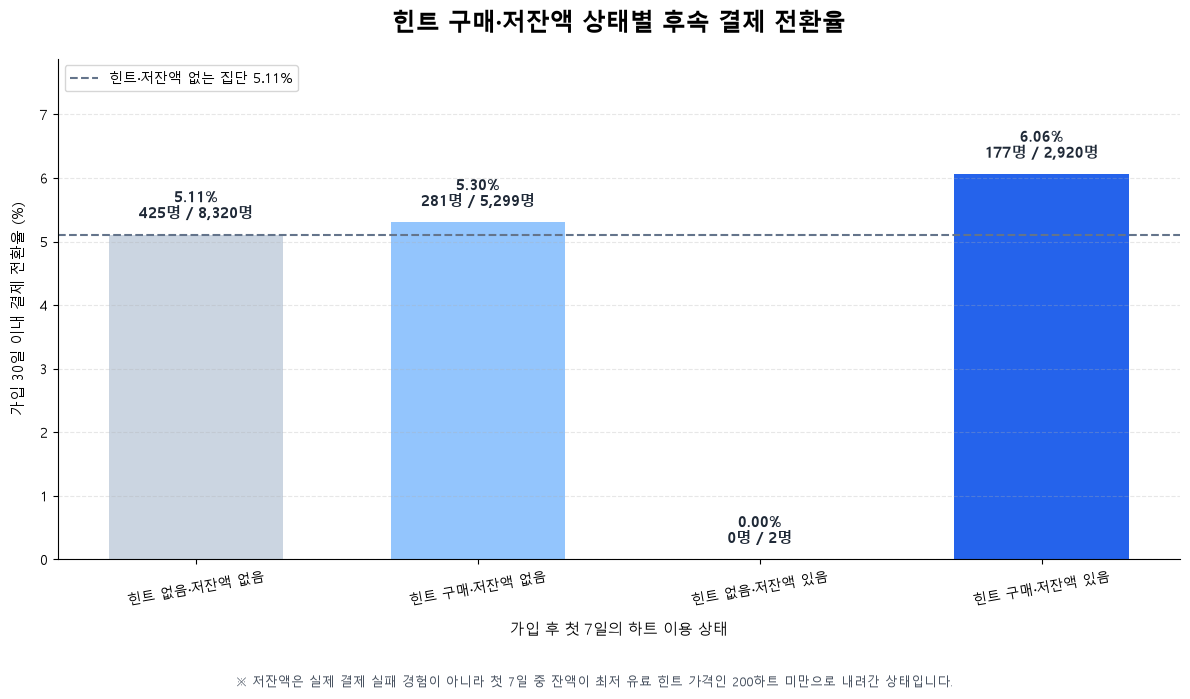

In [24]:
import platform
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 시각화 데이터
# =========================================================

plot_df = (
    hint_balance_purchase_df
    .sort_values("group_order")
    .copy()
)

labels = plot_df["user_group"].tolist()

values = plot_df[
    "purchase_conversion_rate_percent"
].tolist()

user_counts = plot_df[
    "user_count"
].tolist()

payer_counts = plot_df[
    "payer_user_count"
].tolist()

colors = [
    "#CBD5E1",
    "#93C5FD",
    "#60A5FA",
    "#2563EB"
]


# =========================================================
# 3. 막대그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

bars = ax.bar(
    labels,
    values,
    color=colors[:len(labels)],
    width=0.62
)

maximum_rate = max(
    max(values),
    1
)


# =========================================================
# 4. 데이터 라벨
# =========================================================

for bar, rate, user_count, payer_count in zip(
    bars,
    values,
    user_counts,
    payer_counts
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + maximum_rate * 0.035,
        (
            f"{rate:.2f}%\n"
            f"{int(payer_count):,}명 / "
            f"{int(user_count):,}명"
        ),
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color="#1F2937"
    )


# 기준 집단 전환율
reference_rate = float(
    plot_df.loc[
        plot_df["group_order"] == 0,
        "purchase_conversion_rate_percent"
    ].iloc[0]
)

ax.axhline(
    reference_rate,
    color="#64748B",
    linestyle="--",
    linewidth=1.5,
    label=(
        "힌트·저잔액 없는 집단 "
        f"{reference_rate:.2f}%"
    )
)


# =========================================================
# 5. 그래프 설정
# =========================================================

ax.set_title(
    "힌트 구매·저잔액 상태별 후속 결제 전환율",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "가입 후 첫 7일의 하트 이용 상태",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "가입 30일 이내 결제 전환율 (%)",
    fontsize=11,
    labelpad=10
)

ax.set_ylim(
    0,
    maximum_rate * 1.3
)

ax.tick_params(
    axis="x",
    labelrotation=10
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.012,
    "※ 저잔액은 실제 결제 실패 경험이 아니라 첫 7일 중 잔액이 최저 유료 힌트 가격인 200하트 미만으로 내려간 상태입니다.",
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

plt.show()

## 결제 사용자는 비결제 사용자보다 리텐션이 높은가?

최초 실제 투표 이후 결제 이력 유무로 결제·비결제 사용자를 나누고,

최초 투표 세션이 아닌 다른 세션에서 발생한 재투표를 W1~W4(1~7일·8~14일·15~21일·22~28일) 구간별로 리텐션 여부로 집계해 두 집단의 리텐션율 차이와 배율을 비교한다.

In [25]:
# 결제 사용자는 비결제 사용자보다 리텐션이 높은가?
payer_retention_sql = """
WITH
params AS (
  SELECT
    DATE '2026-07-23' AS data_end_date
),

retention_periods AS (
  SELECT 1 AS period_order, 'W1' AS retention_period,
         1 AS start_day, 7 AS end_day
  UNION ALL
  SELECT 2, 'W2', 8, 14
  UNION ALL
  SELECT 3, 'W3', 15, 21
  UNION ALL
  SELECT 4, 'W4', 22, 28
),

-- 탈퇴하지 않았고 친구 5명을 확보한 사용자
valid_unlocked_users AS (
  SELECT
    u.id AS user_id,
    u.created_at AS signup_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 투표
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at,
    DATE(vi.voted_at, 'Asia/Seoul') AS vote_date
  FROM `ping-v2-503916.raw.vote_item` AS vi
  INNER JOIN valid_unlocked_users AS vu
    ON vi.user_id = vu.user_id
  CROSS JOIN params AS p
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
    AND DATE(vi.voted_at, 'Asia/Seoul')
        <= p.data_end_date
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    voted_at AS first_vote_at,
    vote_date AS first_vote_date,
    session_id AS first_session_id
  FROM actual_votes
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY user_id
    ORDER BY voted_at, session_id
  ) = 1
),

-- 실제 결제 사용자
payer_users AS (
  SELECT DISTINCT
    hp.user_id
  FROM `ping-v2-503916.raw.heart_purchase` AS hp
  INNER JOIN valid_unlocked_users AS vu
    ON hp.user_id = vu.user_id
  CROSS JOIN params AS p
  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL
    AND hp.completed_at >= vu.signup_at
    AND DATE(hp.completed_at, 'Asia/Seoul')
        <= p.data_end_date
    AND hp.store_transaction_id IS NOT NULL
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )
    AND hp.price_krw > 0
    AND hp.heart_amount > 0
),

-- 활성화 사용자에게 결제 여부 부여
activated_users AS (
  SELECT
    fv.user_id,
    fv.first_vote_at,
    fv.first_vote_date,
    fv.first_session_id,

    CASE
      WHEN pu.user_id IS NOT NULL THEN '결제 사용자'
      ELSE '비결제 사용자'
    END AS payer_status,

    CASE
      WHEN pu.user_id IS NOT NULL THEN 1
      ELSE 0
    END AS is_payer

  FROM first_vote AS fv
  LEFT JOIN payer_users AS pu
    ON fv.user_id = pu.user_id
),

-- 최초 투표와 다른 세션에서 발생한 재투표
return_votes AS (
  SELECT DISTINCT
    au.user_id,

    DATE_DIFF(
      av.vote_date,
      au.first_vote_date,
      DAY
    ) AS days_after_first_vote

  FROM activated_users AS au
  INNER JOIN actual_votes AS av
    ON av.user_id = au.user_id

    -- 최초 투표 세션의 연속 투표 제외
    AND av.session_id != au.first_session_id

    -- 최초 투표 다음 날 이후만 재투표로 인정
    AND av.vote_date > au.first_vote_date

    AND DATE_DIFF(
          av.vote_date,
          au.first_vote_date,
          DAY
        ) BETWEEN 1 AND 28
),

-- 해당 주차까지 관찰할 수 있는 사용자만 포함
eligible_user_period AS (
  SELECT
    au.user_id,
    au.payer_status,
    au.is_payer,
    au.first_vote_date,
    rp.period_order,
    rp.retention_period,
    rp.start_day,
    rp.end_day

  FROM activated_users AS au
  CROSS JOIN retention_periods AS rp
  CROSS JOIN params AS p

  WHERE au.first_vote_date
        <= DATE_SUB(
          p.data_end_date,
          INTERVAL rp.end_day DAY
        )
),

-- 사용자별 기간 리텐션 여부
user_retention AS (
  SELECT
    eup.user_id,
    eup.payer_status,
    eup.is_payer,
    eup.period_order,
    eup.retention_period,
    eup.start_day,
    eup.end_day,

    CASE
      WHEN COUNTIF(
        rv.days_after_first_vote
        BETWEEN eup.start_day AND eup.end_day
      ) > 0
      THEN 1
      ELSE 0
    END AS is_retained

  FROM eligible_user_period AS eup
  LEFT JOIN return_votes AS rv
    ON rv.user_id = eup.user_id
   AND rv.days_after_first_vote
       BETWEEN eup.start_day AND eup.end_day

  GROUP BY
    eup.user_id,
    eup.payer_status,
    eup.is_payer,
    eup.period_order,
    eup.retention_period,
    eup.start_day,
    eup.end_day
),

-- 결제 여부별 리텐션
group_summary AS (
  SELECT
    period_order,
    retention_period,
    payer_status,
    is_payer,

    COUNT(DISTINCT user_id)
      AS eligible_user_count,

    COUNT(
      DISTINCT IF(
        is_retained = 1,
        user_id,
        NULL
      )
    ) AS retained_user_count,

    ROUND(
      SAFE_DIVIDE(
        COUNT(
          DISTINCT IF(
            is_retained = 1,
            user_id,
            NULL
          )
        ),
        COUNT(DISTINCT user_id)
      ) * 100,
      2
    ) AS retention_rate_percent

  FROM user_retention
  GROUP BY
    period_order,
    retention_period,
    payer_status,
    is_payer
),

-- 기간별 결제자와 비결제자 차이
period_comparison AS (
  SELECT
    period_order,
    retention_period,

    MAX(
      IF(
        is_payer = 1,
        retention_rate_percent,
        NULL
      )
    ) AS payer_retention_rate,

    MAX(
      IF(
        is_payer = 0,
        retention_rate_percent,
        NULL
      )
    ) AS non_payer_retention_rate

  FROM group_summary
  GROUP BY
    period_order,
    retention_period
)

SELECT
  gs.period_order,
  gs.retention_period,
  gs.payer_status,
  gs.is_payer,
  gs.eligible_user_count,
  gs.retained_user_count,
  gs.retention_rate_percent,

  ROUND(
    pc.payer_retention_rate
    - pc.non_payer_retention_rate,
    2
  ) AS payer_difference_percent_point,

  ROUND(
    SAFE_DIVIDE(
      pc.payer_retention_rate,
      pc.non_payer_retention_rate
    ),
    2
  ) AS payer_to_nonpayer_retention_ratio

FROM group_summary AS gs
INNER JOIN period_comparison AS pc
  USING (
    period_order,
    retention_period
  )

ORDER BY
  gs.period_order,
  gs.is_payer DESC
"""

In [26]:
cost(payer_retention_sql)

예상 스캔량: 395.110 MiB
예상 스캔량: 0.385849 GiB
월 1 TiB 무료 용량의 약 0.03768061%


0.38584946375340223

In [27]:
payer_retention_df = (
    bq.query(payer_retention_sql)
      .result()
      .to_dataframe()
)

payer_retention_df

,period_order,retention_period,payer_status,is_payer,eligible_user_count,retained_user_count,retention_rate_percent,payer_difference_percent_point,payer_to_nonpayer_retention_ratio
0,1,W1,결제 사용자,1,2683,1709,63.70,8.61,1.16
1,1,W1,비결제 사용자,0,11978,6599,55.09,8.61,1.16
2,2,W2,결제 사용자,1,2654,1157,43.59,9.72,1.29
3,2,W2,비결제 사용자,0,11799,3996,33.87,9.72,1.29
4,3,W3,결제 사용자,1,2620,917,35.00,8.21,1.31
5,3,W3,비결제 사용자,0,11630,3116,26.79,8.21,1.31
6,4,W4,결제 사용자,1,2592,723,27.89,8.20,1.42
7,4,W4,비결제 사용자,0,11465,2257,19.69,8.20,1.42


In [28]:
print("[결제 사용자와 비결제 사용자의 투표 리텐션 비교]")
print(
    "기준: 최초 실제 투표 후 다른 투표 세션에서 "
    "해당 주차에 한 번 이상 재투표"
)
print("-" * 80)

for period in ["W1", "W2", "W3", "W4"]:

    period_df = payer_retention_df[
        payer_retention_df[
            "retention_period"
        ] == period
    ]

    payer_row = period_df[
        period_df["payer_status"] == "결제 사용자"
    ].iloc[0]

    non_payer_row = period_df[
        period_df["payer_status"] == "비결제 사용자"
    ].iloc[0]

    difference = float(
        payer_row[
            "payer_difference_percent_point"
        ]
    )

    ratio = float(
        payer_row[
            "payer_to_nonpayer_retention_ratio"
        ]
    )

    print(f"[{period}]")
    print(
        f"결제 사용자: "
        f"{int(payer_row['retained_user_count']):,}명 / "
        f"{int(payer_row['eligible_user_count']):,}명 "
        f"({payer_row['retention_rate_percent']:.2f}%)"
    )
    print(
        f"비결제 사용자: "
        f"{int(non_payer_row['retained_user_count']):,}명 / "
        f"{int(non_payer_row['eligible_user_count']):,}명 "
        f"({non_payer_row['retention_rate_percent']:.2f}%)"
    )
    print(
        f"결제 사용자가 비결제 사용자보다 "
        f"{difference:+.2f}%p, "
        f"{ratio:.2f}배 높습니다."
    )
    print()

[결제 사용자와 비결제 사용자의 투표 리텐션 비교]
기준: 최초 실제 투표 후 다른 투표 세션에서 해당 주차에 한 번 이상 재투표
--------------------------------------------------------------------------------
[W1]
결제 사용자: 1,709명 / 2,683명 (63.70%)
비결제 사용자: 6,599명 / 11,978명 (55.09%)
결제 사용자가 비결제 사용자보다 +8.61%p, 1.16배 높습니다.

[W2]
결제 사용자: 1,157명 / 2,654명 (43.59%)
비결제 사용자: 3,996명 / 11,799명 (33.87%)
결제 사용자가 비결제 사용자보다 +9.72%p, 1.29배 높습니다.

[W3]
결제 사용자: 917명 / 2,620명 (35.00%)
비결제 사용자: 3,116명 / 11,630명 (26.79%)
결제 사용자가 비결제 사용자보다 +8.21%p, 1.31배 높습니다.

[W4]
결제 사용자: 723명 / 2,592명 (27.89%)
비결제 사용자: 2,257명 / 11,465명 (19.69%)
결제 사용자가 비결제 사용자보다 +8.20%p, 1.42배 높습니다.



In [29]:
comparison_df = (
    payer_retention_df[
        payer_retention_df["is_payer"] == 1
    ]
    .sort_values("period_order")
)

all_higher = (
    comparison_df[
        "payer_difference_percent_point"
    ] > 0
).all()

average_difference = (
    comparison_df[
        "payer_difference_percent_point"
    ].mean()
)

if all_higher:
    conclusion = (
        "W1부터 W4까지 모든 기간에서 결제 사용자의 "
        "투표 리텐션이 비결제 사용자보다 높았습니다."
    )
else:
    conclusion = (
        "결제 사용자의 리텐션이 모든 기간에서 "
        "일관되게 높지는 않았습니다."
    )

print("[핵심 결과]")
print(conclusion)
print(
    f"네 기간의 평균 리텐션 차이는 "
    f"{average_difference:+.2f}%p입니다."
)

[핵심 결과]
W1부터 W4까지 모든 기간에서 결제 사용자의 투표 리텐션이 비결제 사용자보다 높았습니다.
네 기간의 평균 리텐션 차이는 +8.68%p입니다.


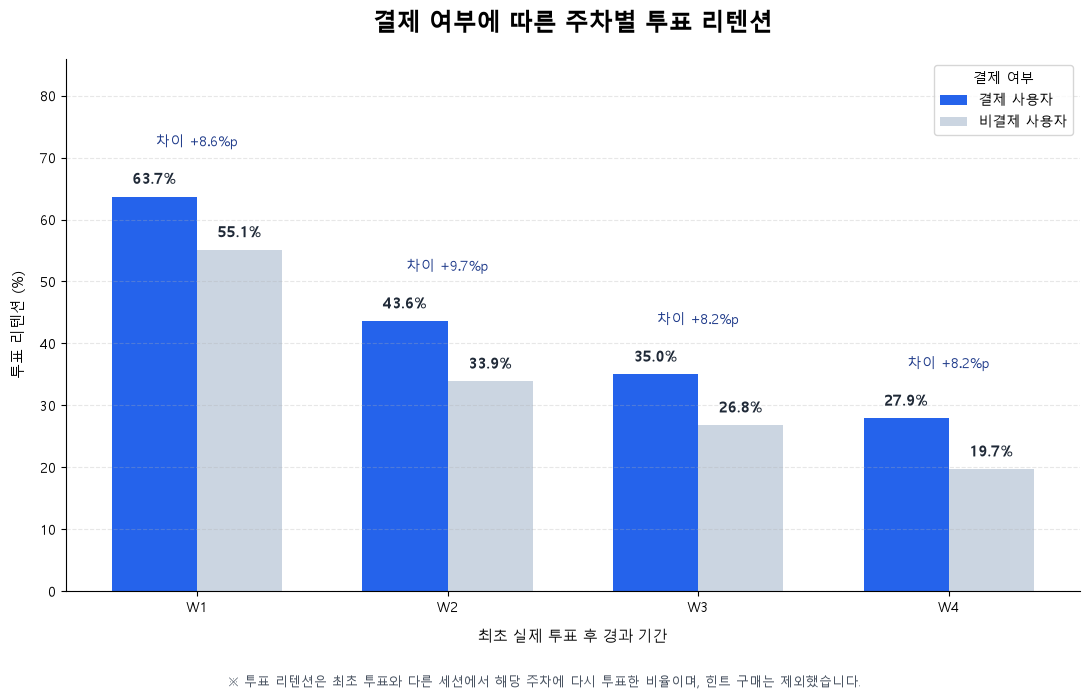

In [30]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 시각화용 데이터
# =========================================================

period_order = [
    "W1",
    "W2",
    "W3",
    "W4"
]

plot_df = (
    payer_retention_df
    .pivot_table(
        index="retention_period",
        columns="payer_status",
        values="retention_rate_percent",
        aggfunc="first"
    )
    .reindex(period_order)
)

payer_values = (
    plot_df["결제 사용자"]
    .astype(float)
    .to_numpy()
)

non_payer_values = (
    plot_df["비결제 사용자"]
    .astype(float)
    .to_numpy()
)


# =========================================================
# 3. 그룹 막대그래프
# =========================================================

x = np.arange(
    len(period_order)
)

bar_width = 0.34

fig, ax = plt.subplots(
    figsize=(11, 7)
)

payer_bars = ax.bar(
    x - bar_width / 2,
    payer_values,
    bar_width,
    label="결제 사용자",
    color="#2563EB"
)

non_payer_bars = ax.bar(
    x + bar_width / 2,
    non_payer_values,
    bar_width,
    label="비결제 사용자",
    color="#CBD5E1"
)


# =========================================================
# 4. 데이터 라벨
# =========================================================

maximum_rate = max(
    payer_values.max(),
    non_payer_values.max(),
    1
)

for bars, values in [
    (payer_bars, payer_values),
    (non_payer_bars, non_payer_values)
]:
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
            + maximum_rate * 0.025,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10.5,
            fontweight="bold",
            color="#1F2937"
        )


# 결제자와 비결제자 차이 표시
for index, period in enumerate(period_order):

    difference = (
        payer_values[index]
        - non_payer_values[index]
    )

    label_height = (
        max(
            payer_values[index],
            non_payer_values[index]
        )
        + maximum_rate * 0.12
    )

    ax.text(
        x[index],
        label_height,
        f"차이 {difference:+.1f}%p",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#1E3A8A"
    )


# =========================================================
# 5. 그래프 설정
# =========================================================

ax.set_title(
    "결제 여부에 따른 주차별 투표 리텐션",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "최초 실제 투표 후 경과 기간",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "투표 리텐션 (%)",
    fontsize=11,
    labelpad=10
)

ax.set_xticks(x)
ax.set_xticklabels(period_order)

ax.set_ylim(
    0,
    maximum_rate * 1.35
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="결제 여부",
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.012,
    "※ 투표 리텐션은 최초 투표와 다른 세션에서 해당 주차에 다시 투표한 비율이며, 힌트 구매는 제외했습니다.",
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

## 전체 결제자 3,246명 유지하면서 31~60, 61~90, 91일 이상

앞의 첫 결제까지 걸린 시간 분석을 24시간 이내부터 91일 이상까지 8개 구간으로 세분화한다. 

가입 이후 완료된 결제만 인정하고 표본을 줄이지 않고, 전체 결제자를 그대로 유지한 채 구간별 분포를 본다.

In [38]:
# 전체 결제자 3,246명 유지하면서 31~60, 61~90, 91일 이상
first_purchase_all_payers_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date
),

-- 탈퇴하지 않은 유효 가입자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.created_at AS signup_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 성공 결제
successful_payments AS (
  SELECT
    hp.user_id,
    hp.completed_at

  FROM `ping-v2-503916.raw.heart_purchase` AS hp

  INNER JOIN valid_users AS vu
    ON hp.user_id = vu.user_id

  CROSS JOIN params AS p

  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL

    -- 가입 이후 결제만 인정
    AND hp.completed_at >= vu.signup_at

    -- 실제 결제번호가 있는 기록
    AND hp.store_transaction_id IS NOT NULL

    -- 테스트·스텁 결제 제외
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )

    AND hp.price_krw > 0
    AND hp.heart_amount > 0

    AND DATE(
      hp.completed_at,
      'Asia/Seoul'
    ) BETWEEN p.analysis_start_date
          AND p.data_end_date
),

-- 사용자별 최초 실제 성공 결제
first_purchase AS (
  SELECT
    user_id,
    MIN(completed_at) AS first_purchase_at

  FROM successful_payments

  GROUP BY user_id
),

-- 가입 후 첫 결제까지 걸린 시간
purchase_delay AS (
  SELECT
    vu.user_id,
    vu.signup_at,
    fp.first_purchase_at,

    TIMESTAMP_DIFF(
      fp.first_purchase_at,
      vu.signup_at,
      HOUR
    ) AS hours_to_first_purchase,

    ROUND(
      TIMESTAMP_DIFF(
        fp.first_purchase_at,
        vu.signup_at,
        MINUTE
      ) / 1440.0,
      2
    ) AS days_to_first_purchase

  FROM valid_users AS vu

  INNER JOIN first_purchase AS fp
    ON vu.user_id = fp.user_id

  WHERE fp.first_purchase_at >= vu.signup_at
),

-- 첫 결제 소요 기간 구간화
bucketed AS (
  SELECT
    *,

    CASE
      WHEN hours_to_first_purchase <= 24
        THEN '24시간 이내'

      WHEN hours_to_first_purchase <= 72
        THEN '1~3일'

      WHEN hours_to_first_purchase <= 168
        THEN '4~7일'

      WHEN hours_to_first_purchase <= 336
        THEN '8~14일'

      WHEN hours_to_first_purchase <= 720
        THEN '15~30일'

      WHEN hours_to_first_purchase <= 1440
        THEN '31~60일'

      WHEN hours_to_first_purchase <= 2160
        THEN '61~90일'

      ELSE '91일 이상'
    END AS purchase_delay_group,

    CASE
      WHEN hours_to_first_purchase <= 24 THEN 1
      WHEN hours_to_first_purchase <= 72 THEN 2
      WHEN hours_to_first_purchase <= 168 THEN 3
      WHEN hours_to_first_purchase <= 336 THEN 4
      WHEN hours_to_first_purchase <= 720 THEN 5
      WHEN hours_to_first_purchase <= 1440 THEN 6
      WHEN hours_to_first_purchase <= 2160 THEN 7
      ELSE 8
    END AS group_order

  FROM purchase_delay
)

SELECT
  user_id,

  DATETIME(
    signup_at,
    'Asia/Seoul'
  ) AS signup_datetime_kst,

  DATETIME(
    first_purchase_at,
    'Asia/Seoul'
  ) AS first_purchase_datetime_kst,

  hours_to_first_purchase,
  days_to_first_purchase,
  purchase_delay_group,
  group_order,

  COUNT(*) OVER () AS total_payer_count

FROM bucketed

ORDER BY
  group_order,
  hours_to_first_purchase,
  user_id
"""

In [39]:
cost(first_purchase_all_payers_sql)

예상 스캔량: 1.268 MiB
예상 스캔량: 0.001238 GiB
월 1 TiB 무료 용량의 약 0.00012090%


0.0012380601838231087

In [40]:
first_purchase_all_df = (
    bq.query(first_purchase_all_payers_sql)
      .result()
      .to_dataframe()
)

first_purchase_all_df.head()

,user_id,signup_datetime_kst,first_purchase_datetime_kst,hours_to_first_purchase,days_to_first_purchase,purchase_delay_group,group_order,total_payer_count
0,2538,2025-09-12 02:57:03,2025-09-12 03:25:17,0,0.02,24시간 이내,1,3246
1,17183,2026-05-17 03:33:49,2026-05-17 03:36:11,0,0.00,24시간 이내,1,3246
2,18577,2026-06-17 01:15:53,2026-06-17 02:13:06,0,0.04,24시간 이내,1,3246
3,18889,2026-06-25 00:02:14,2026-06-25 00:46:42,0,0.03,24시간 이내,1,3246
4,19228,2026-07-03 21:05:33,2026-07-03 21:38:07,0,0.02,24시간 이내,1,3246


In [41]:
delay_order = [
    "24시간 이내",
    "1~3일",
    "4~7일",
    "8~14일",
    "15~30일",
    "31~60일",
    "61~90일",
    "91일 이상"
]

delay_summary_all = (
    first_purchase_all_df[
        "purchase_delay_group"
    ]
    .value_counts()
    .reindex(
        delay_order,
        fill_value=0
    )
    .rename_axis(
        "purchase_delay_group"
    )
    .reset_index(
        name="payer_count"
    )
)

total_payer_count = int(
    delay_summary_all["payer_count"].sum()
)

delay_summary_all["payer_share_percent"] = (
    delay_summary_all["payer_count"]
    / total_payer_count
    * 100
)

delay_summary_all


,purchase_delay_group,payer_count,payer_share_percent
0,24시간 이내,134,4.128158
1,1~3일,179,5.514479
2,4~7일,250,7.701787
3,8~14일,343,10.566852
4,15~30일,557,17.159581
5,31~60일,629,19.377696
6,61~90일,376,11.583487
7,91일 이상,778,23.967961


In [42]:
delay_days = first_purchase_all_df[
    "days_to_first_purchase"
].dropna()

average_days = delay_days.mean()
median_days = delay_days.median()

p25_days = delay_days.quantile(0.25)
p75_days = delay_days.quantile(0.75)
p90_days = delay_days.quantile(0.90)

print("[전체 결제자의 첫 결제 소요 기간]")
print(
    f"실제 결제 사용자: "
    f"{total_payer_count:,}명"
)
print(
    f"첫 결제까지 평균 소요 기간: "
    f"{average_days:.2f}일"
)
print(
    f"첫 결제까지 중앙 소요 기간: "
    f"{median_days:.2f}일"
)
print(
    f"25%는 {p25_days:.2f}일 이내, "
    f"75%는 {p75_days:.2f}일 이내, "
    f"90%는 {p90_days:.2f}일 이내에 "
    f"첫 결제를 완료했습니다."
)

print("\n[첫 결제 소요 기간별 사용자]")

for _, row in delay_summary_all.iterrows():
    print(
        f"{row['purchase_delay_group']}: "
        f"{int(row['payer_count']):,}명 "
        f"({row['payer_share_percent']:.2f}%)"
    )

[전체 결제자의 첫 결제 소요 기간]
실제 결제 사용자: 3,246명
첫 결제까지 평균 소요 기간: 60.58일
첫 결제까지 중앙 소요 기간: 36.79일
25%는 11.89일 이내, 75%는 86.82일 이내, 90%는 156.42일 이내에 첫 결제를 완료했습니다.

[첫 결제 소요 기간별 사용자]
24시간 이내: 134명 (4.13%)
1~3일: 179명 (5.51%)
4~7일: 250명 (7.70%)
8~14일: 343명 (10.57%)
15~30일: 557명 (17.16%)
31~60일: 629명 (19.38%)
61~90일: 376명 (11.58%)
91일 이상: 778명 (23.97%)


In [43]:
within_30_count = int(
    (
        first_purchase_all_df[
            "hours_to_first_purchase"
        ] <= 720
    ).sum()
)

within_60_count = int(
    (
        first_purchase_all_df[
            "hours_to_first_purchase"
        ] <= 1440
    ).sum()
)

within_90_count = int(
    (
        first_purchase_all_df[
            "hours_to_first_purchase"
        ] <= 2160
    ).sum()
)

over_90_count = (
    total_payer_count
    - within_90_count
)

print("\n[전체 결제자 기준 누적 첫 결제 비율]")

print(
    f"30일 이내: "
    f"{within_30_count:,}명 "
    f"({within_30_count / total_payer_count * 100:.2f}%)"
)

print(
    f"60일 이내: "
    f"{within_60_count:,}명 "
    f"({within_60_count / total_payer_count * 100:.2f}%)"
)

print(
    f"90일 이내: "
    f"{within_90_count:,}명 "
    f"({within_90_count / total_payer_count * 100:.2f}%)"
)

print(
    f"91일 이후: "
    f"{over_90_count:,}명 "
    f"({over_90_count / total_payer_count * 100:.2f}%)"
)


[전체 결제자 기준 누적 첫 결제 비율]
30일 이내: 1,463명 (45.07%)
60일 이내: 2,092명 (64.45%)
90일 이내: 2,468명 (76.03%)
91일 이후: 778명 (23.97%)


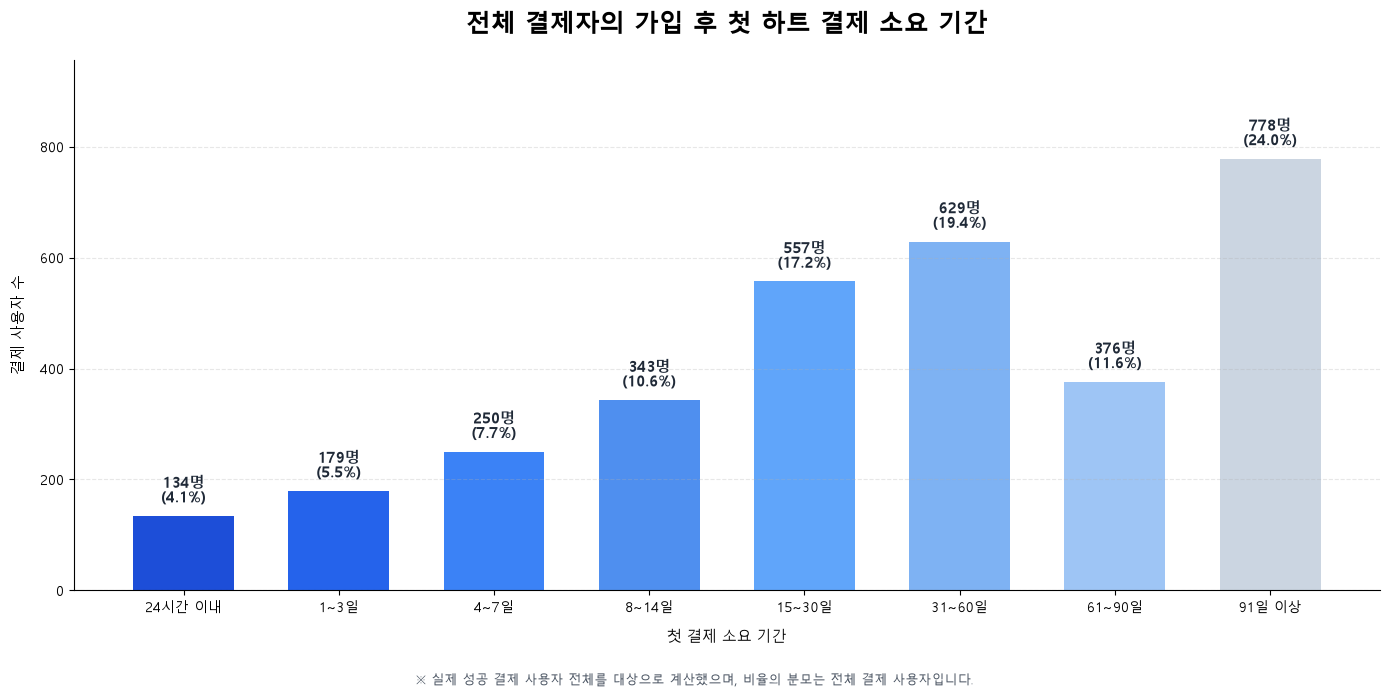

In [44]:
import platform
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 시각화 데이터
# =========================================================

plot_df = delay_summary_all.copy()

colors = [
    "#1D4ED8",
    "#2563EB",
    "#3B82F6",
    "#4F8FEF",
    "#60A5FA",
    "#7EB2F3",
    "#9EC5F5",
    "#CBD5E1"
]


# =========================================================
# 3. 막대그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)

bars = ax.bar(
    plot_df["purchase_delay_group"],
    plot_df["payer_count"],
    color=colors,
    width=0.65
)

maximum_count = max(
    int(plot_df["payer_count"].max()),
    1
)


# =========================================================
# 4. 데이터 라벨
# =========================================================

for bar, count, rate in zip(
    bars,
    plot_df["payer_count"],
    plot_df["payer_share_percent"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height()
        + maximum_count * 0.025,
        (
            f"{int(count):,}명\n"
            f"({rate:.1f}%)"
        ),
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color="#1F2937"
    )


# =========================================================
# 5. 그래프 설정
# =========================================================

ax.set_title(
    "전체 결제자의 가입 후 첫 하트 결제 소요 기간",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "첫 결제 소요 기간",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "결제 사용자 수",
    fontsize=11,
    labelpad=10
)

ax.set_ylim(
    0,
    maximum_count * 1.23
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.015,
    (
        "※ 실제 성공 결제 사용자 전체를 대상으로 계산했으며, "
        "비율의 분모는 전체 결제 사용자입니다."
    ),
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()